In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


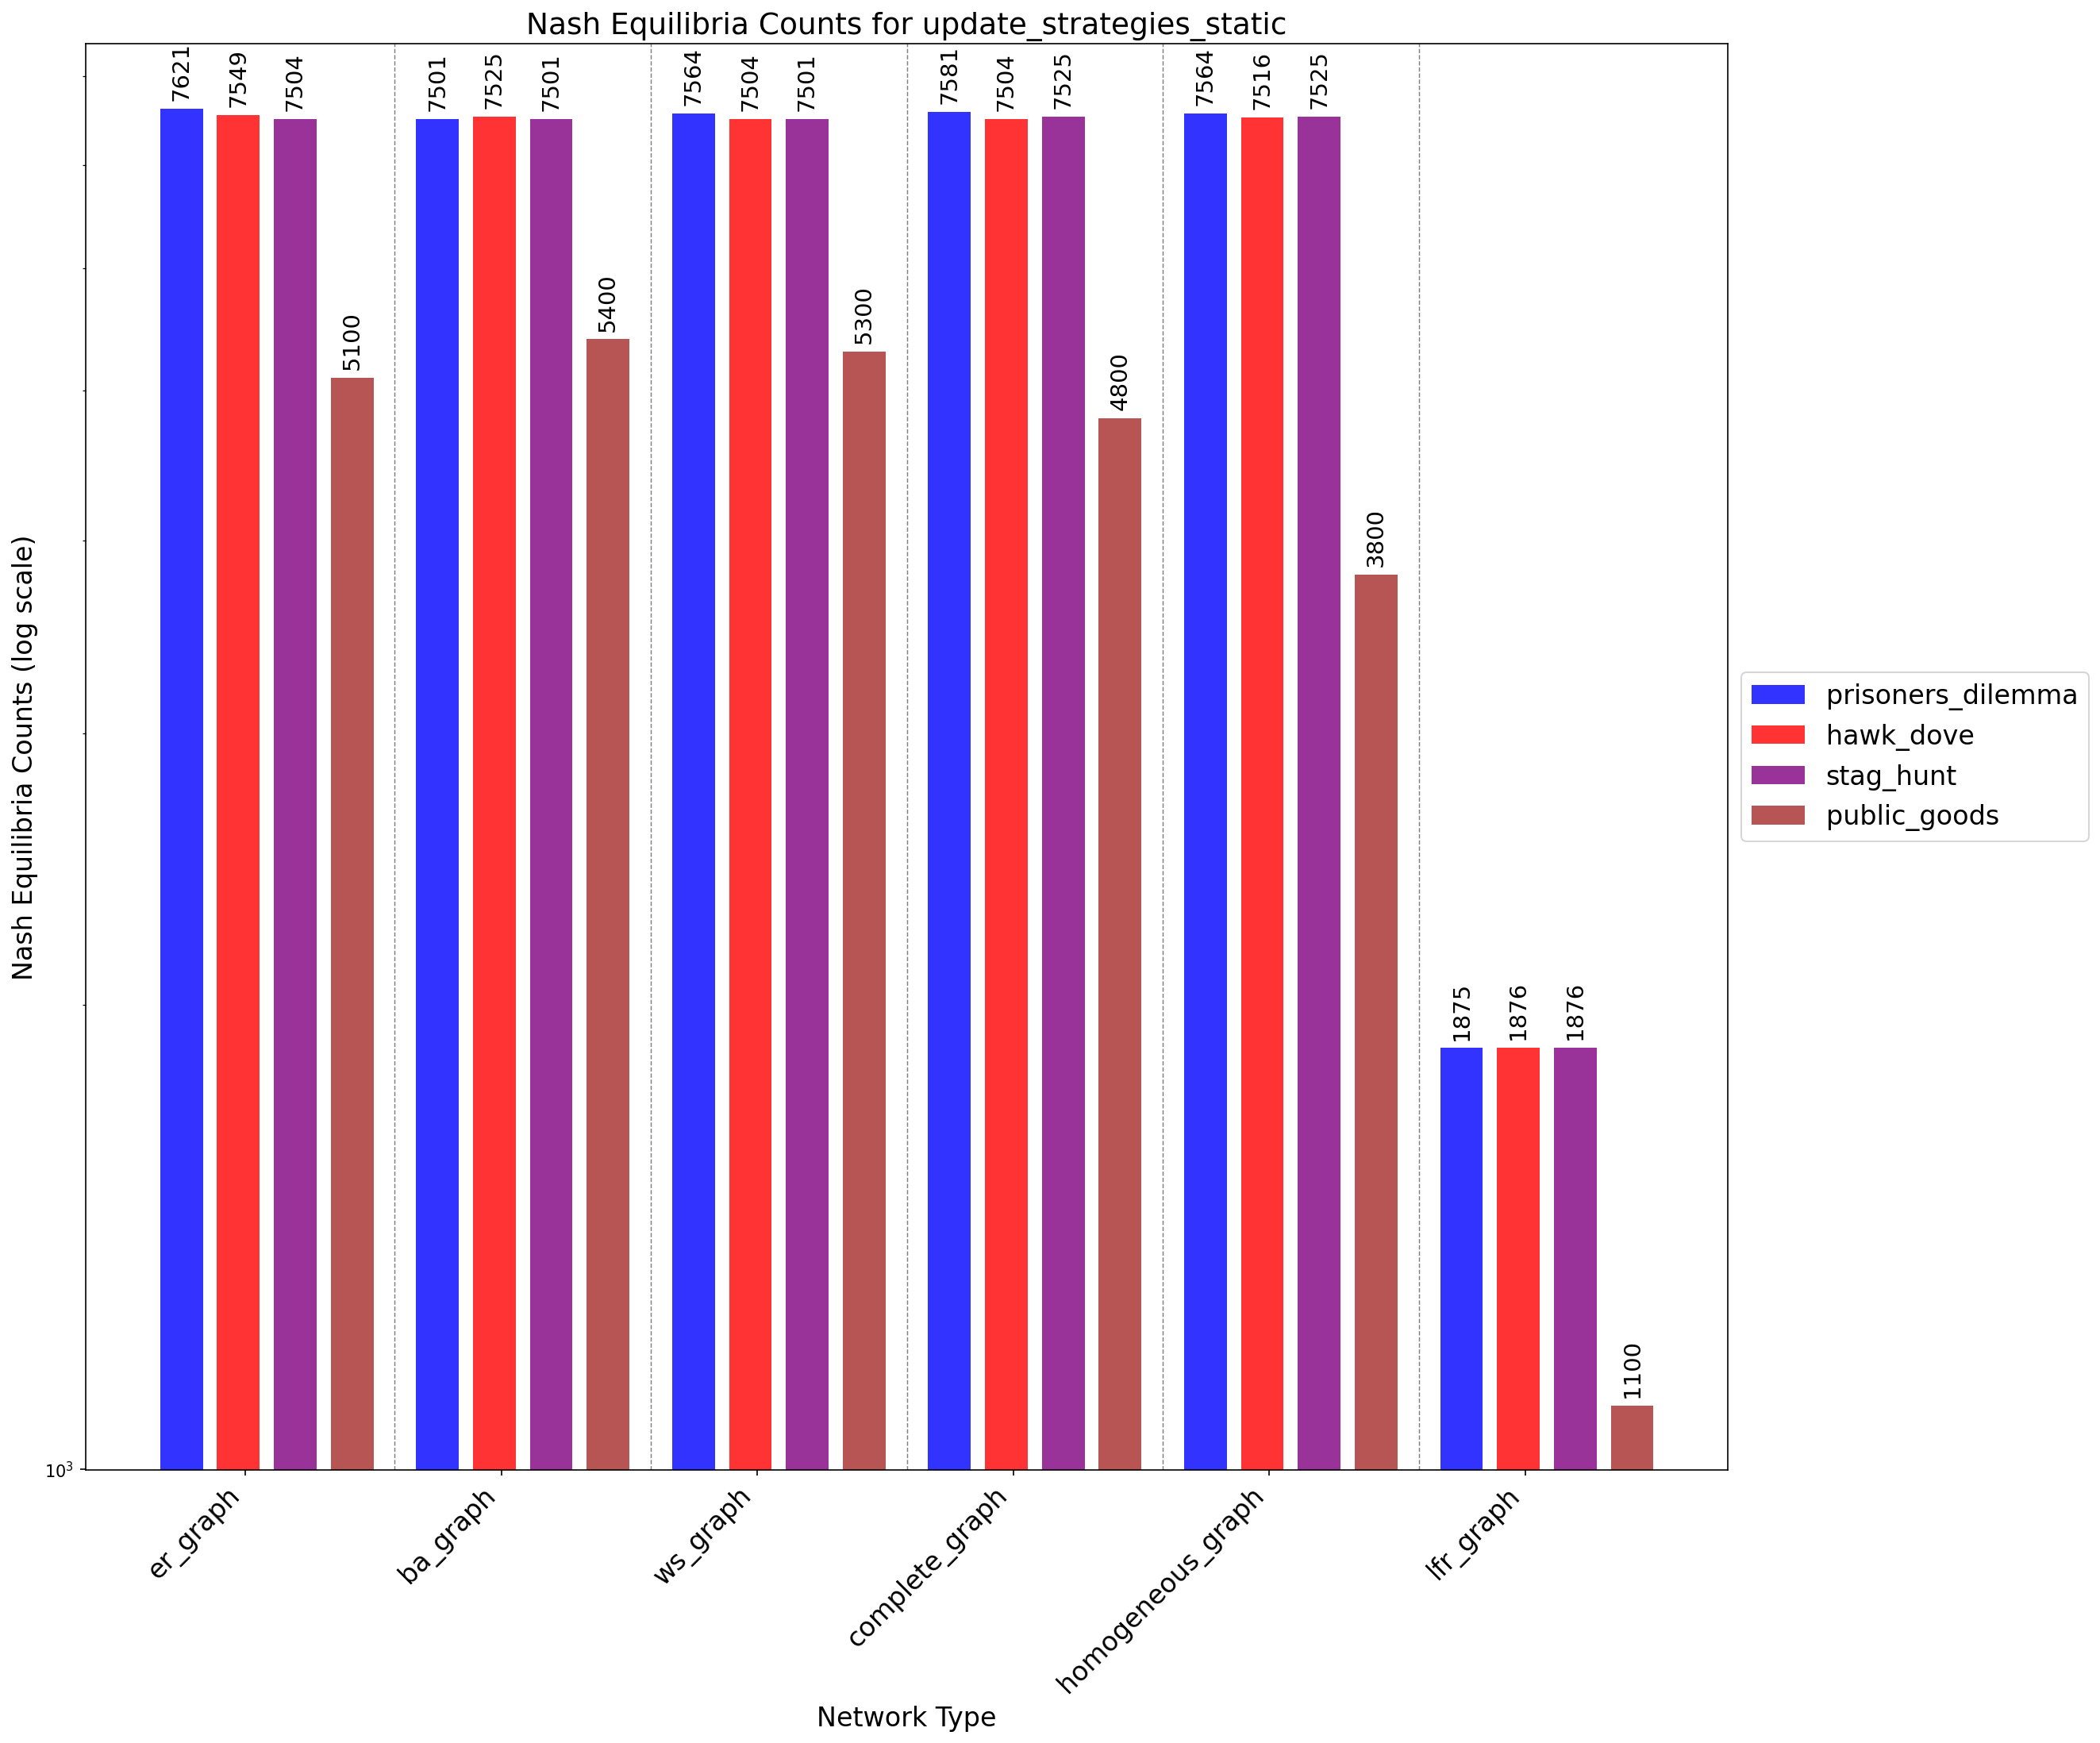

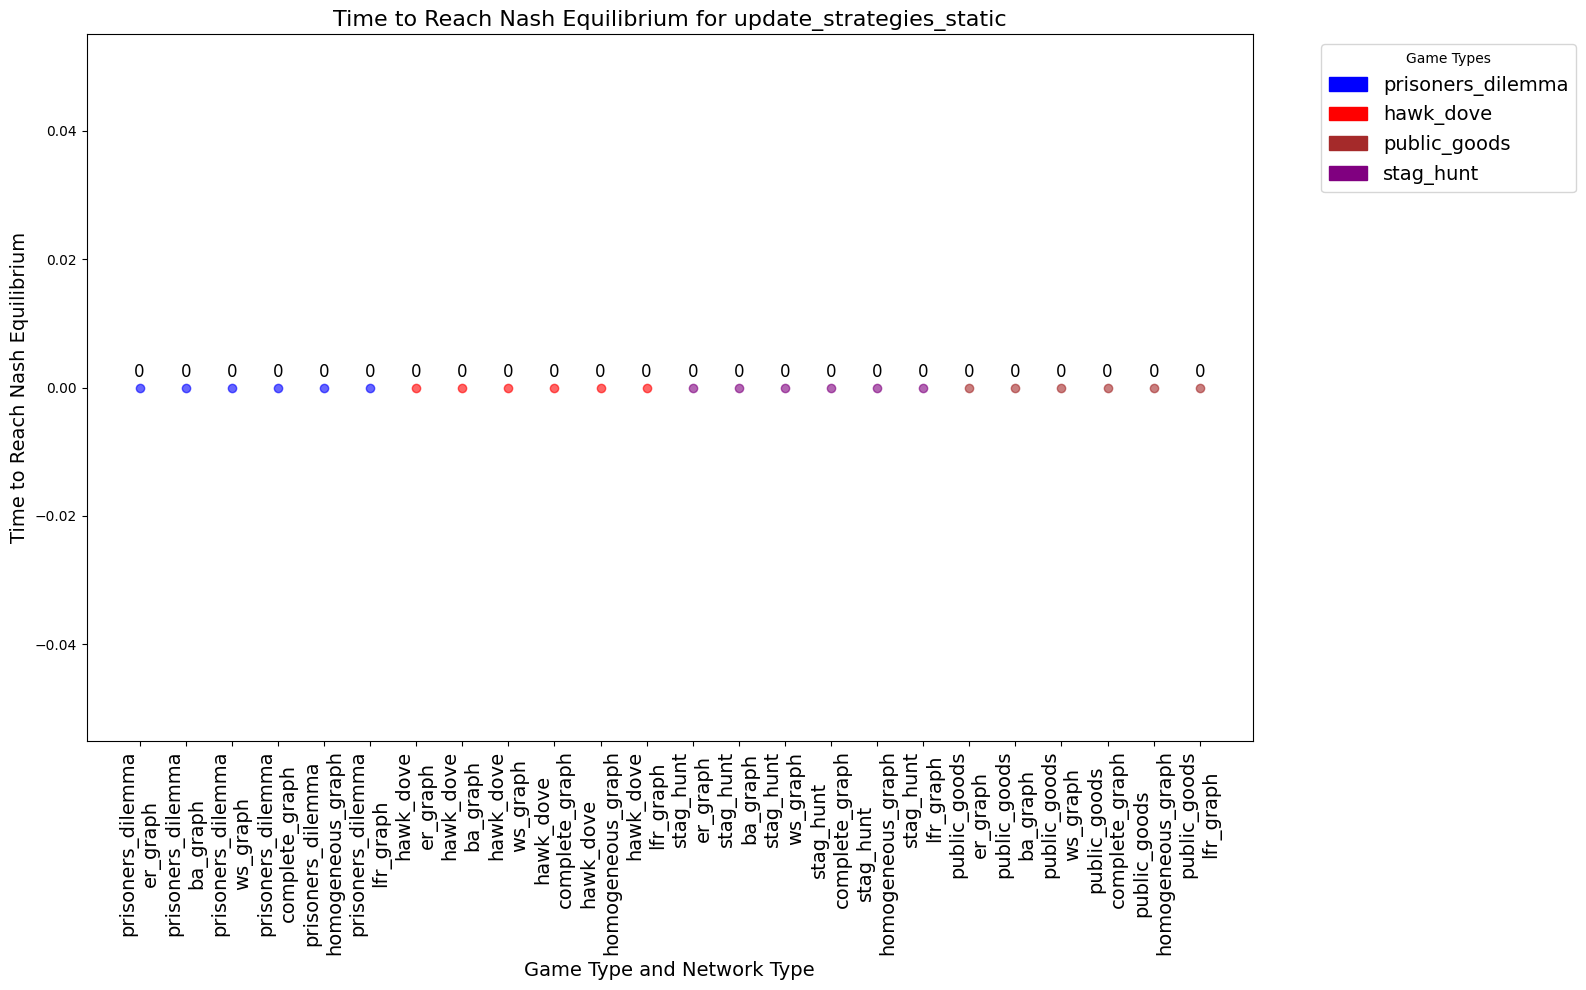

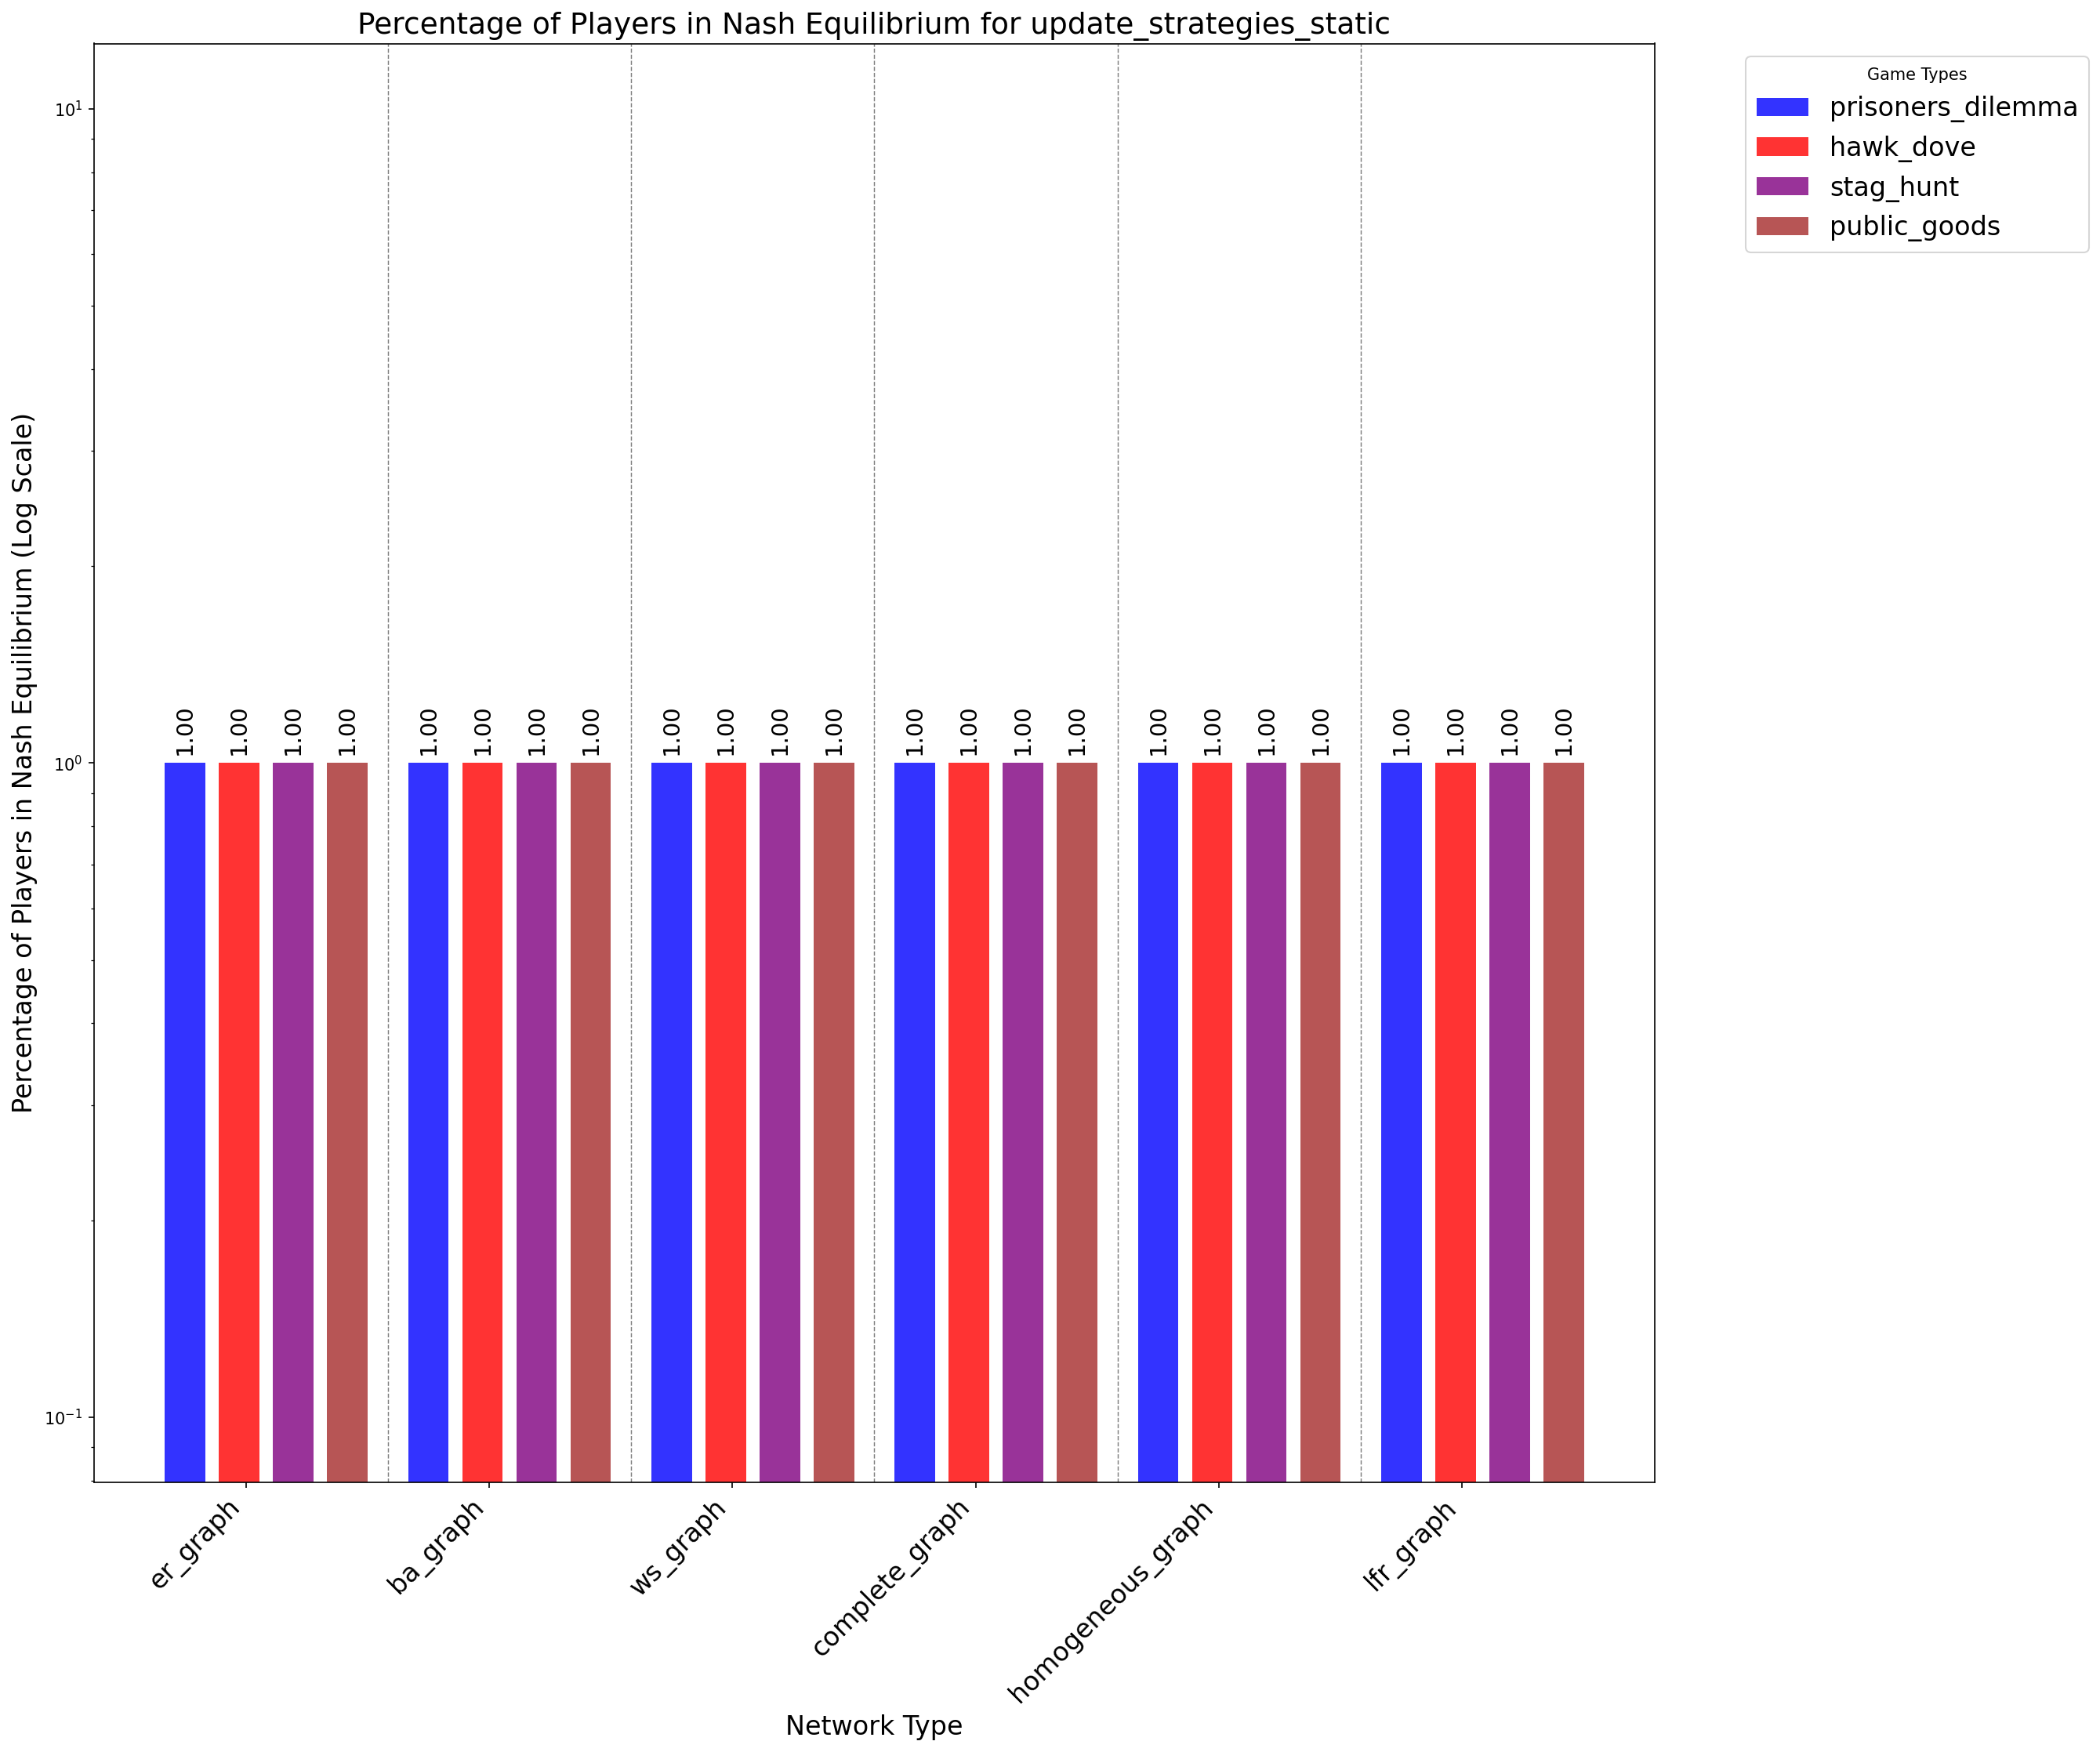

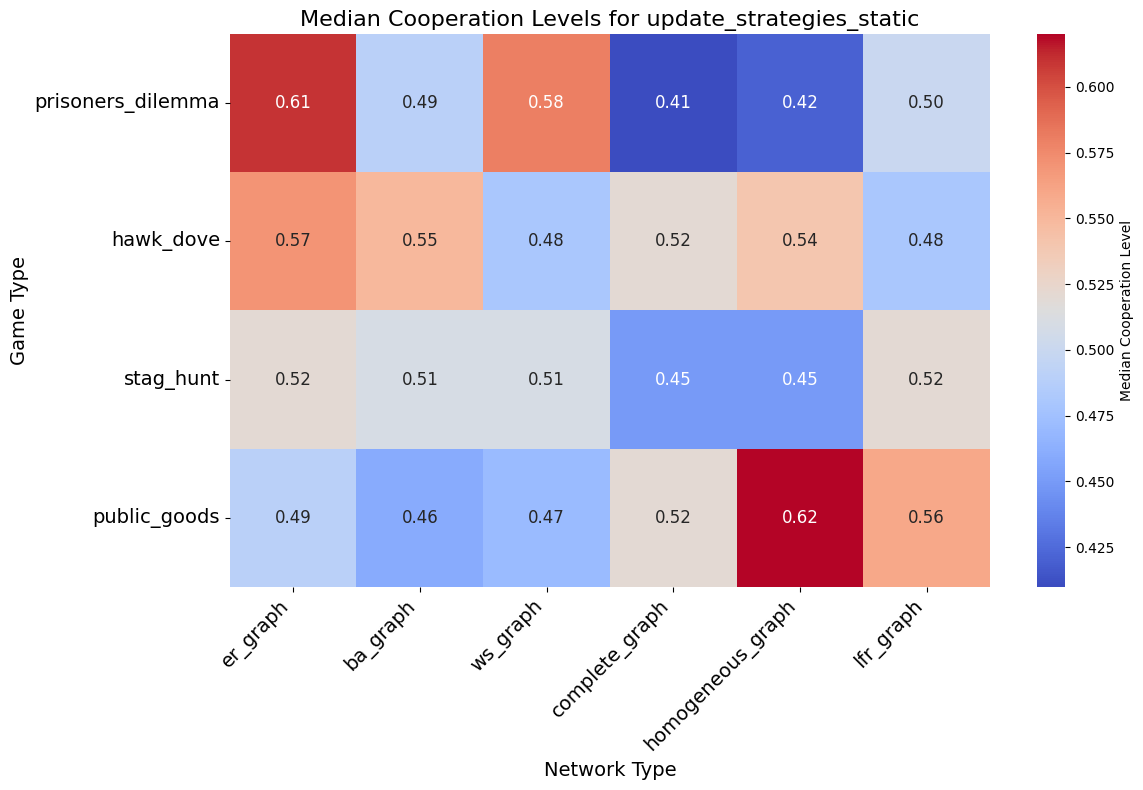

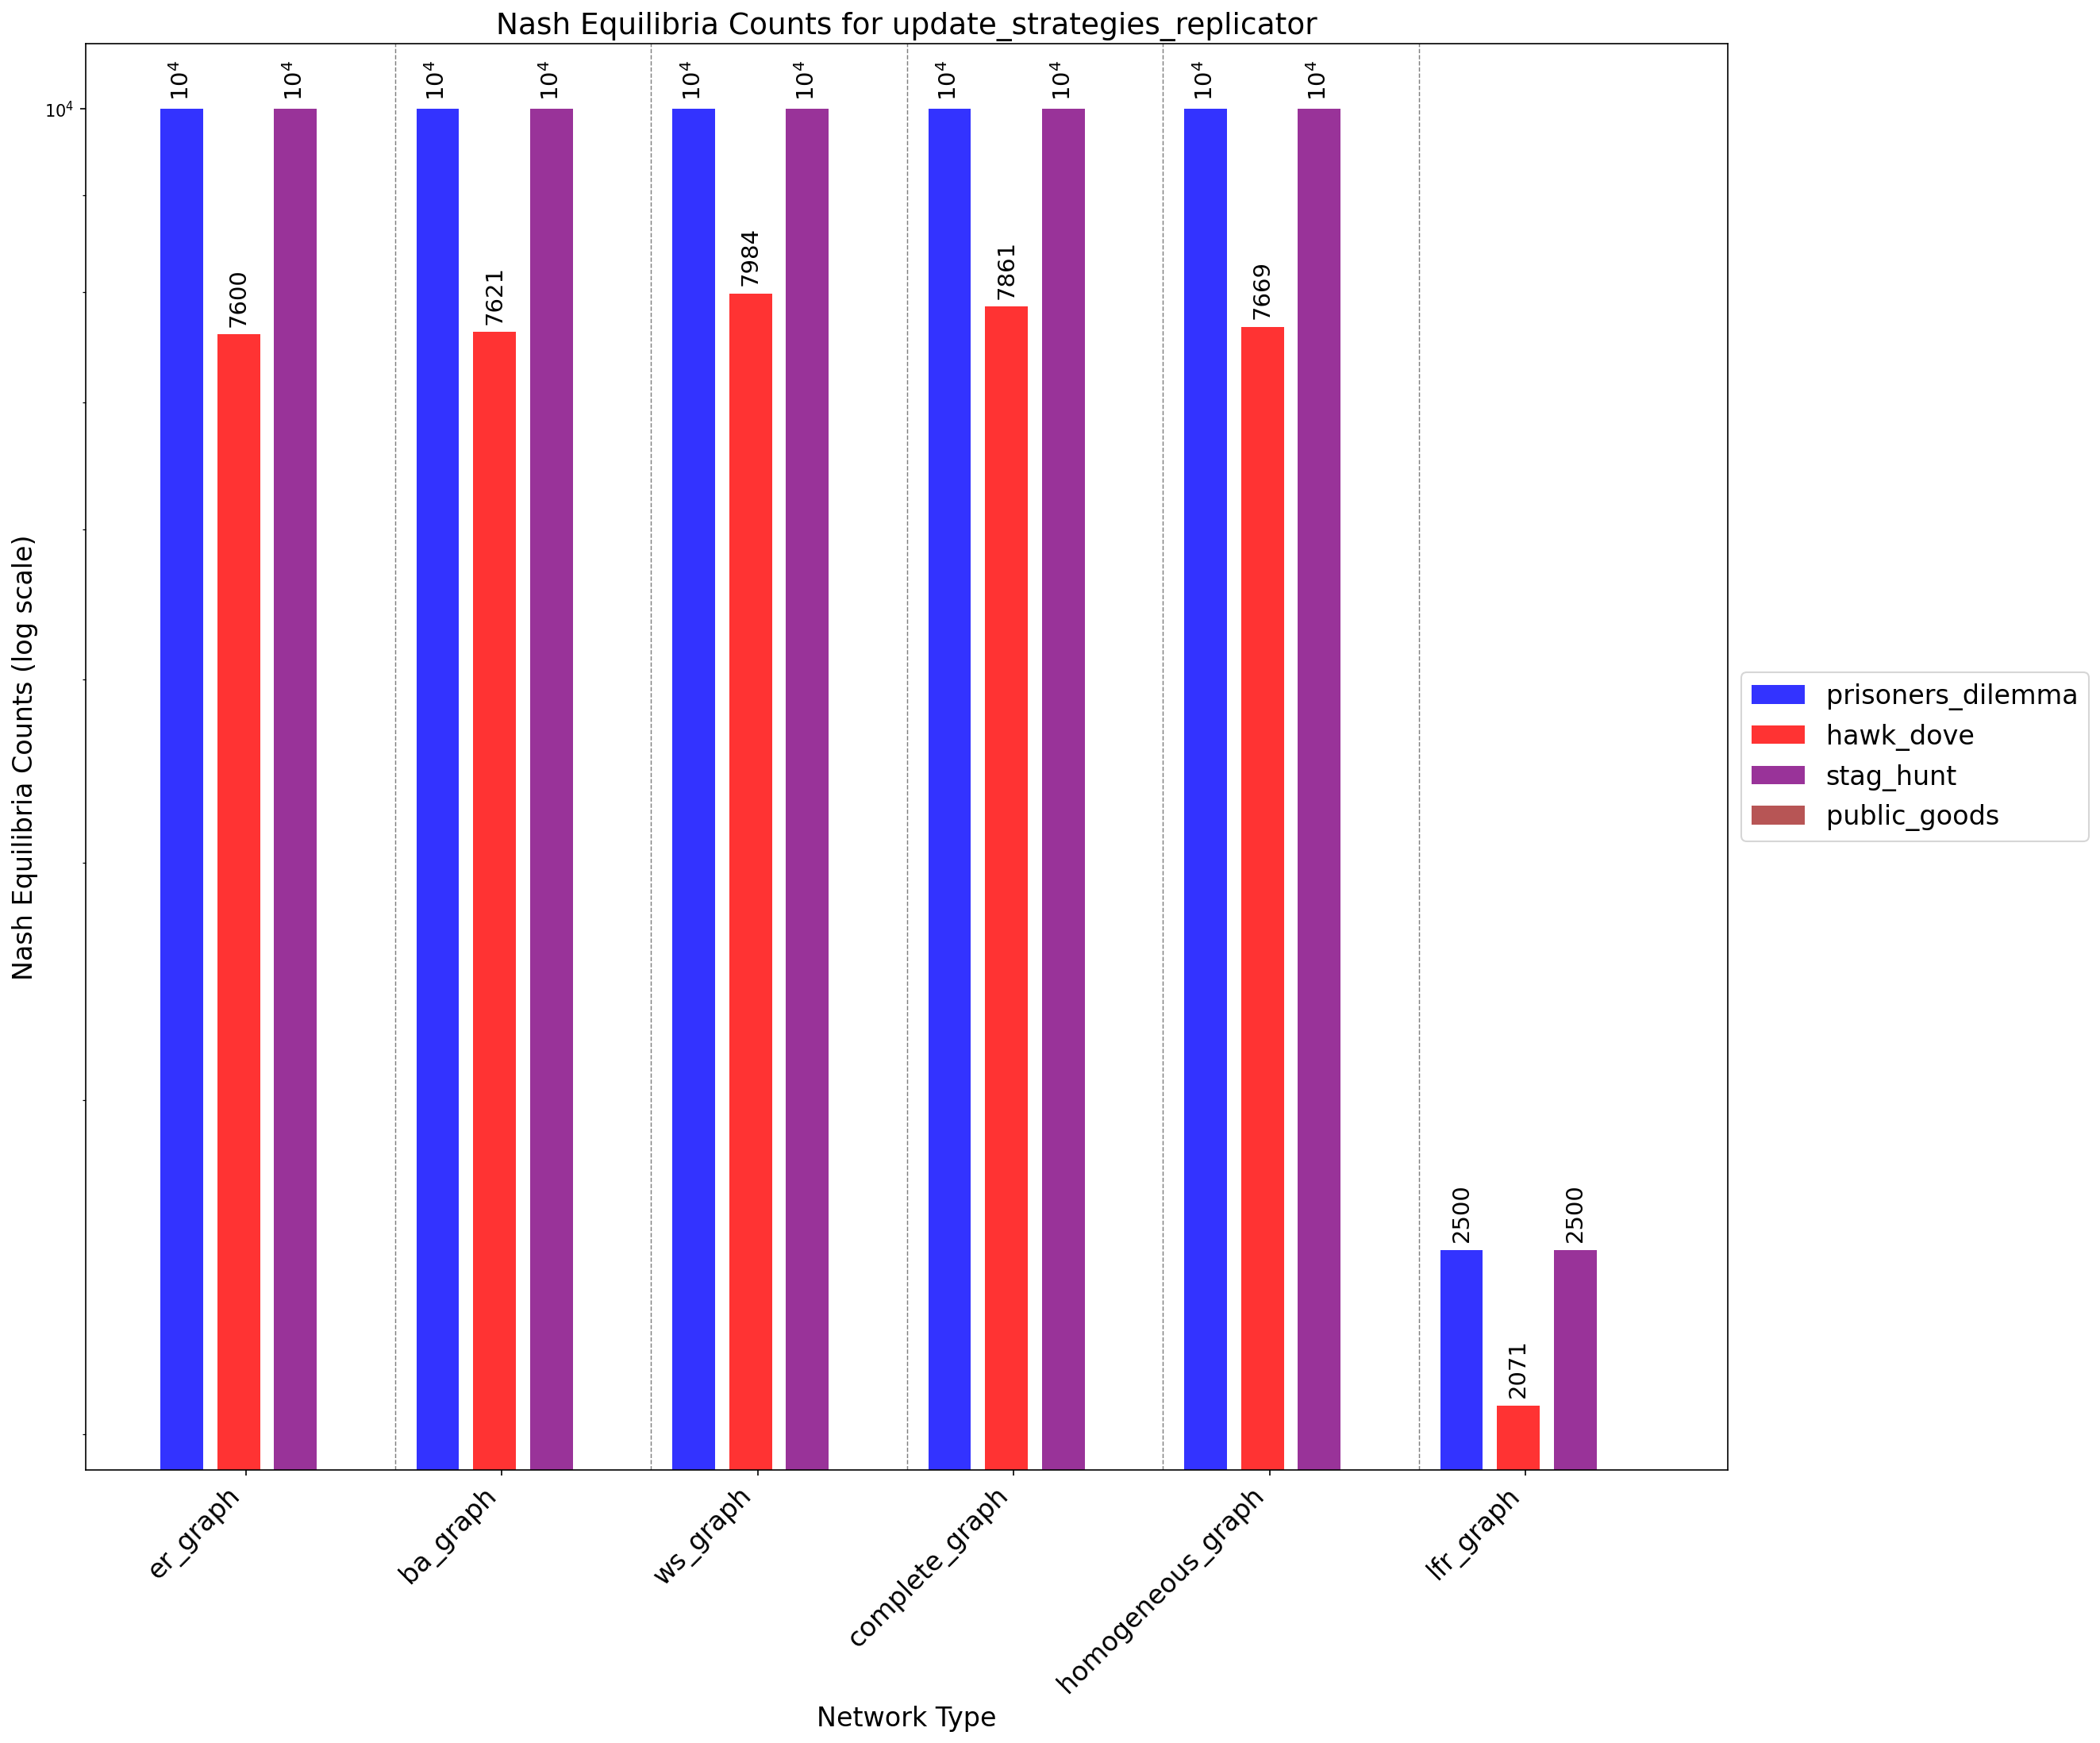

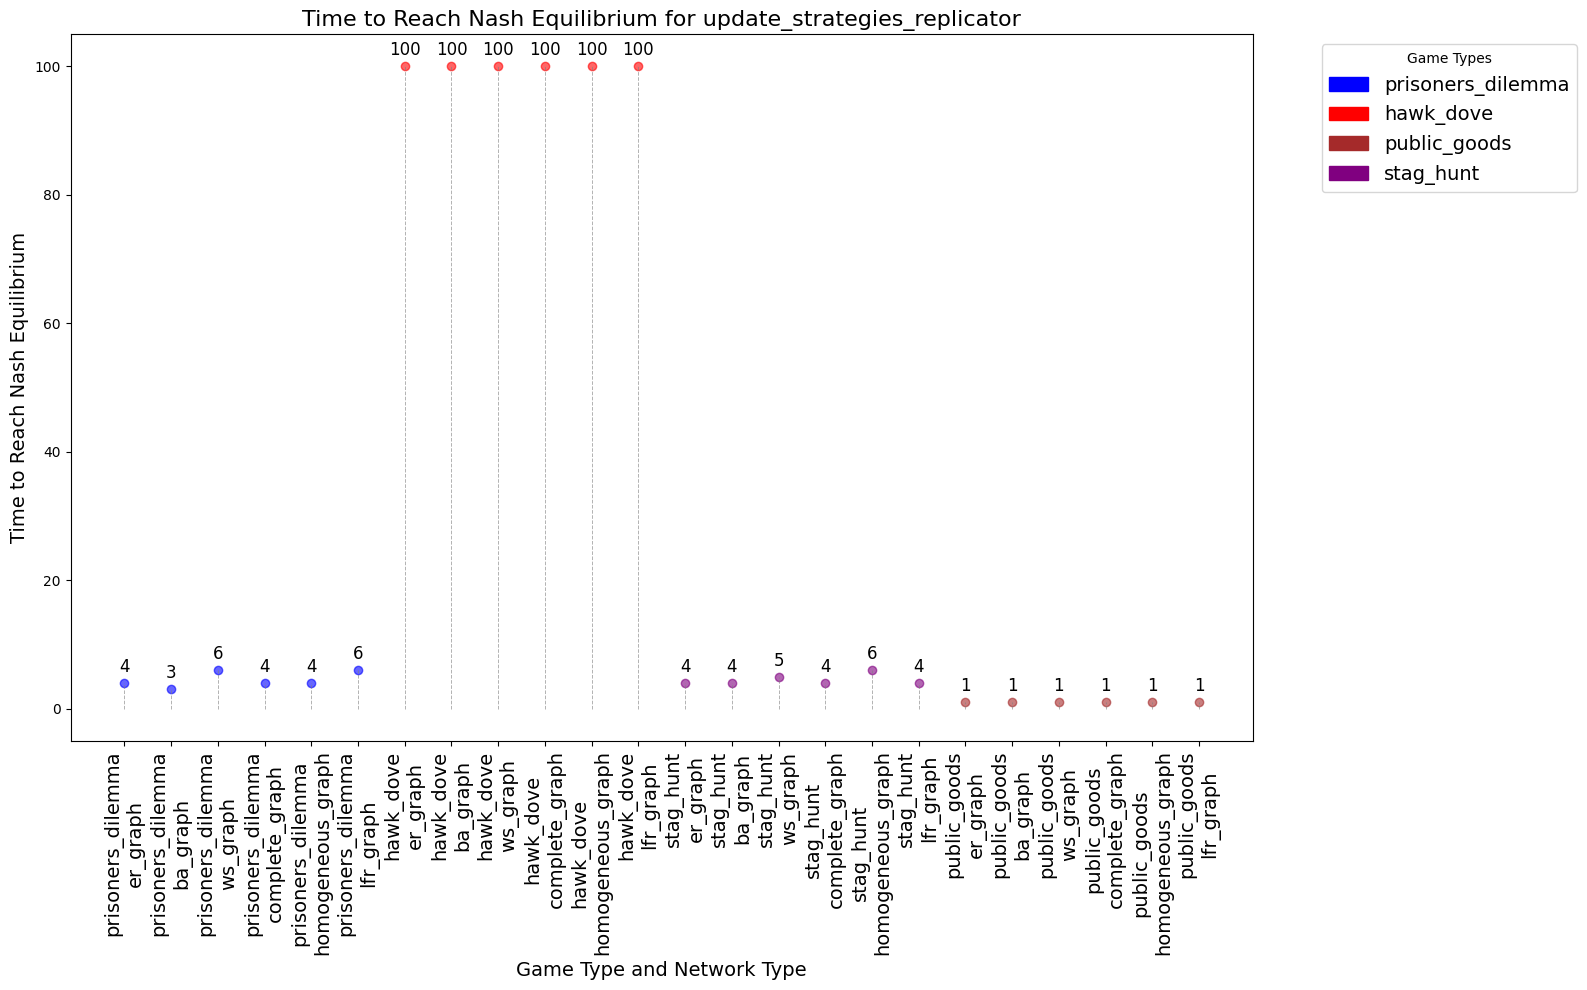

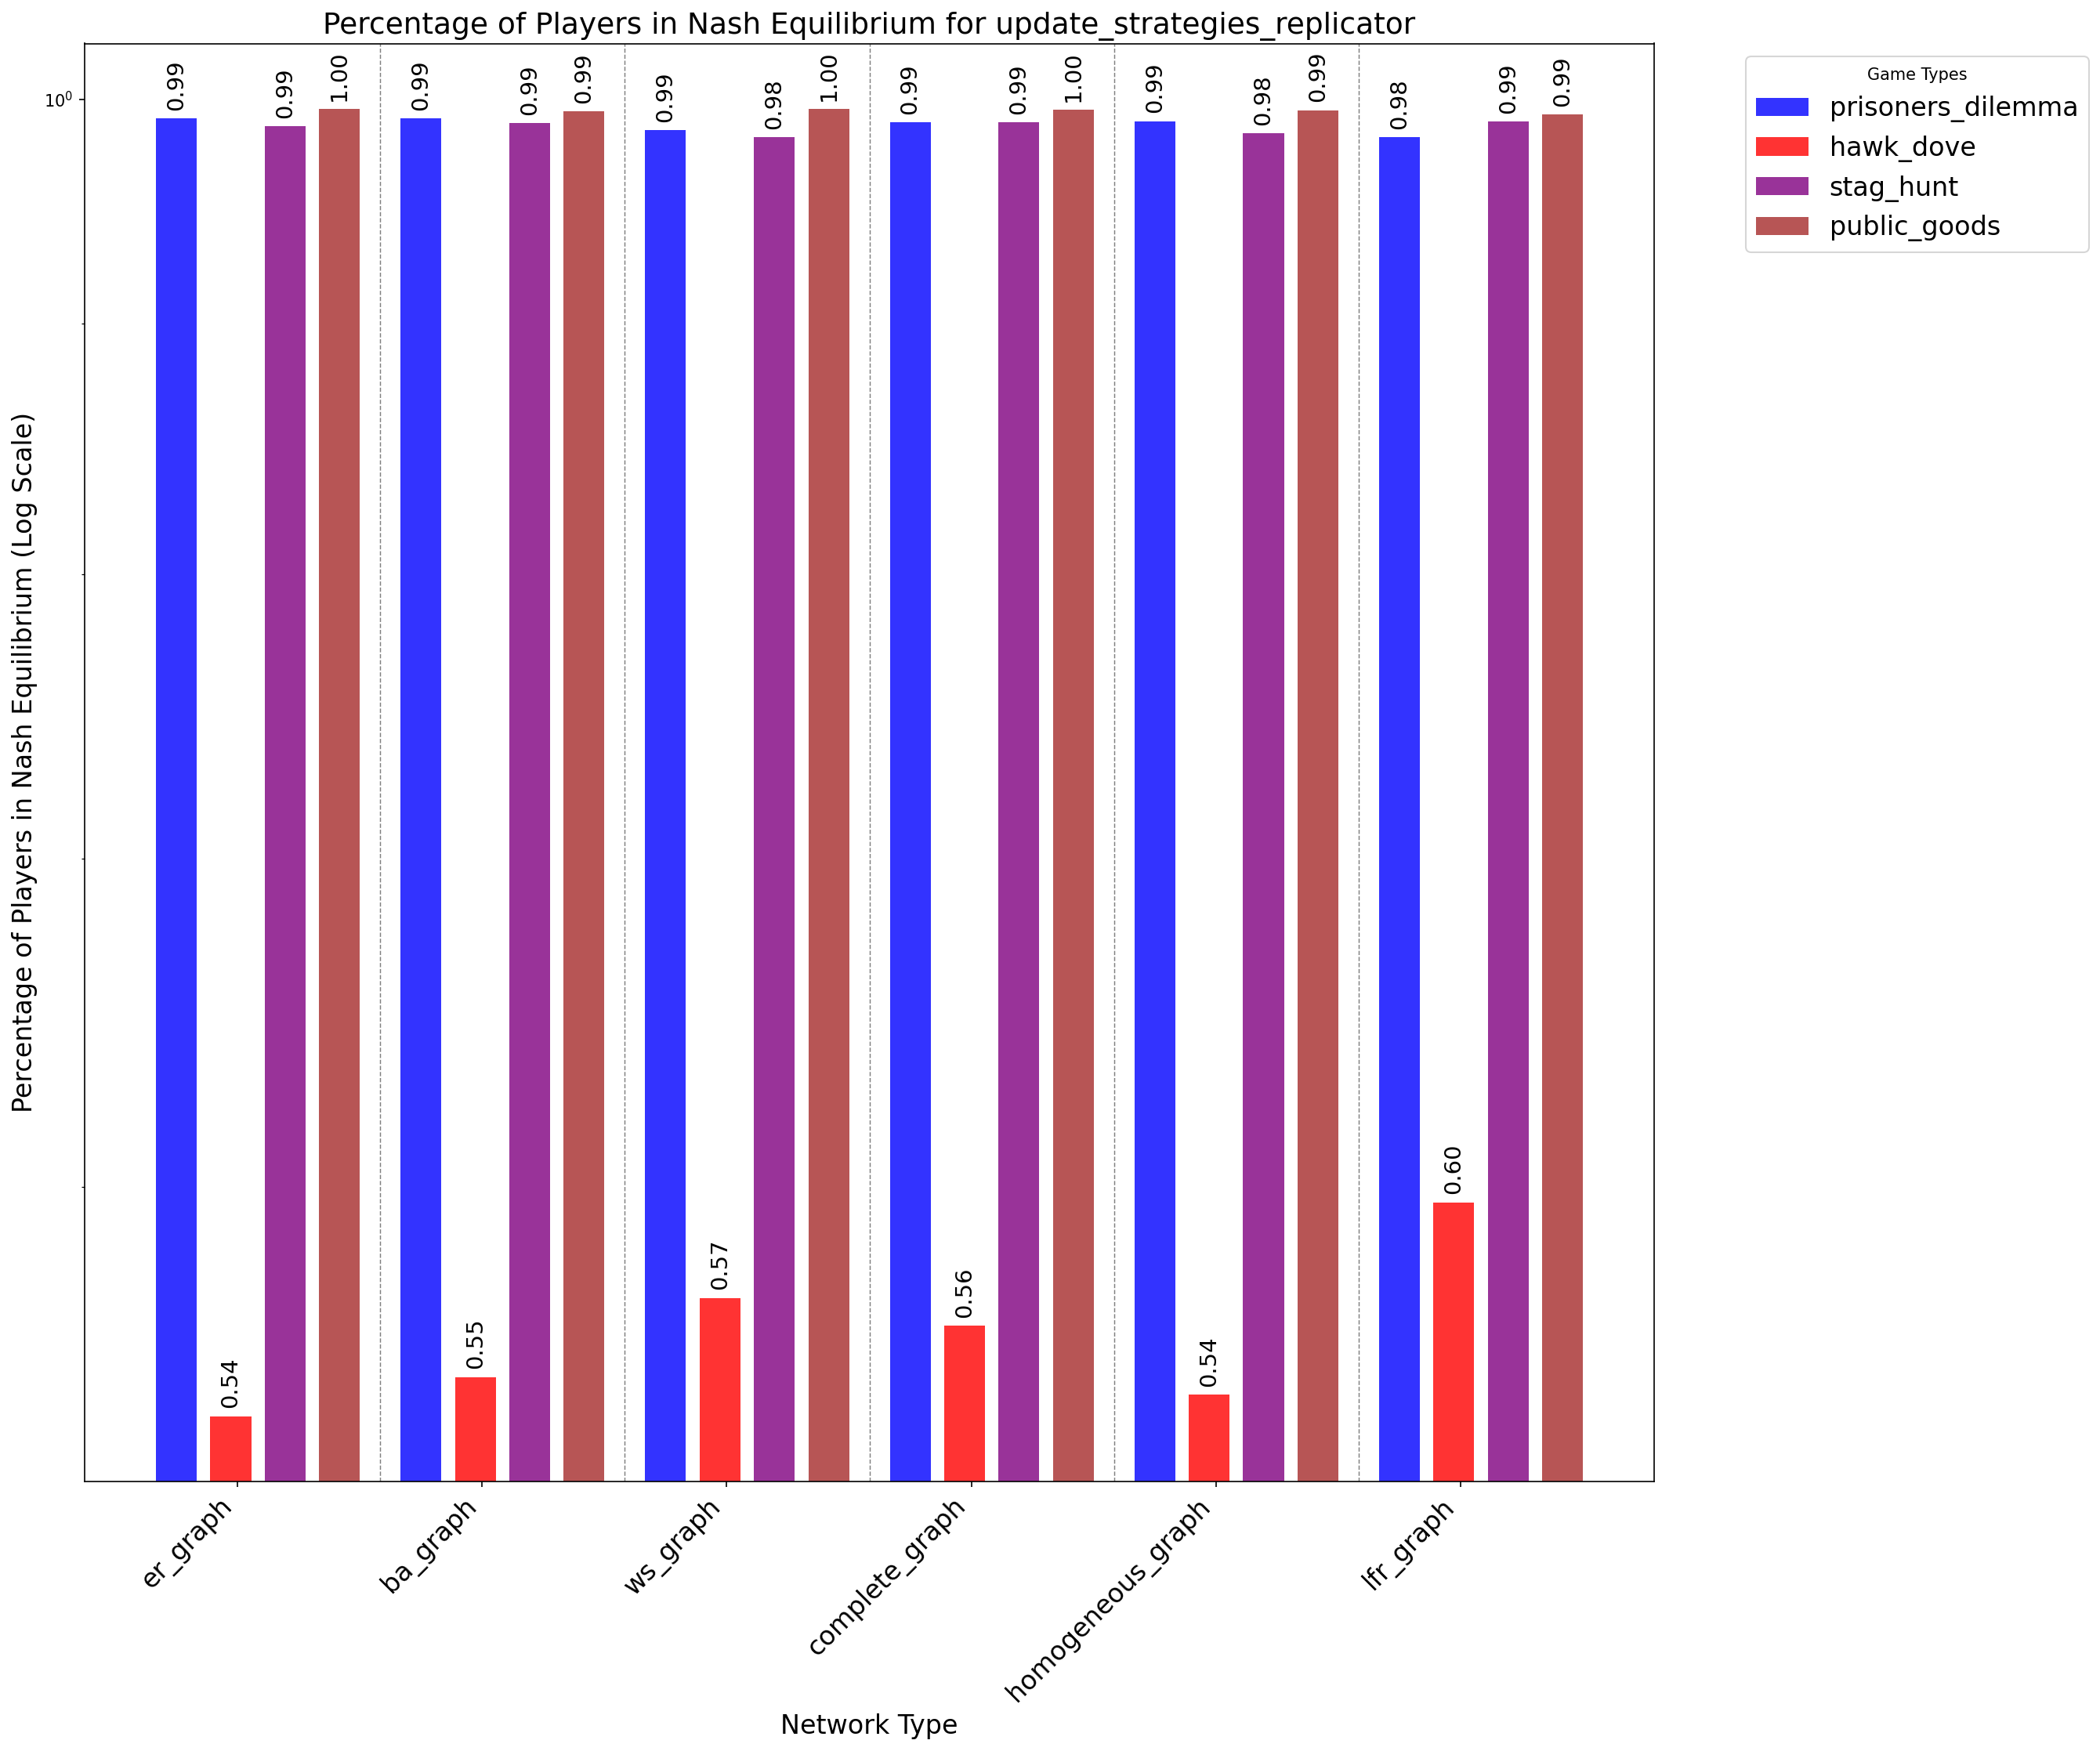

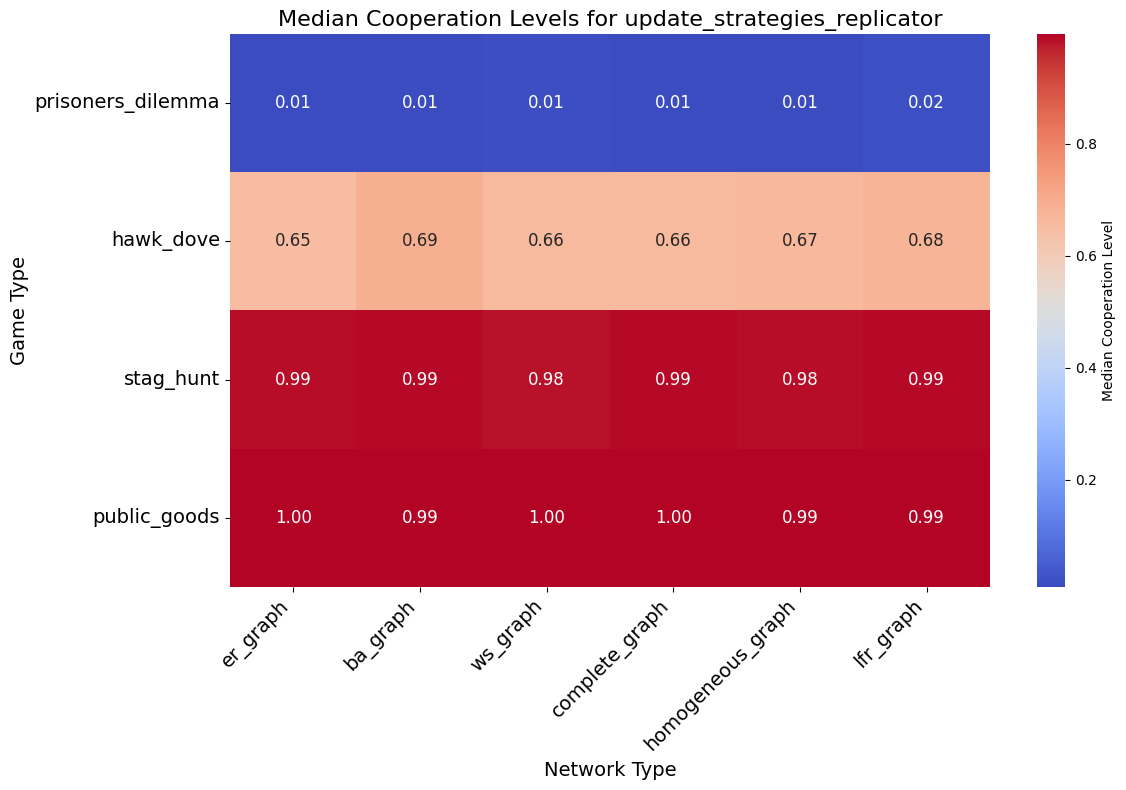

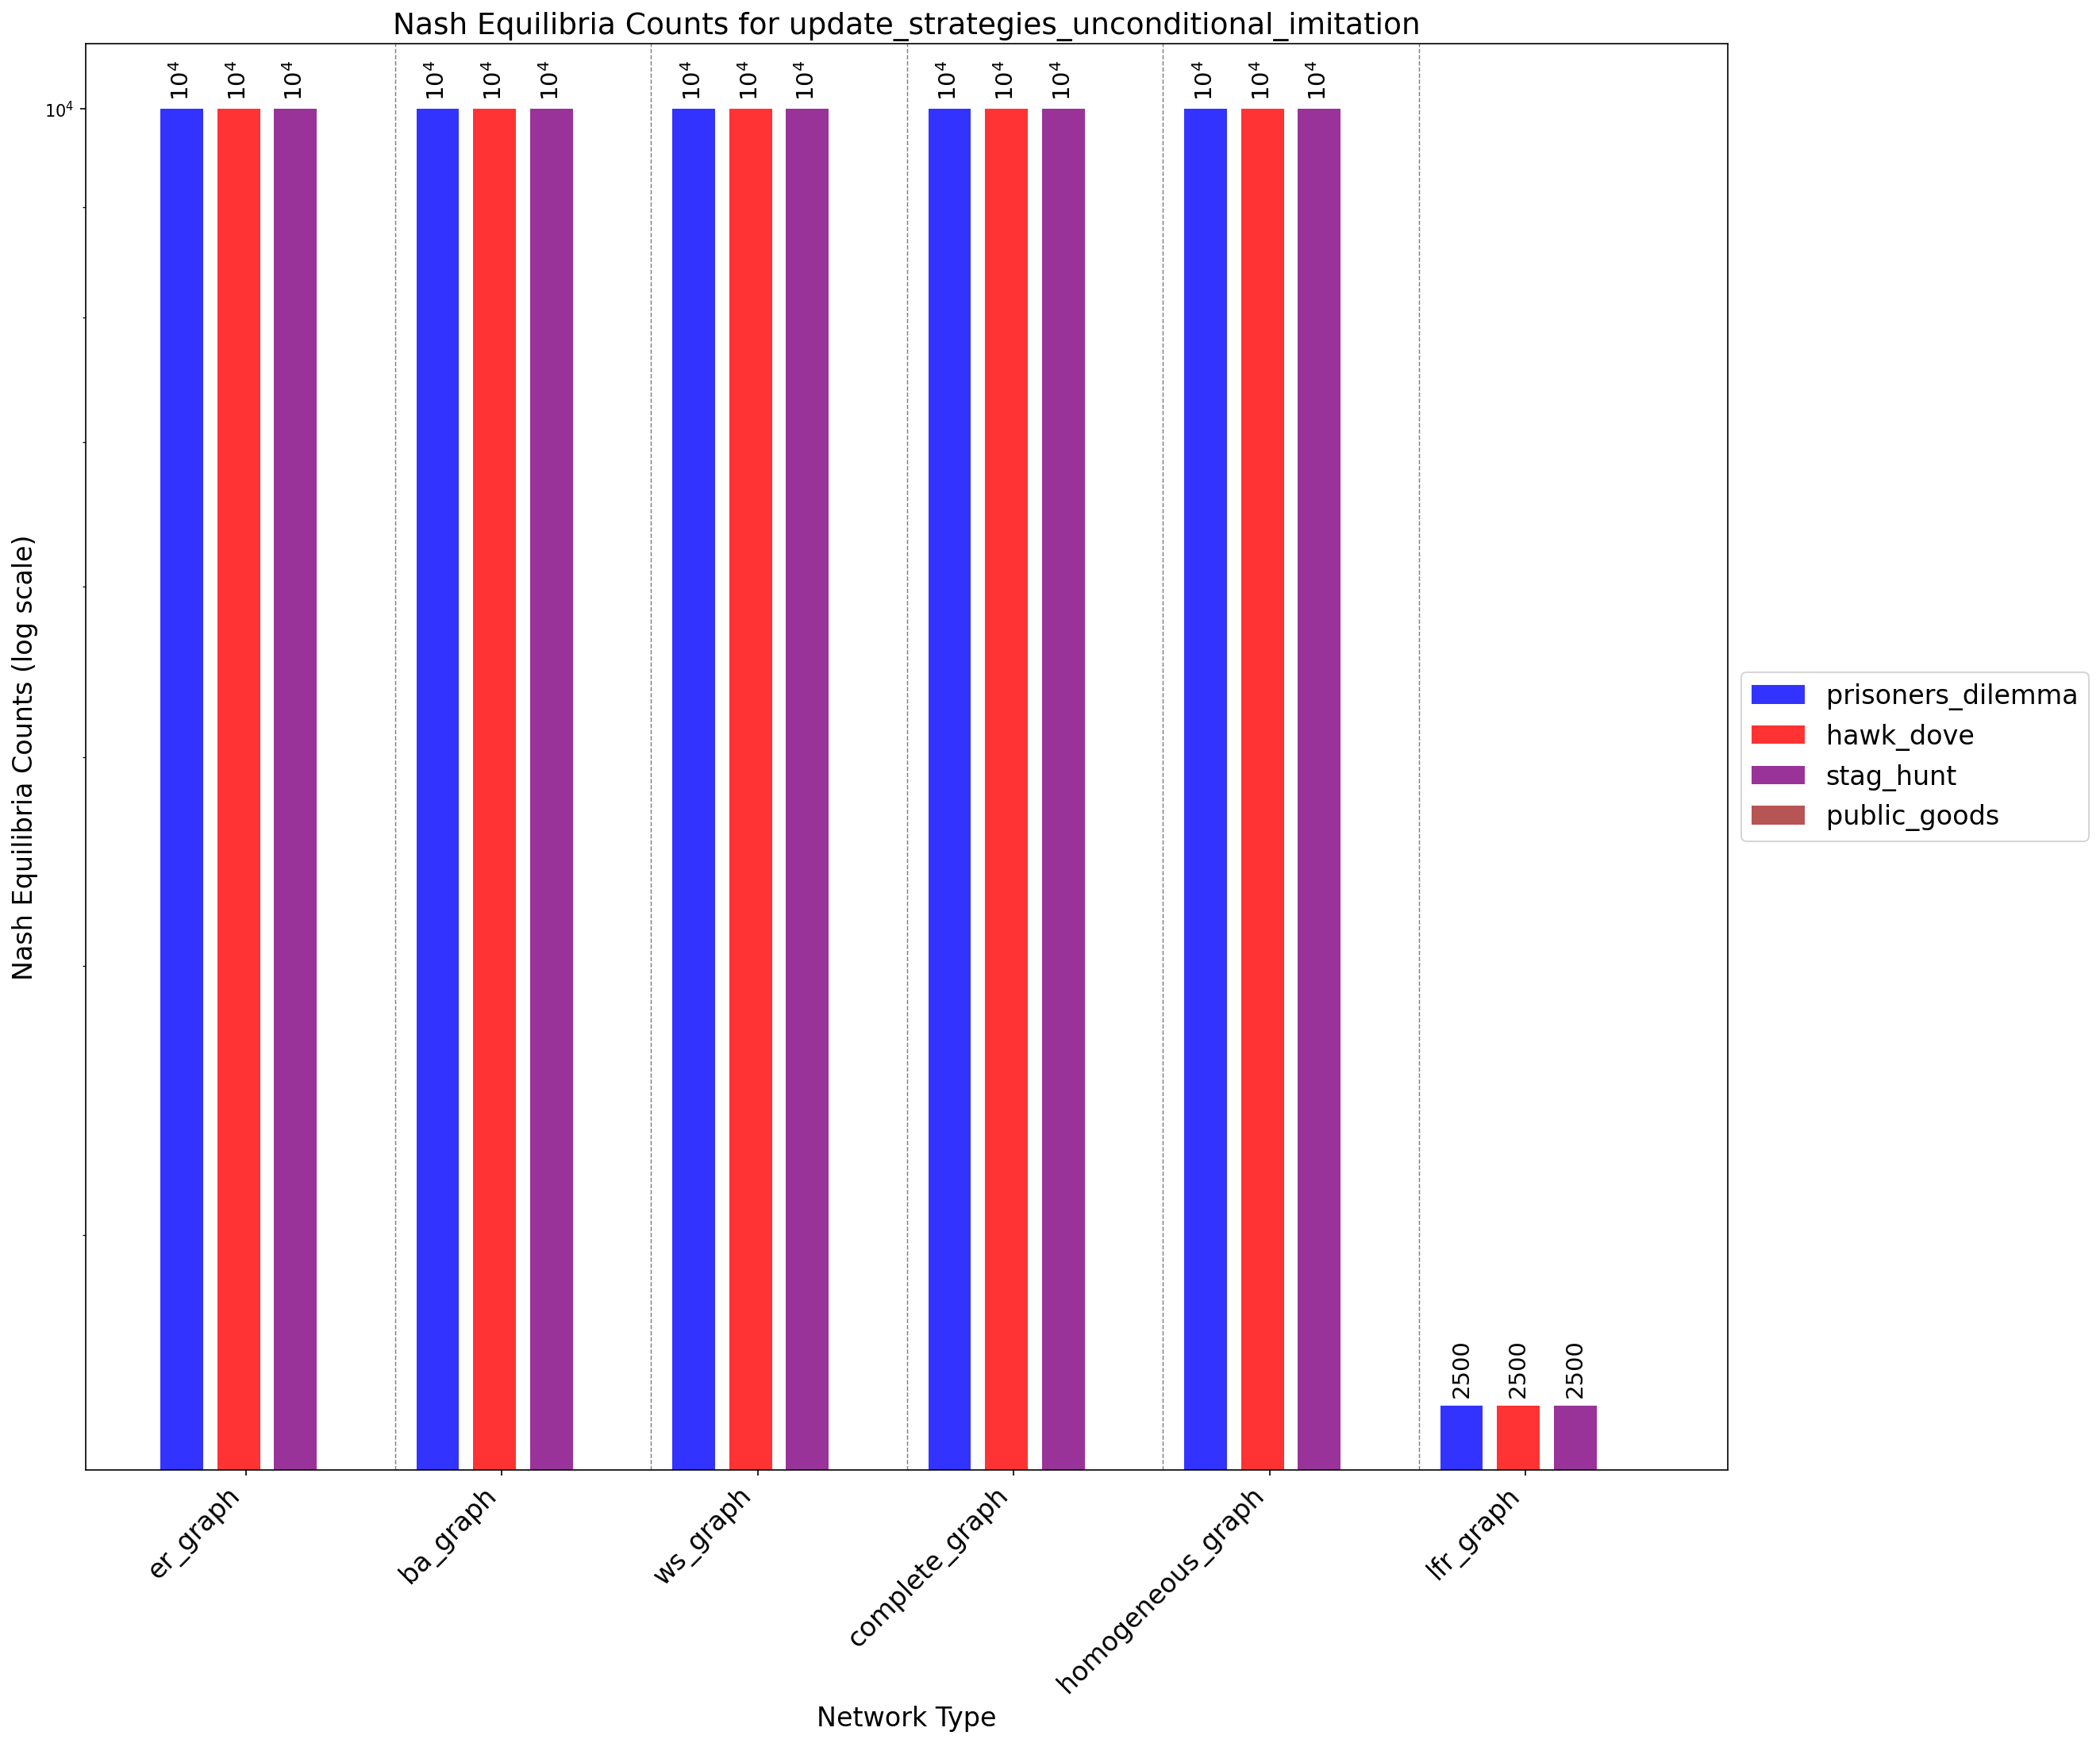

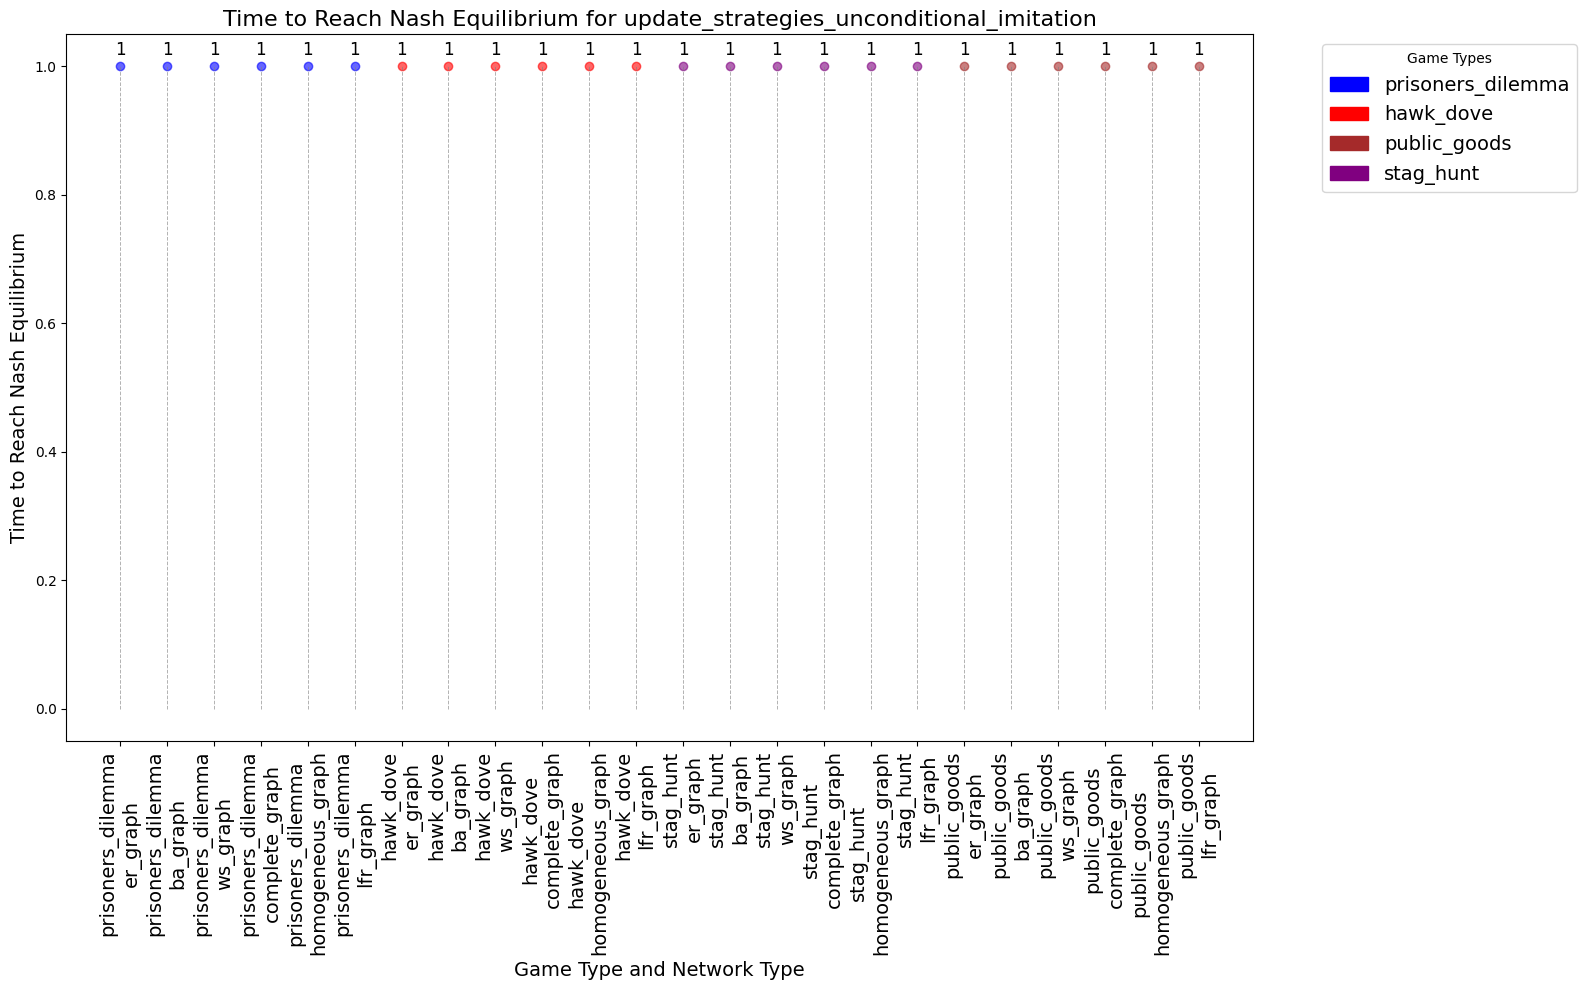

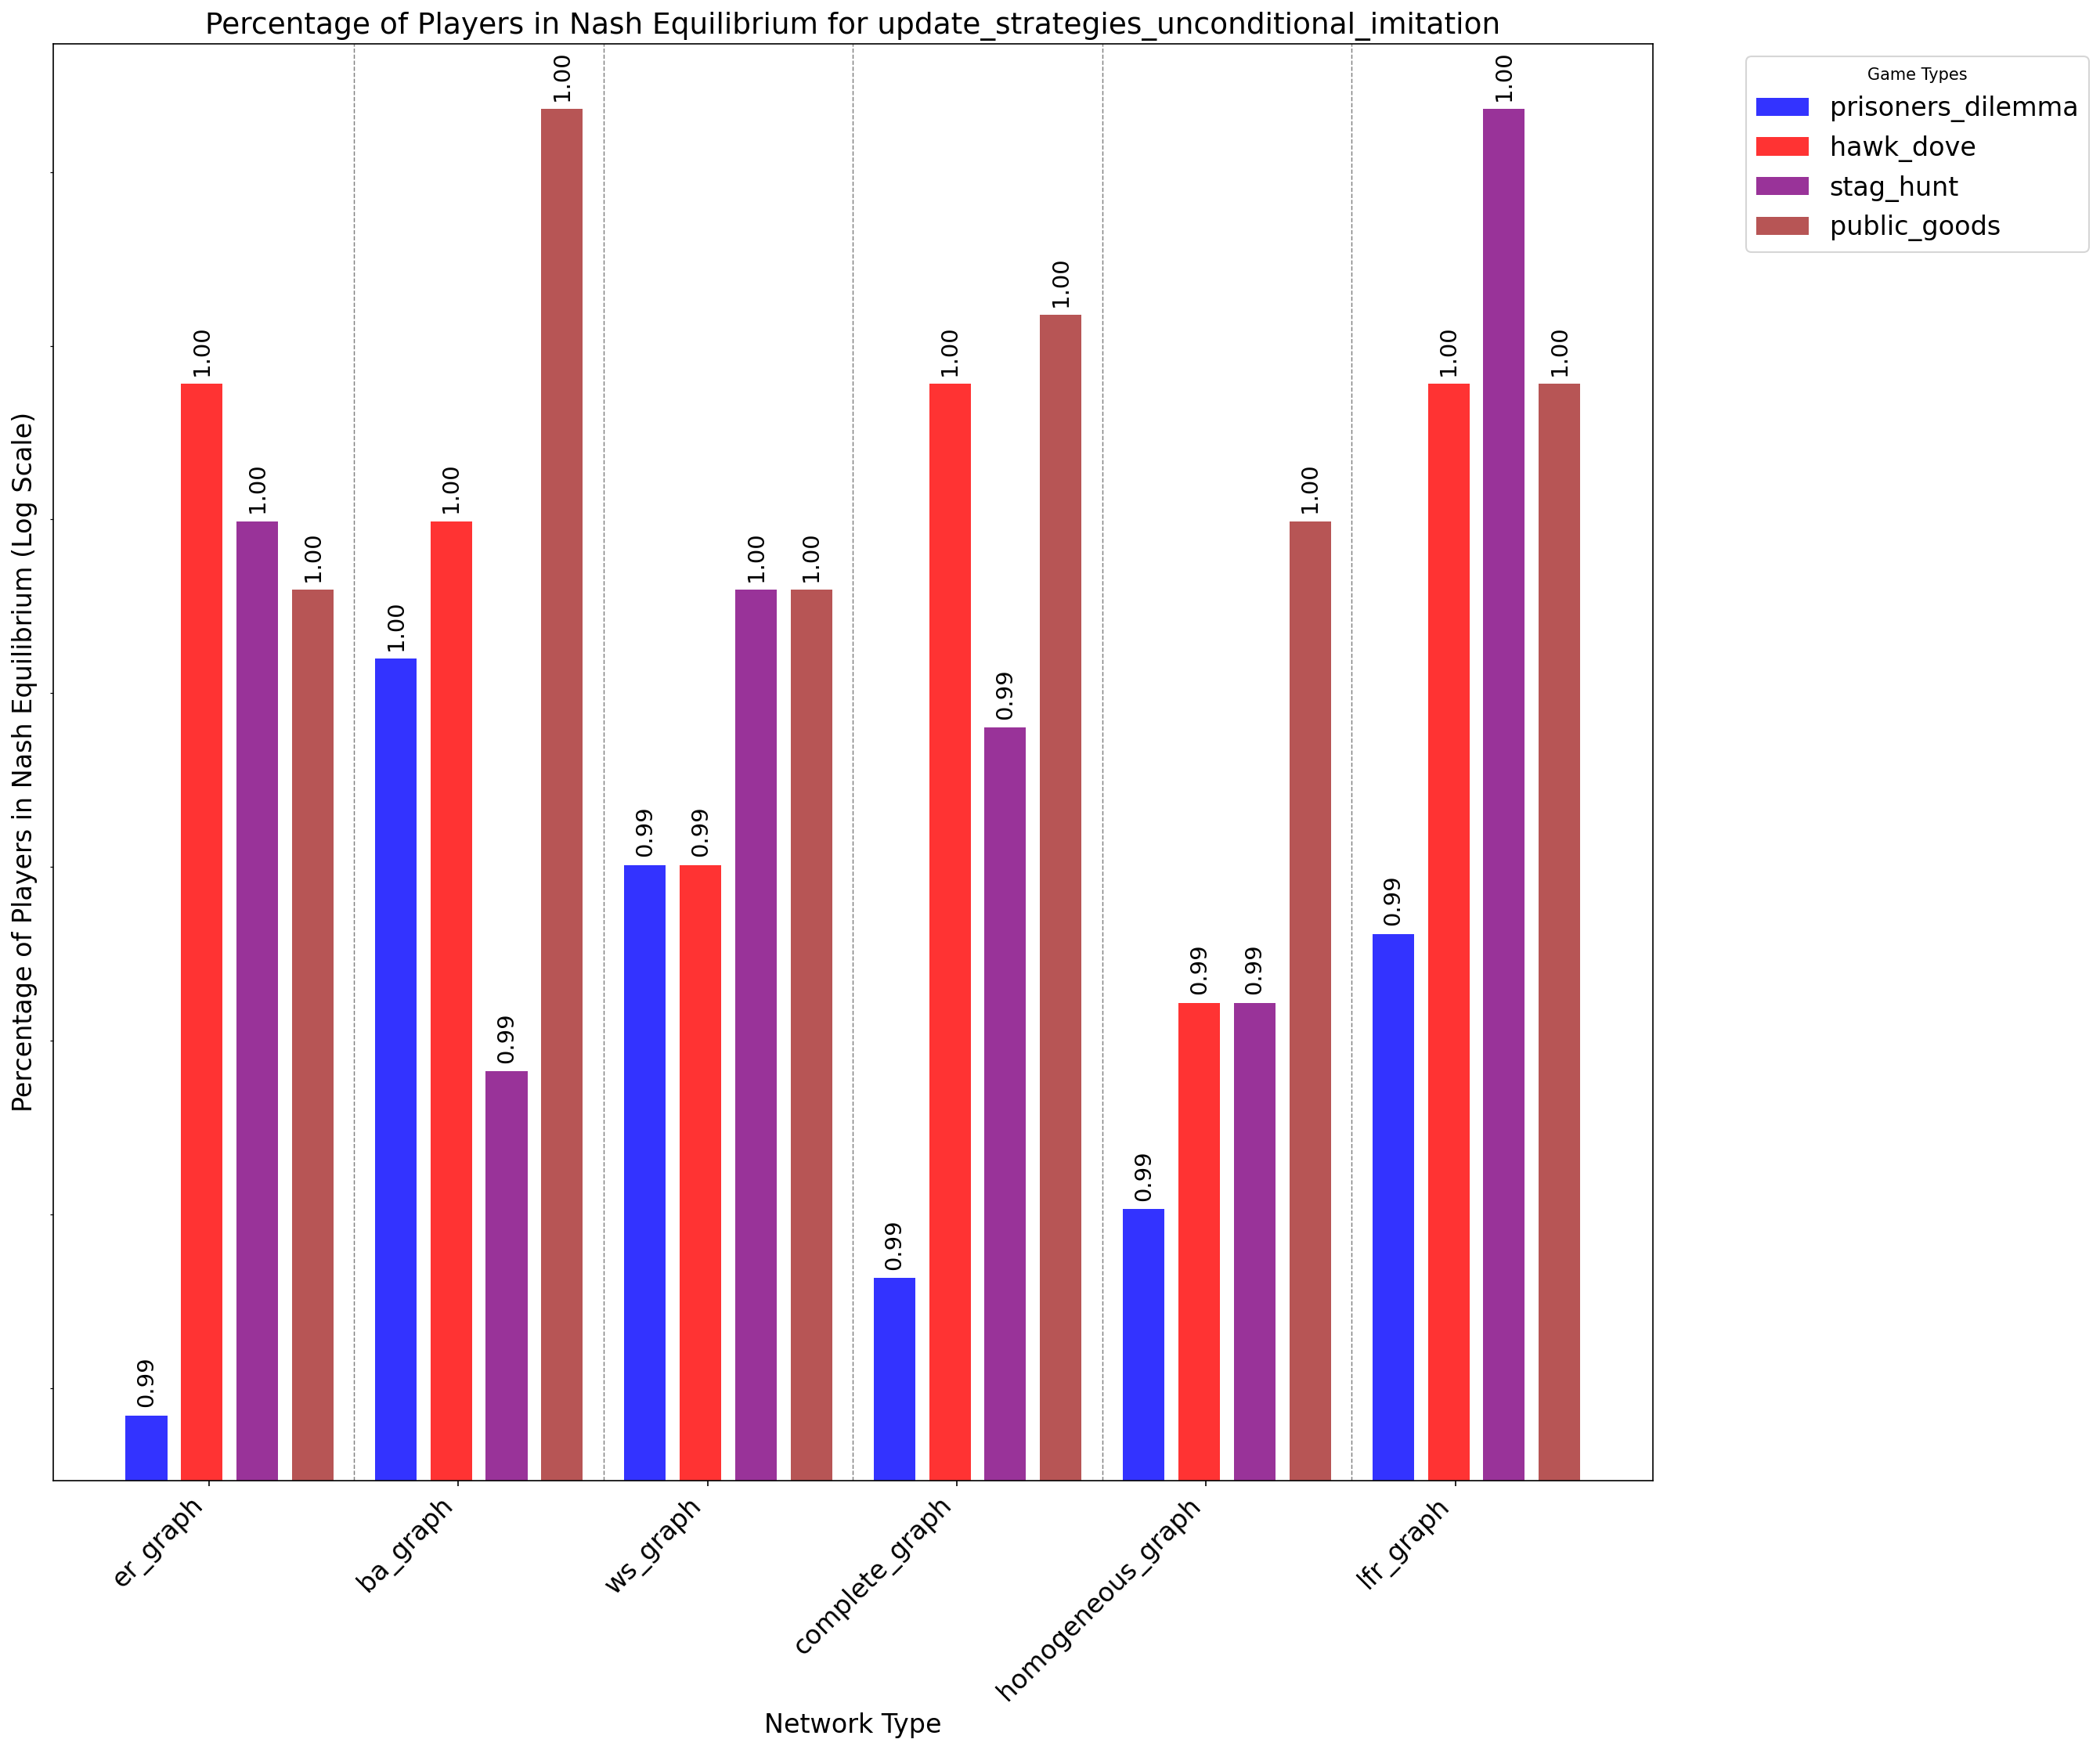

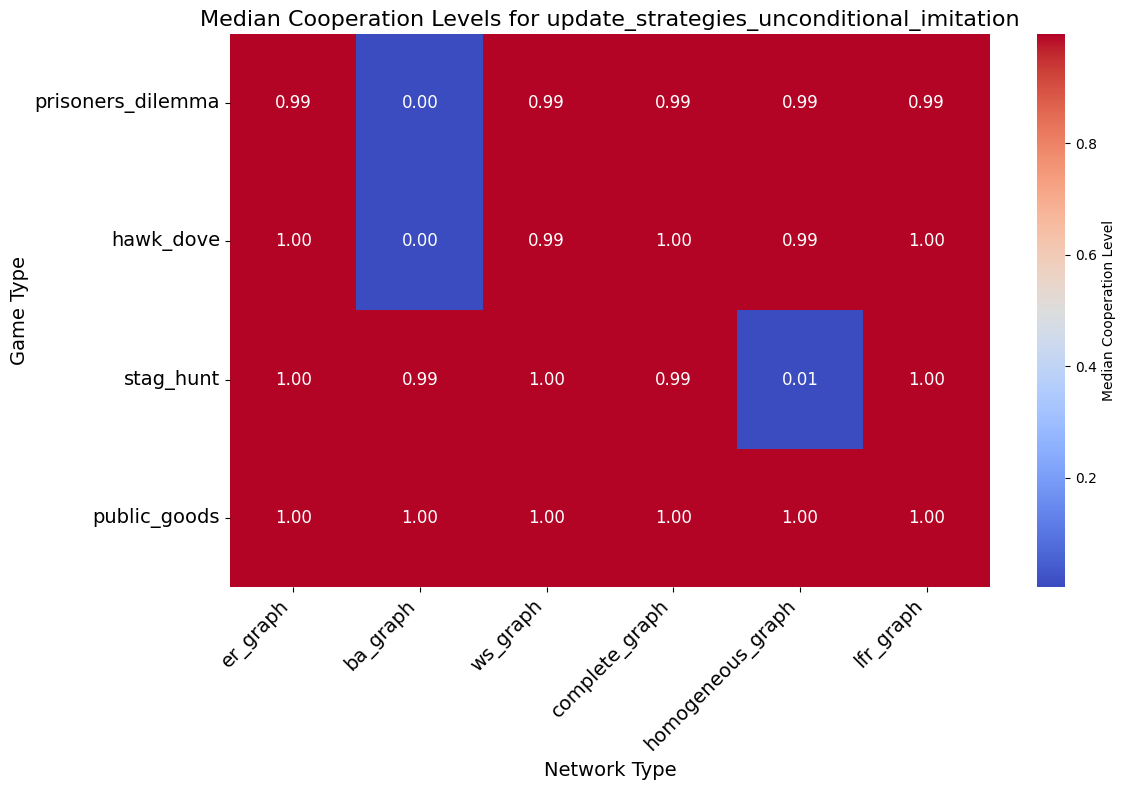

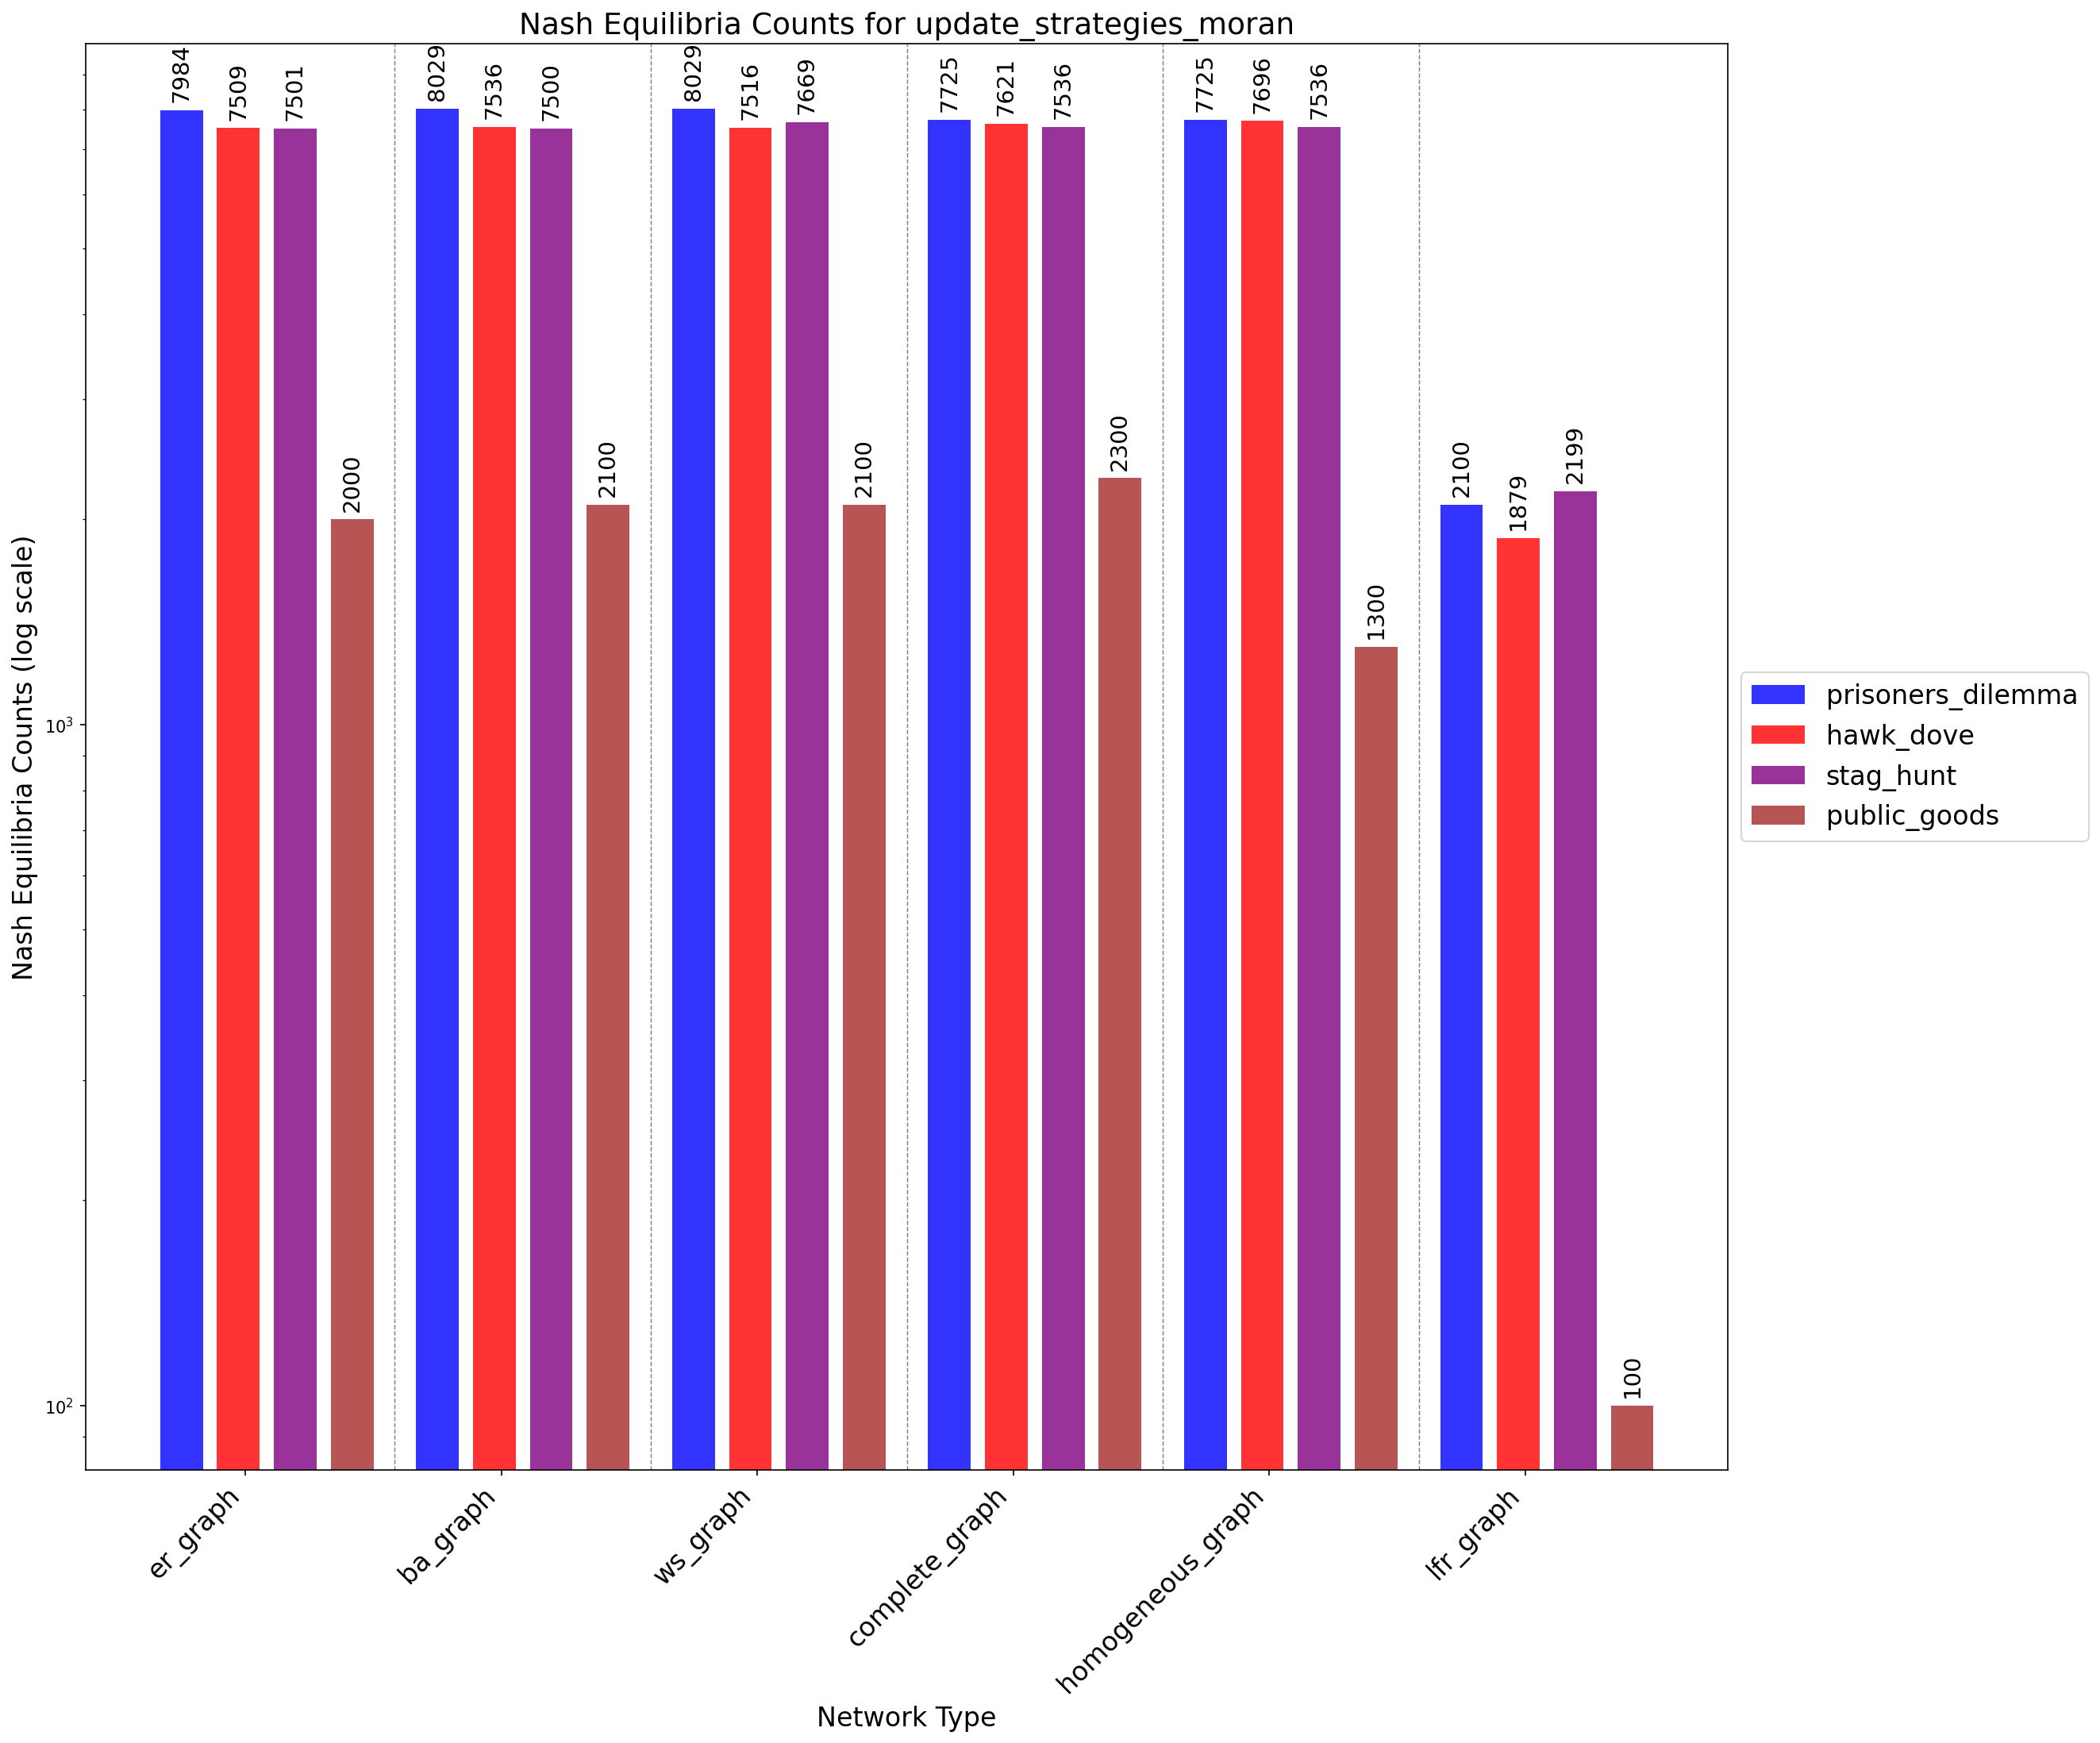

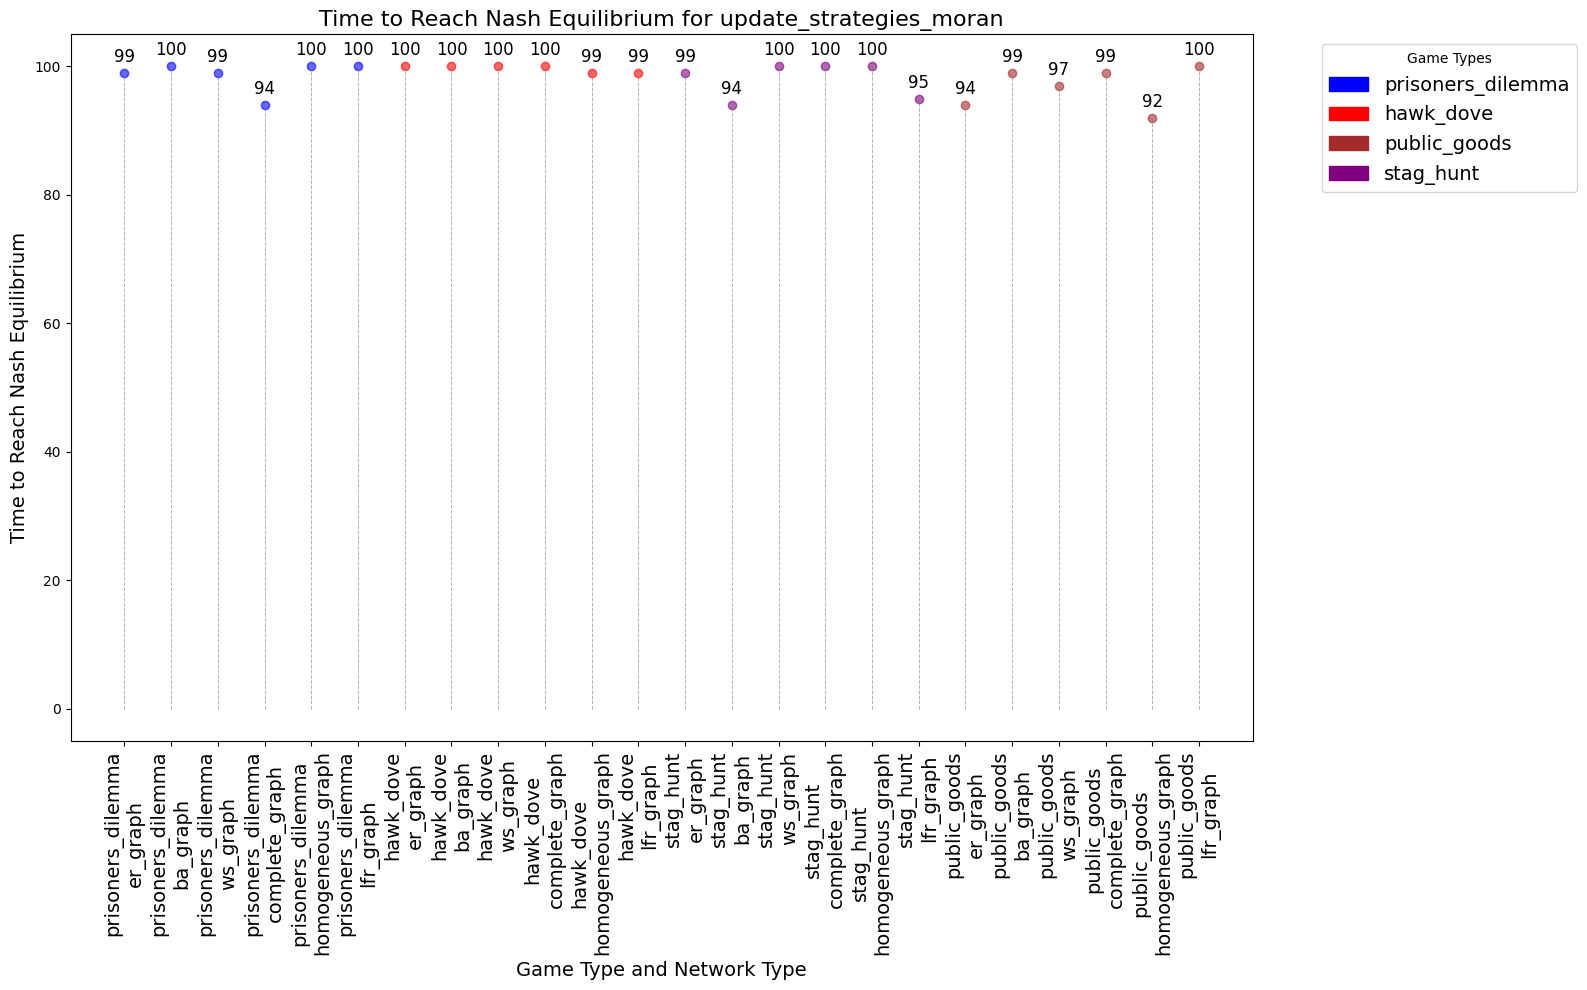

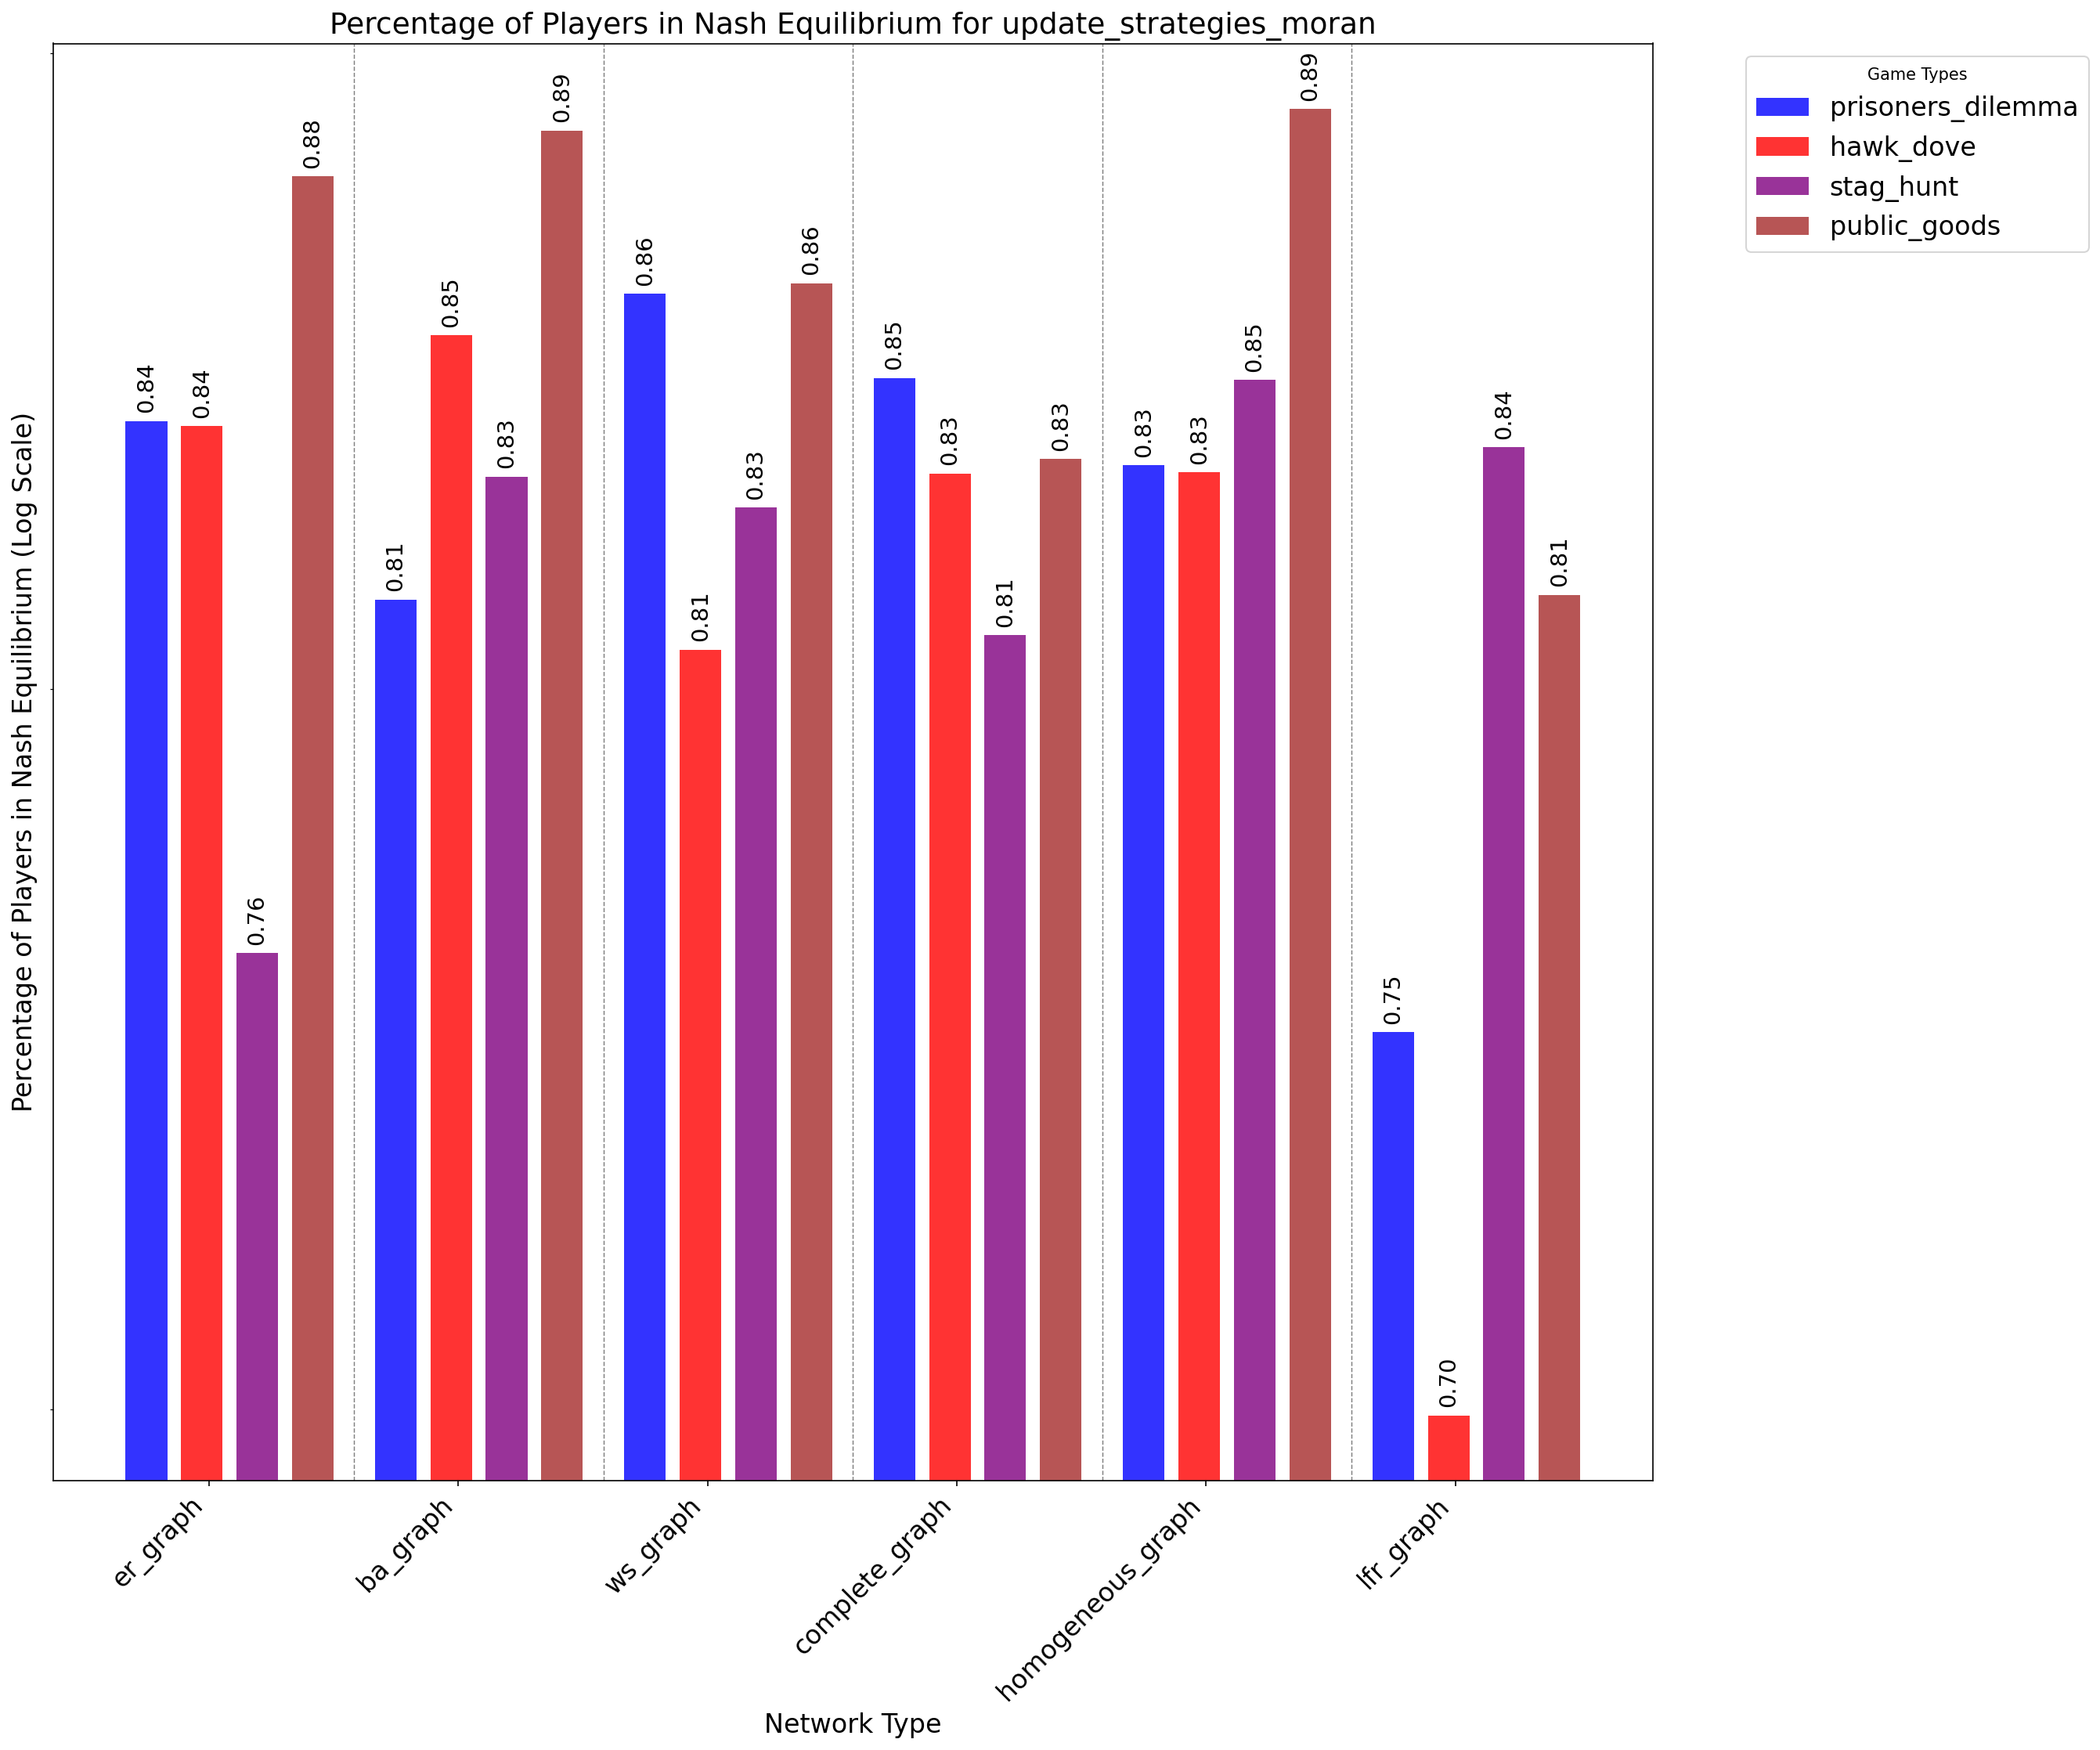

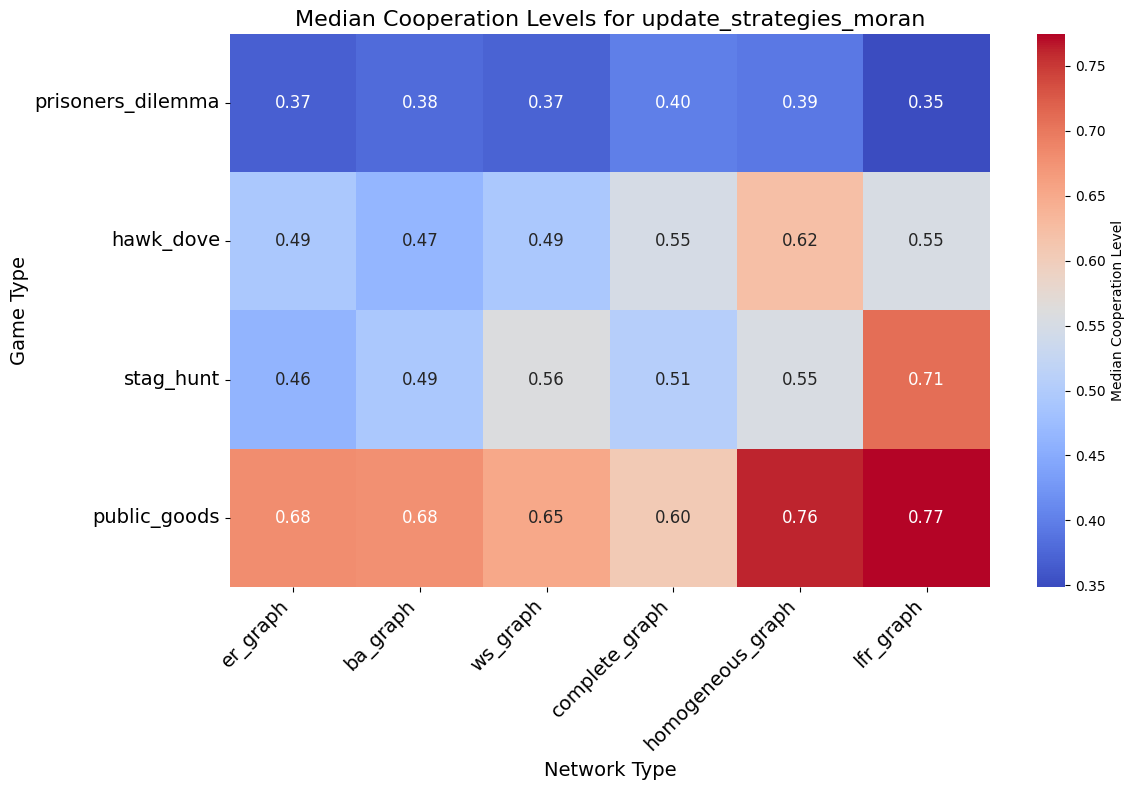

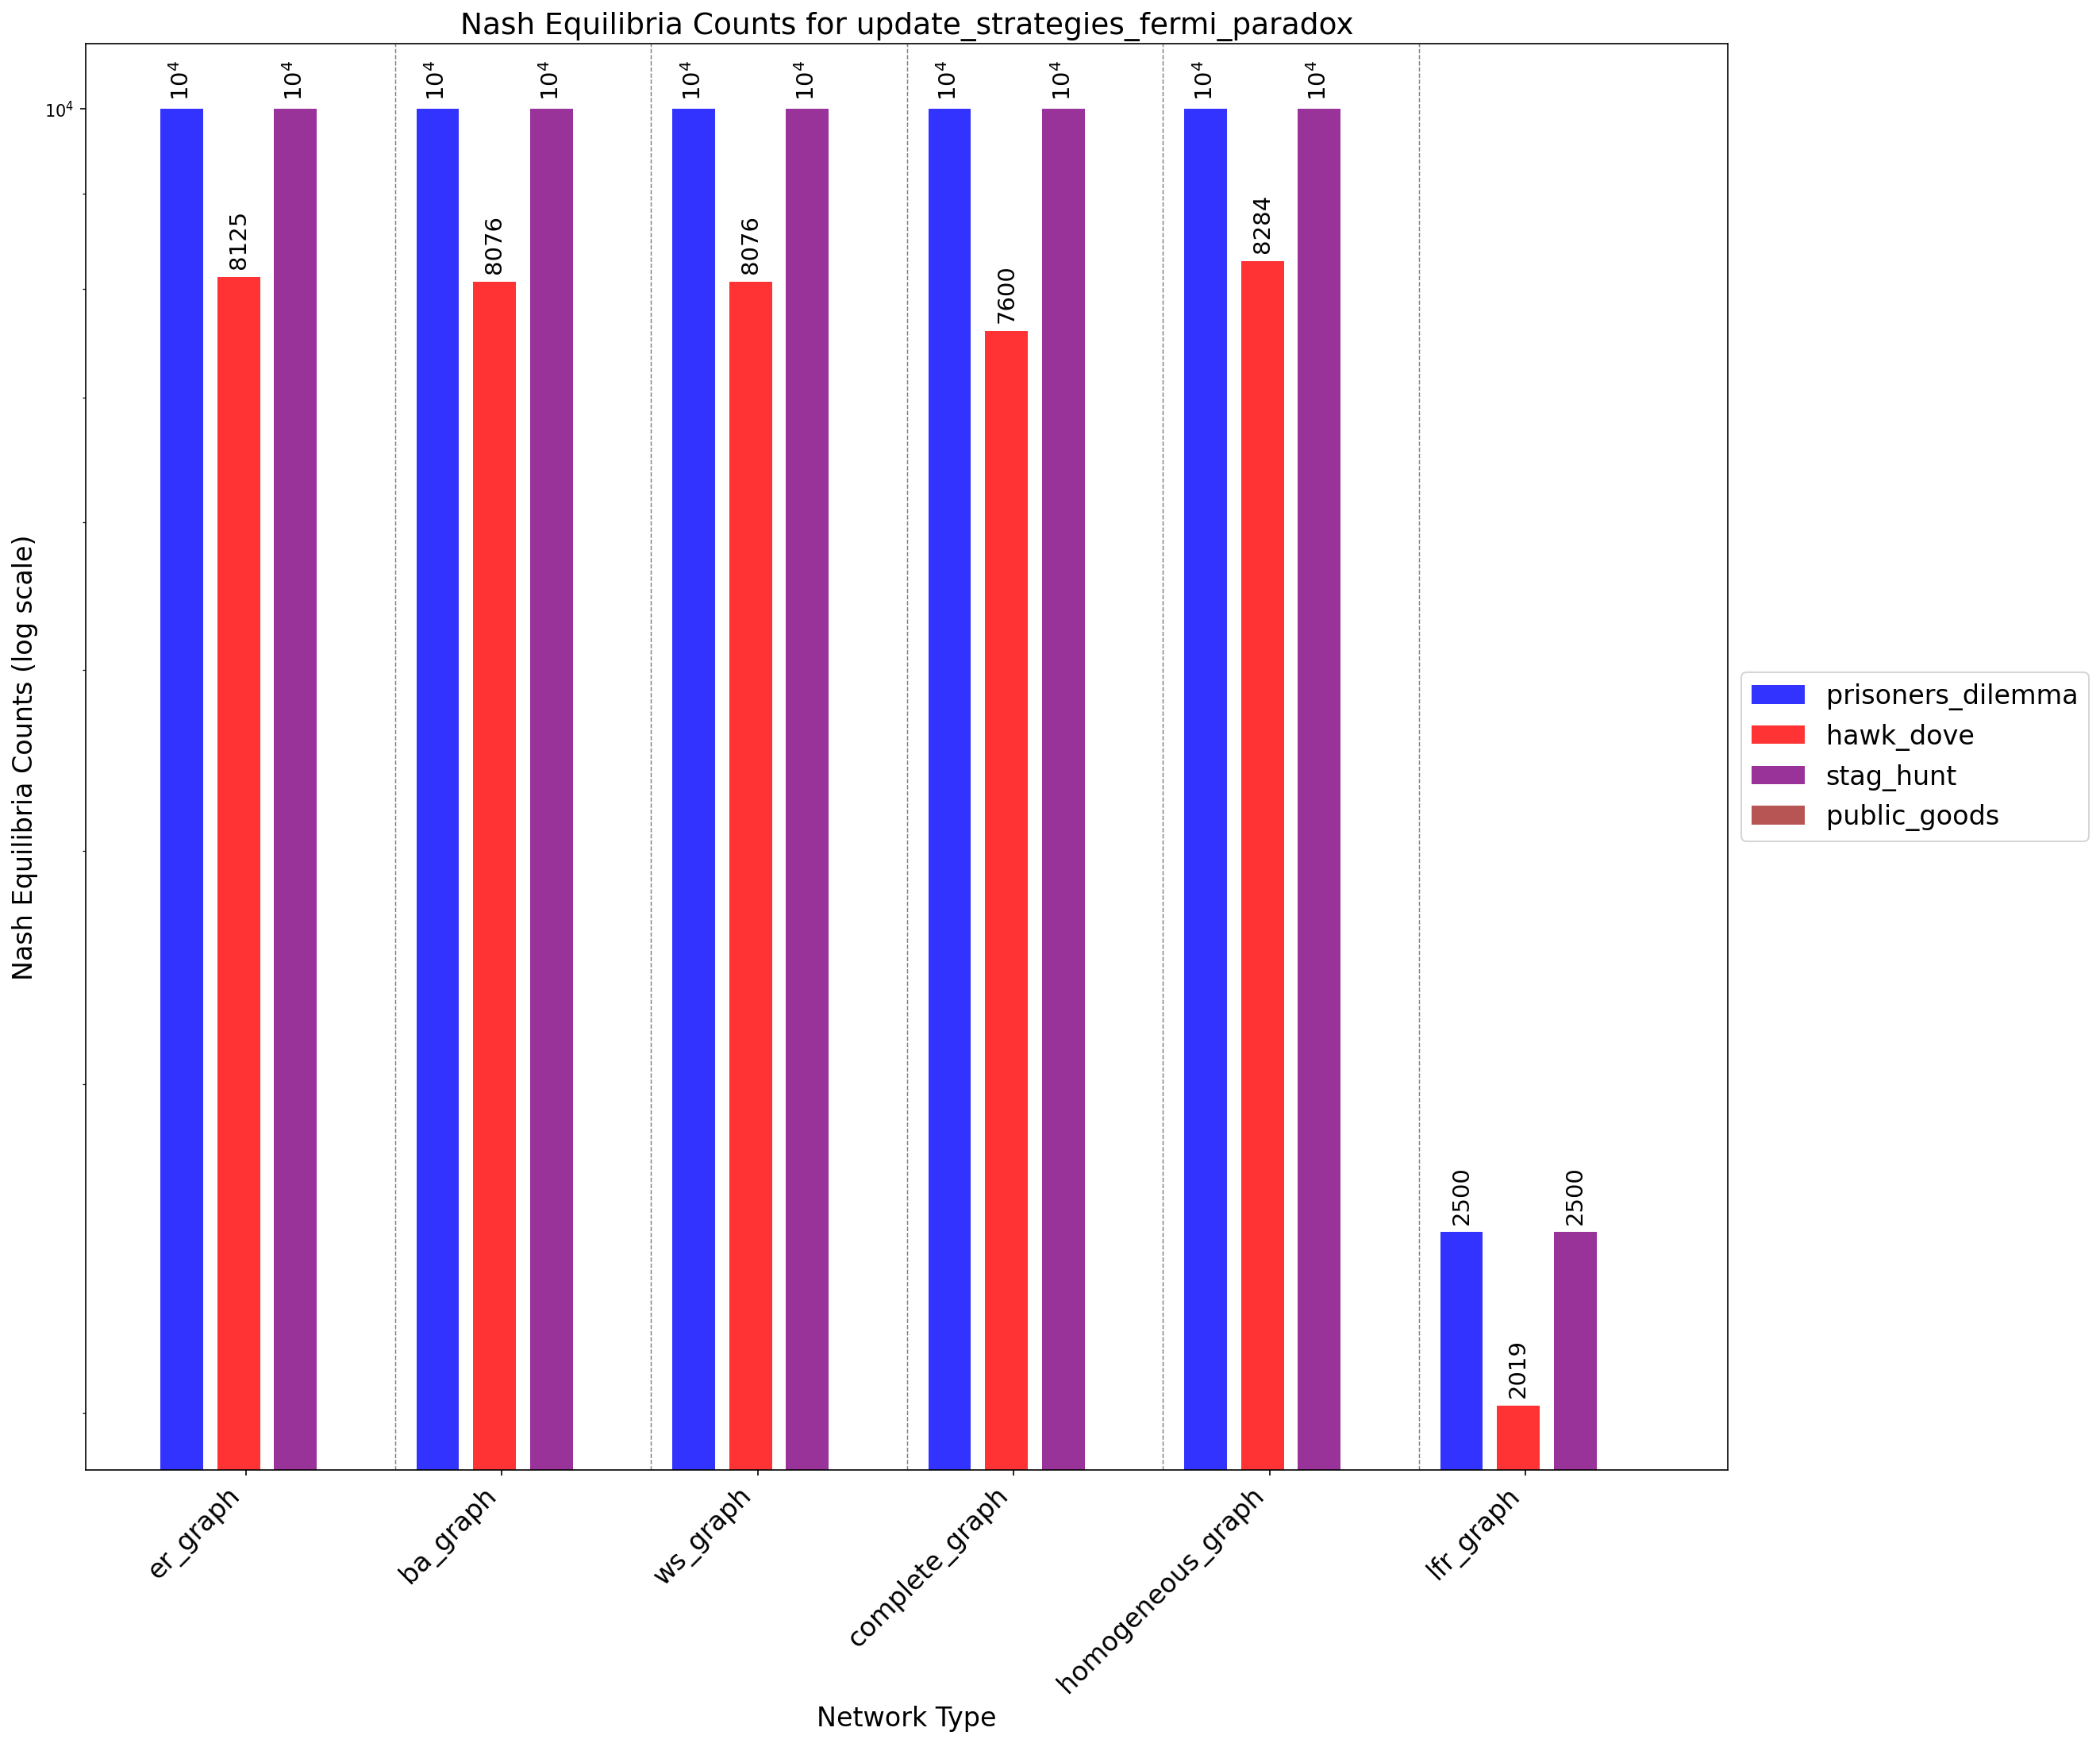

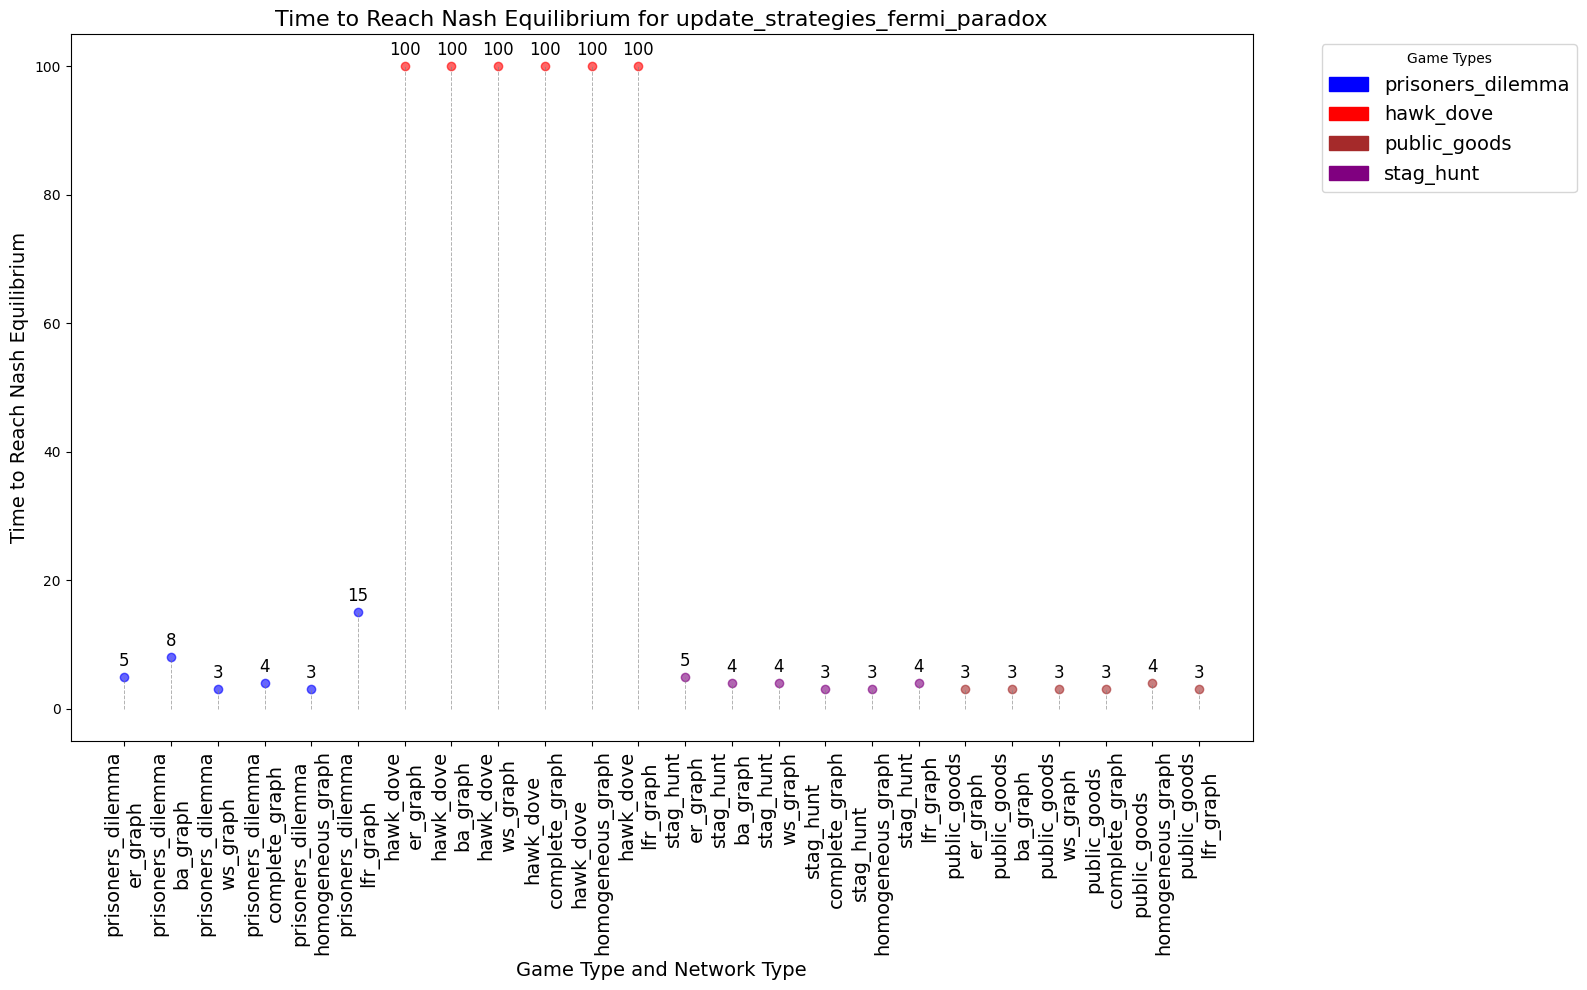

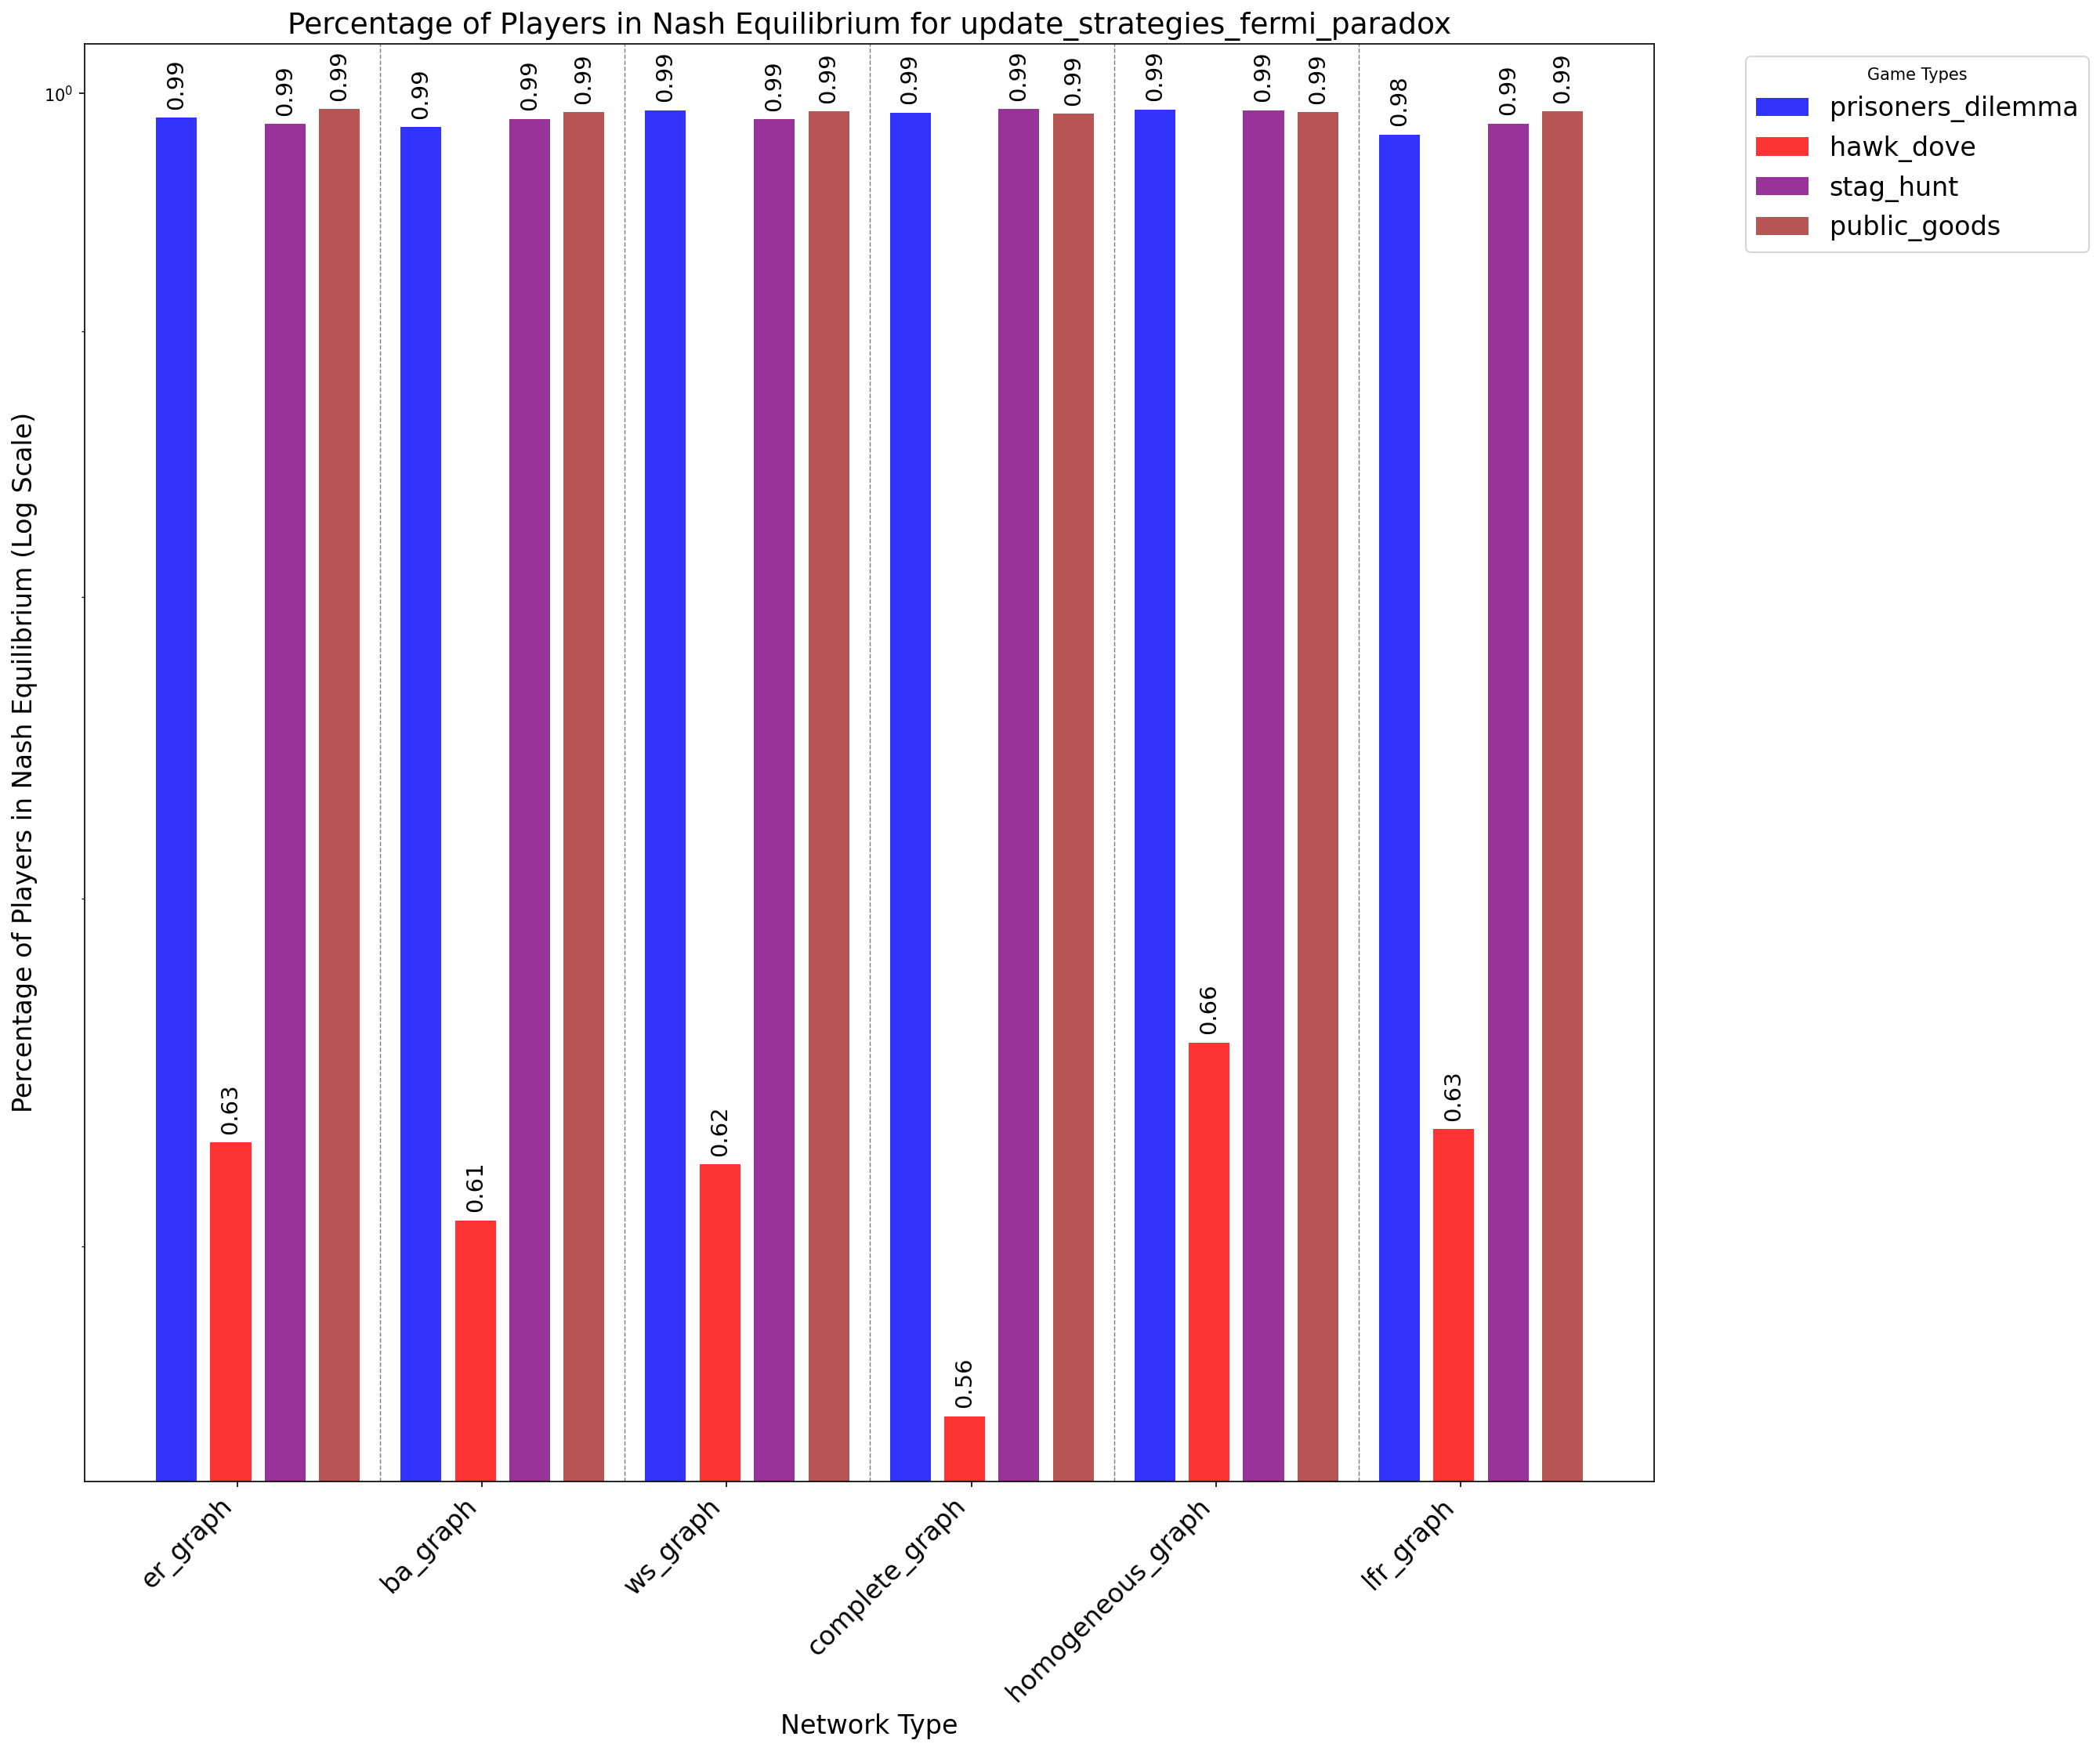

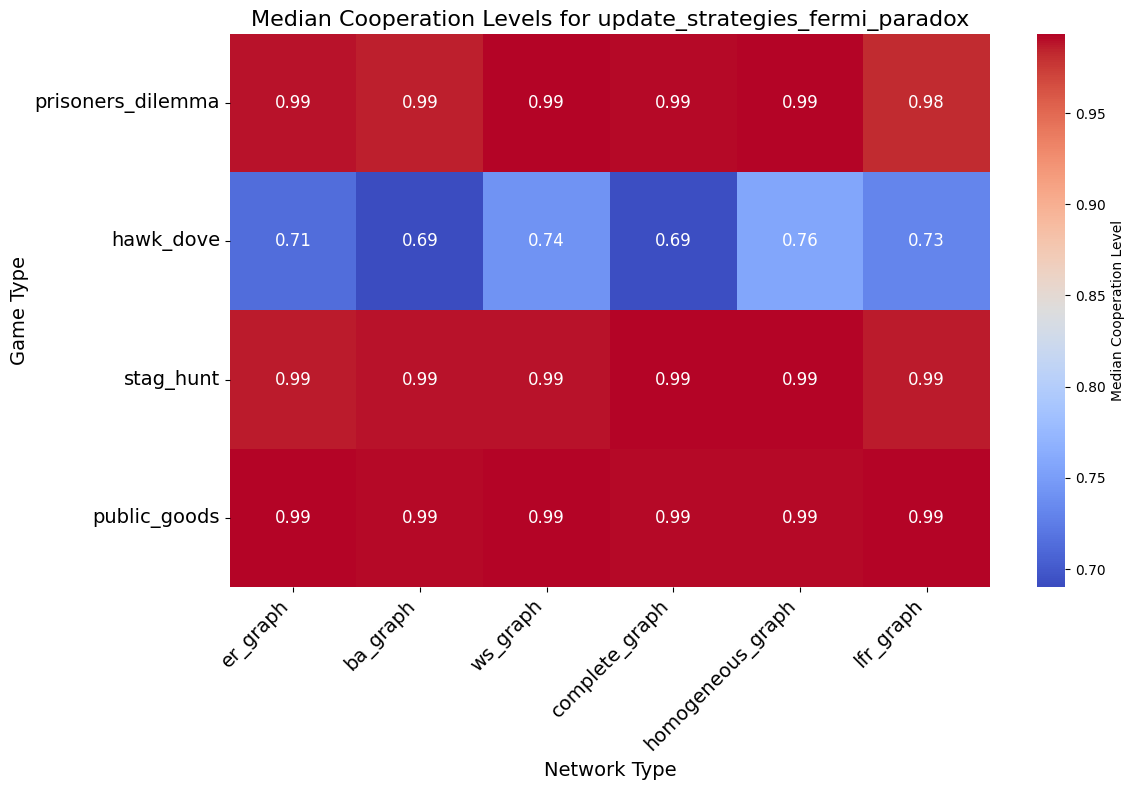

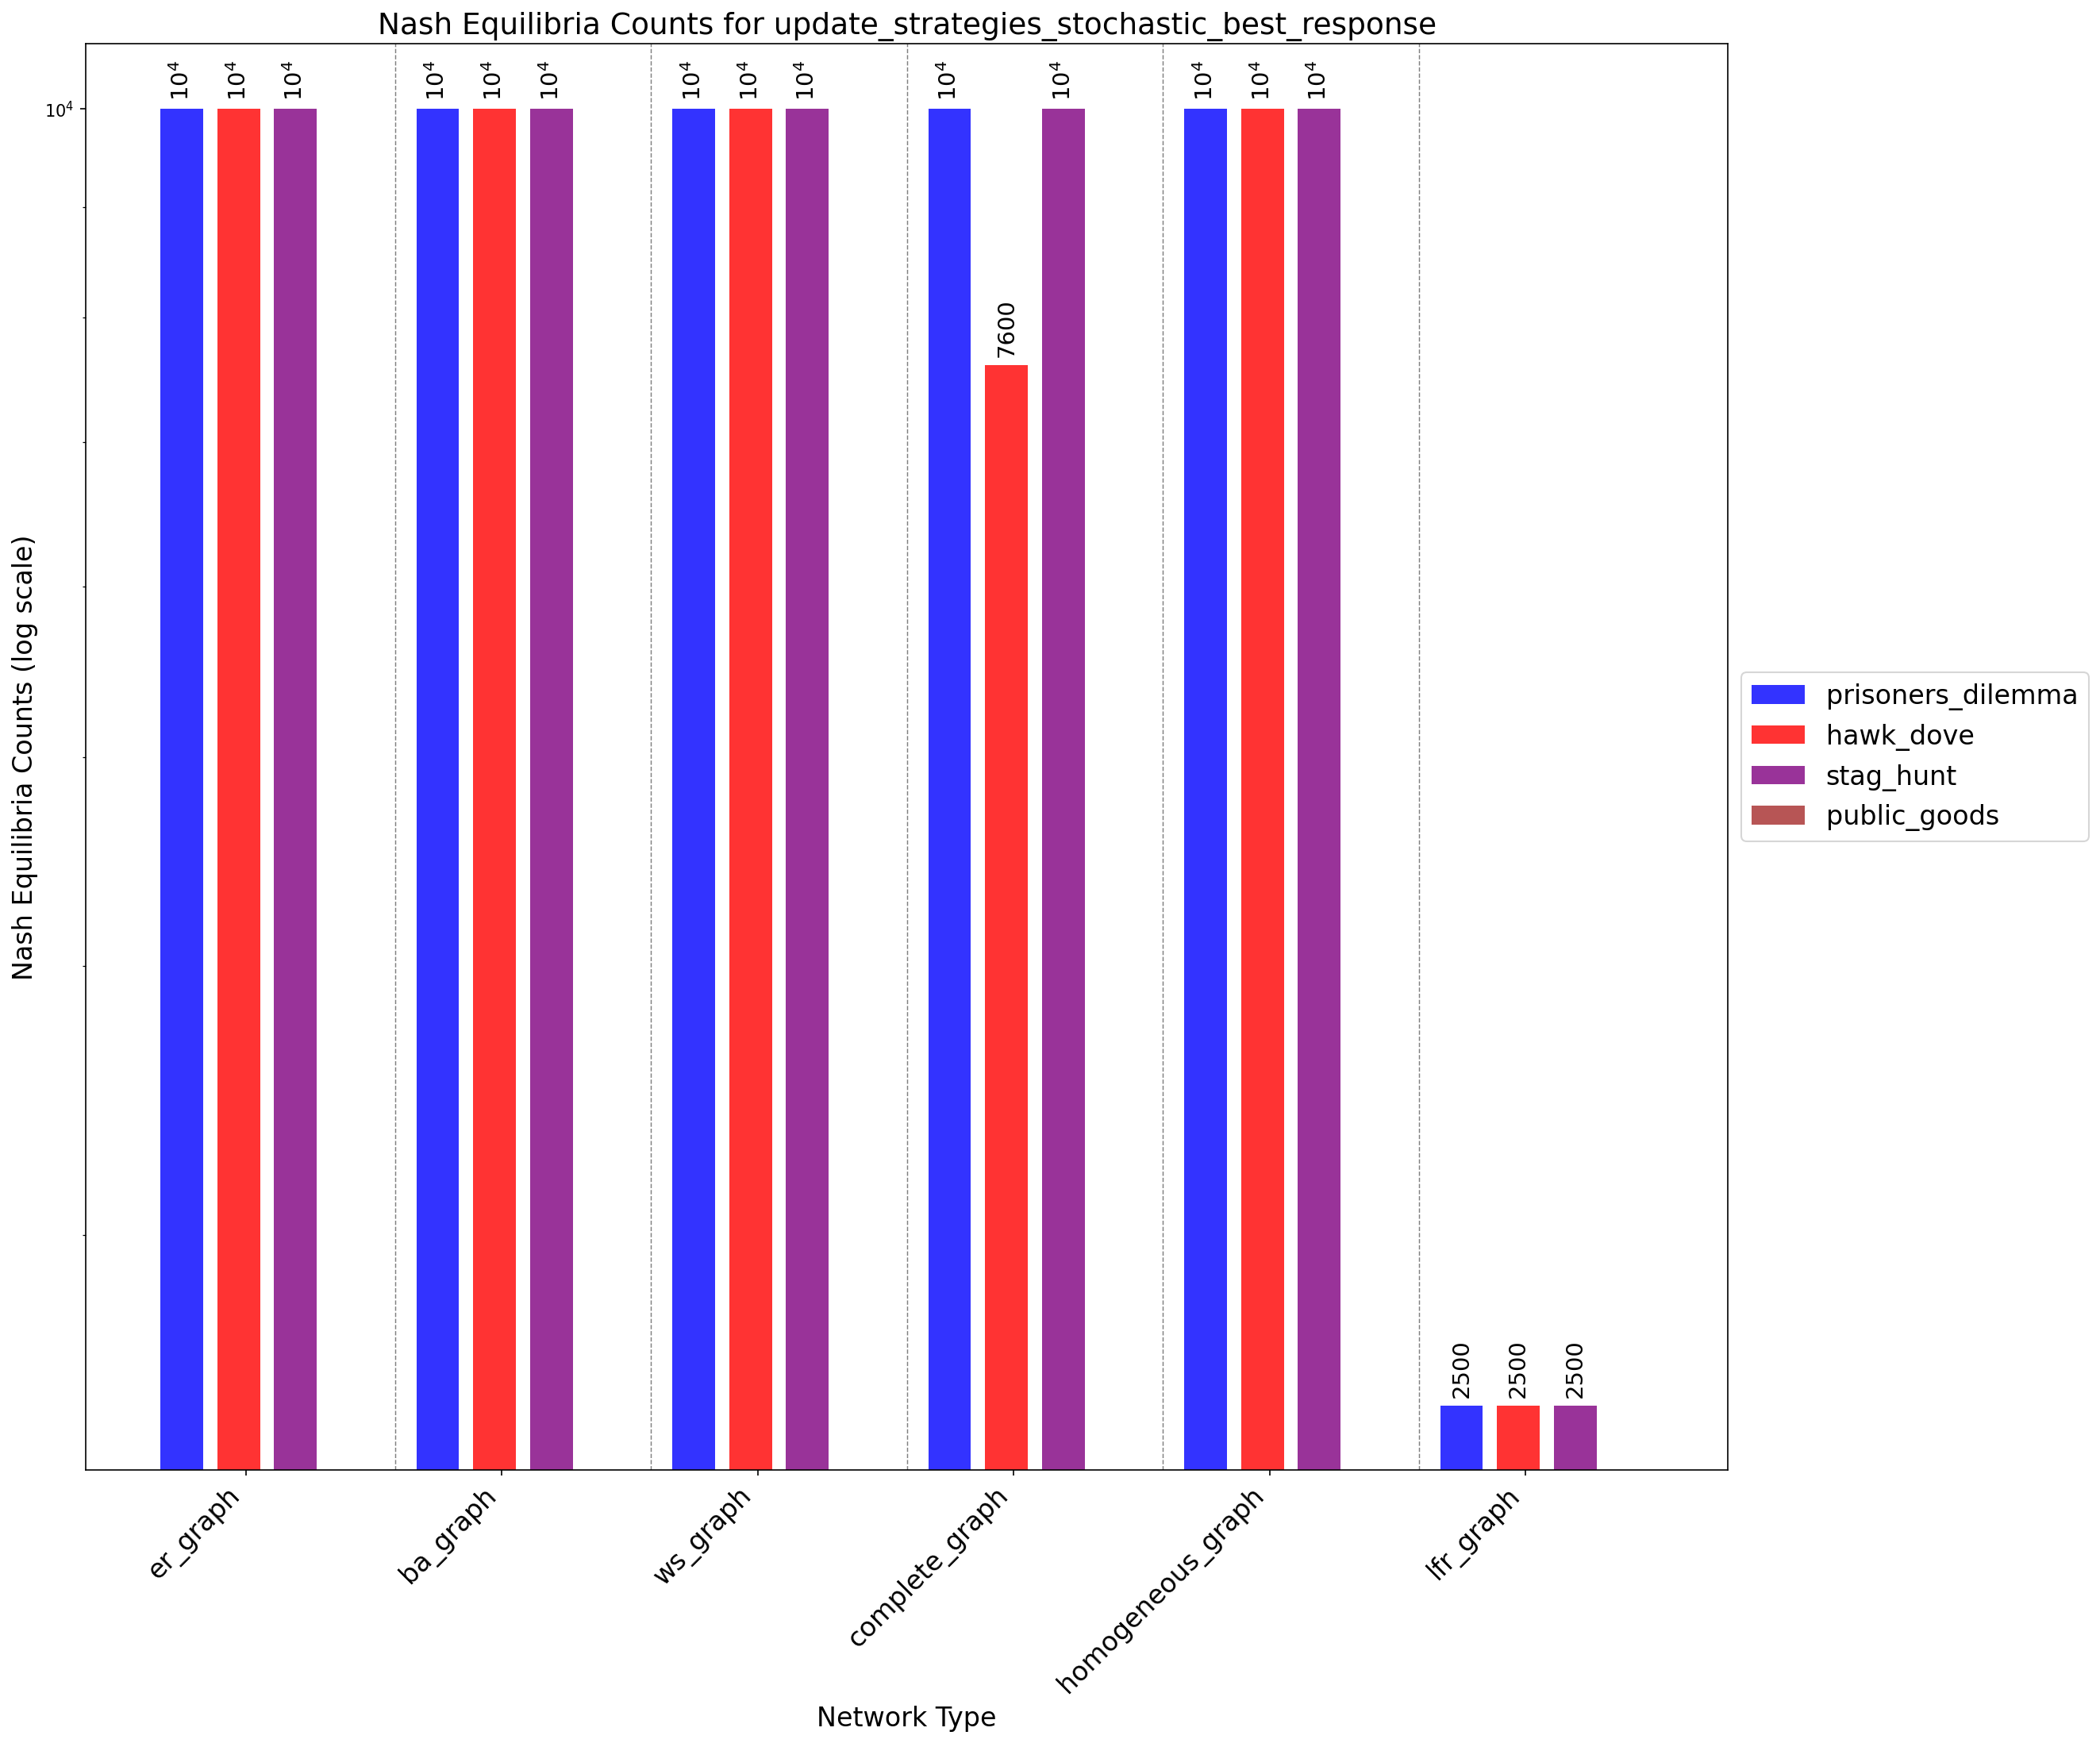

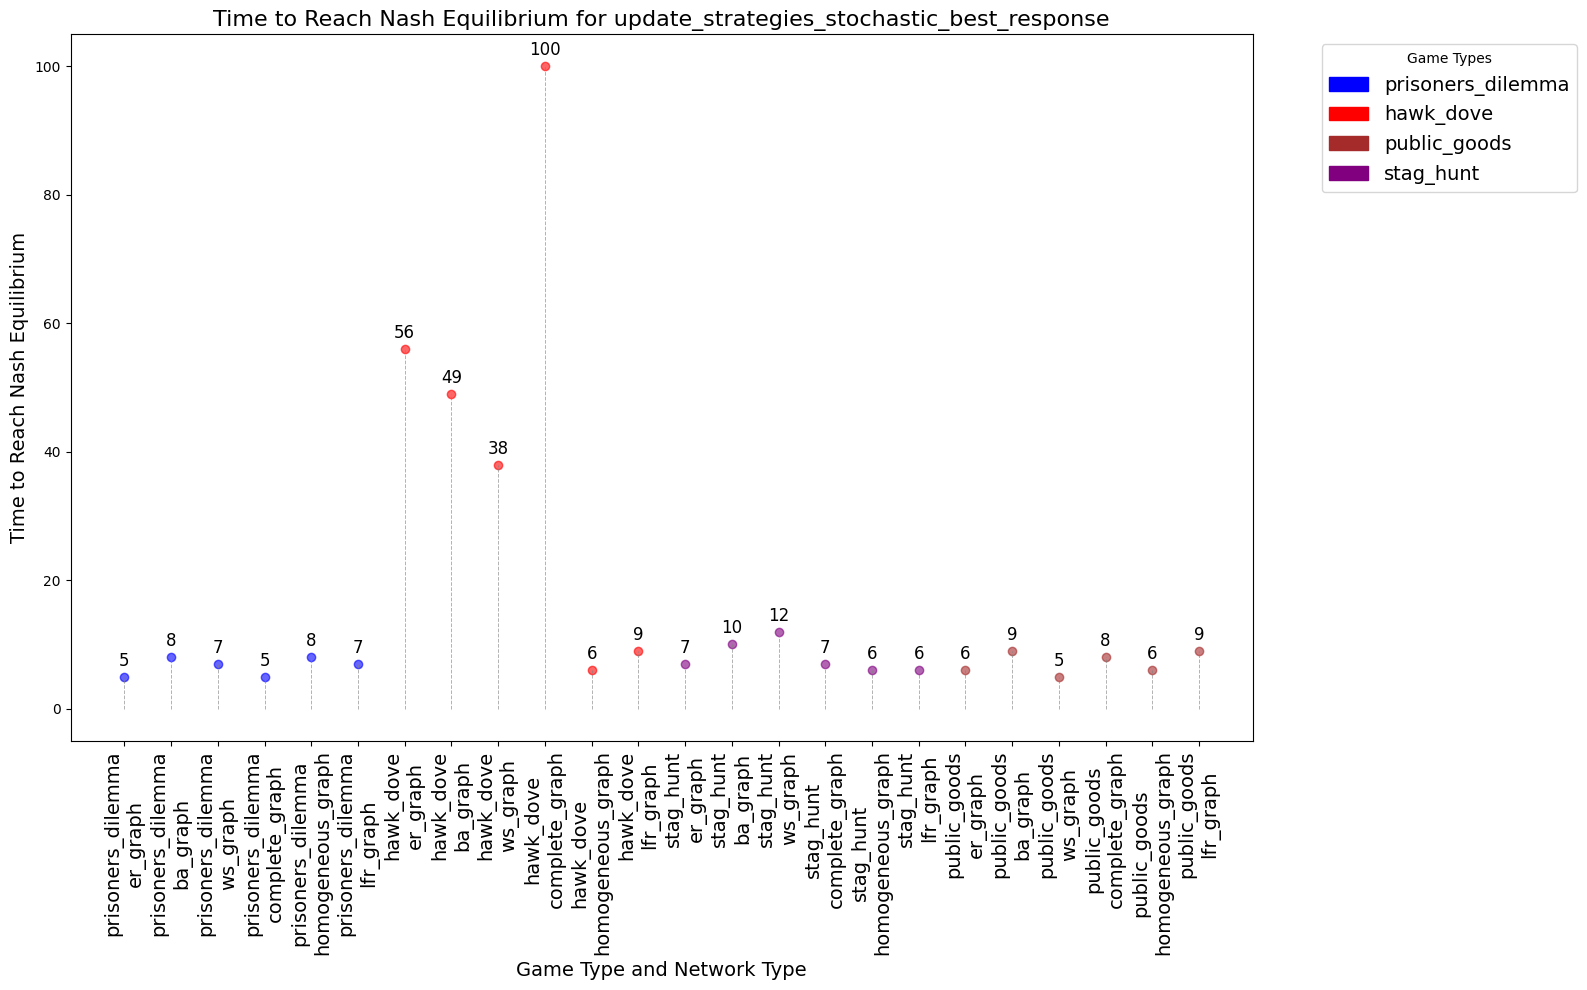

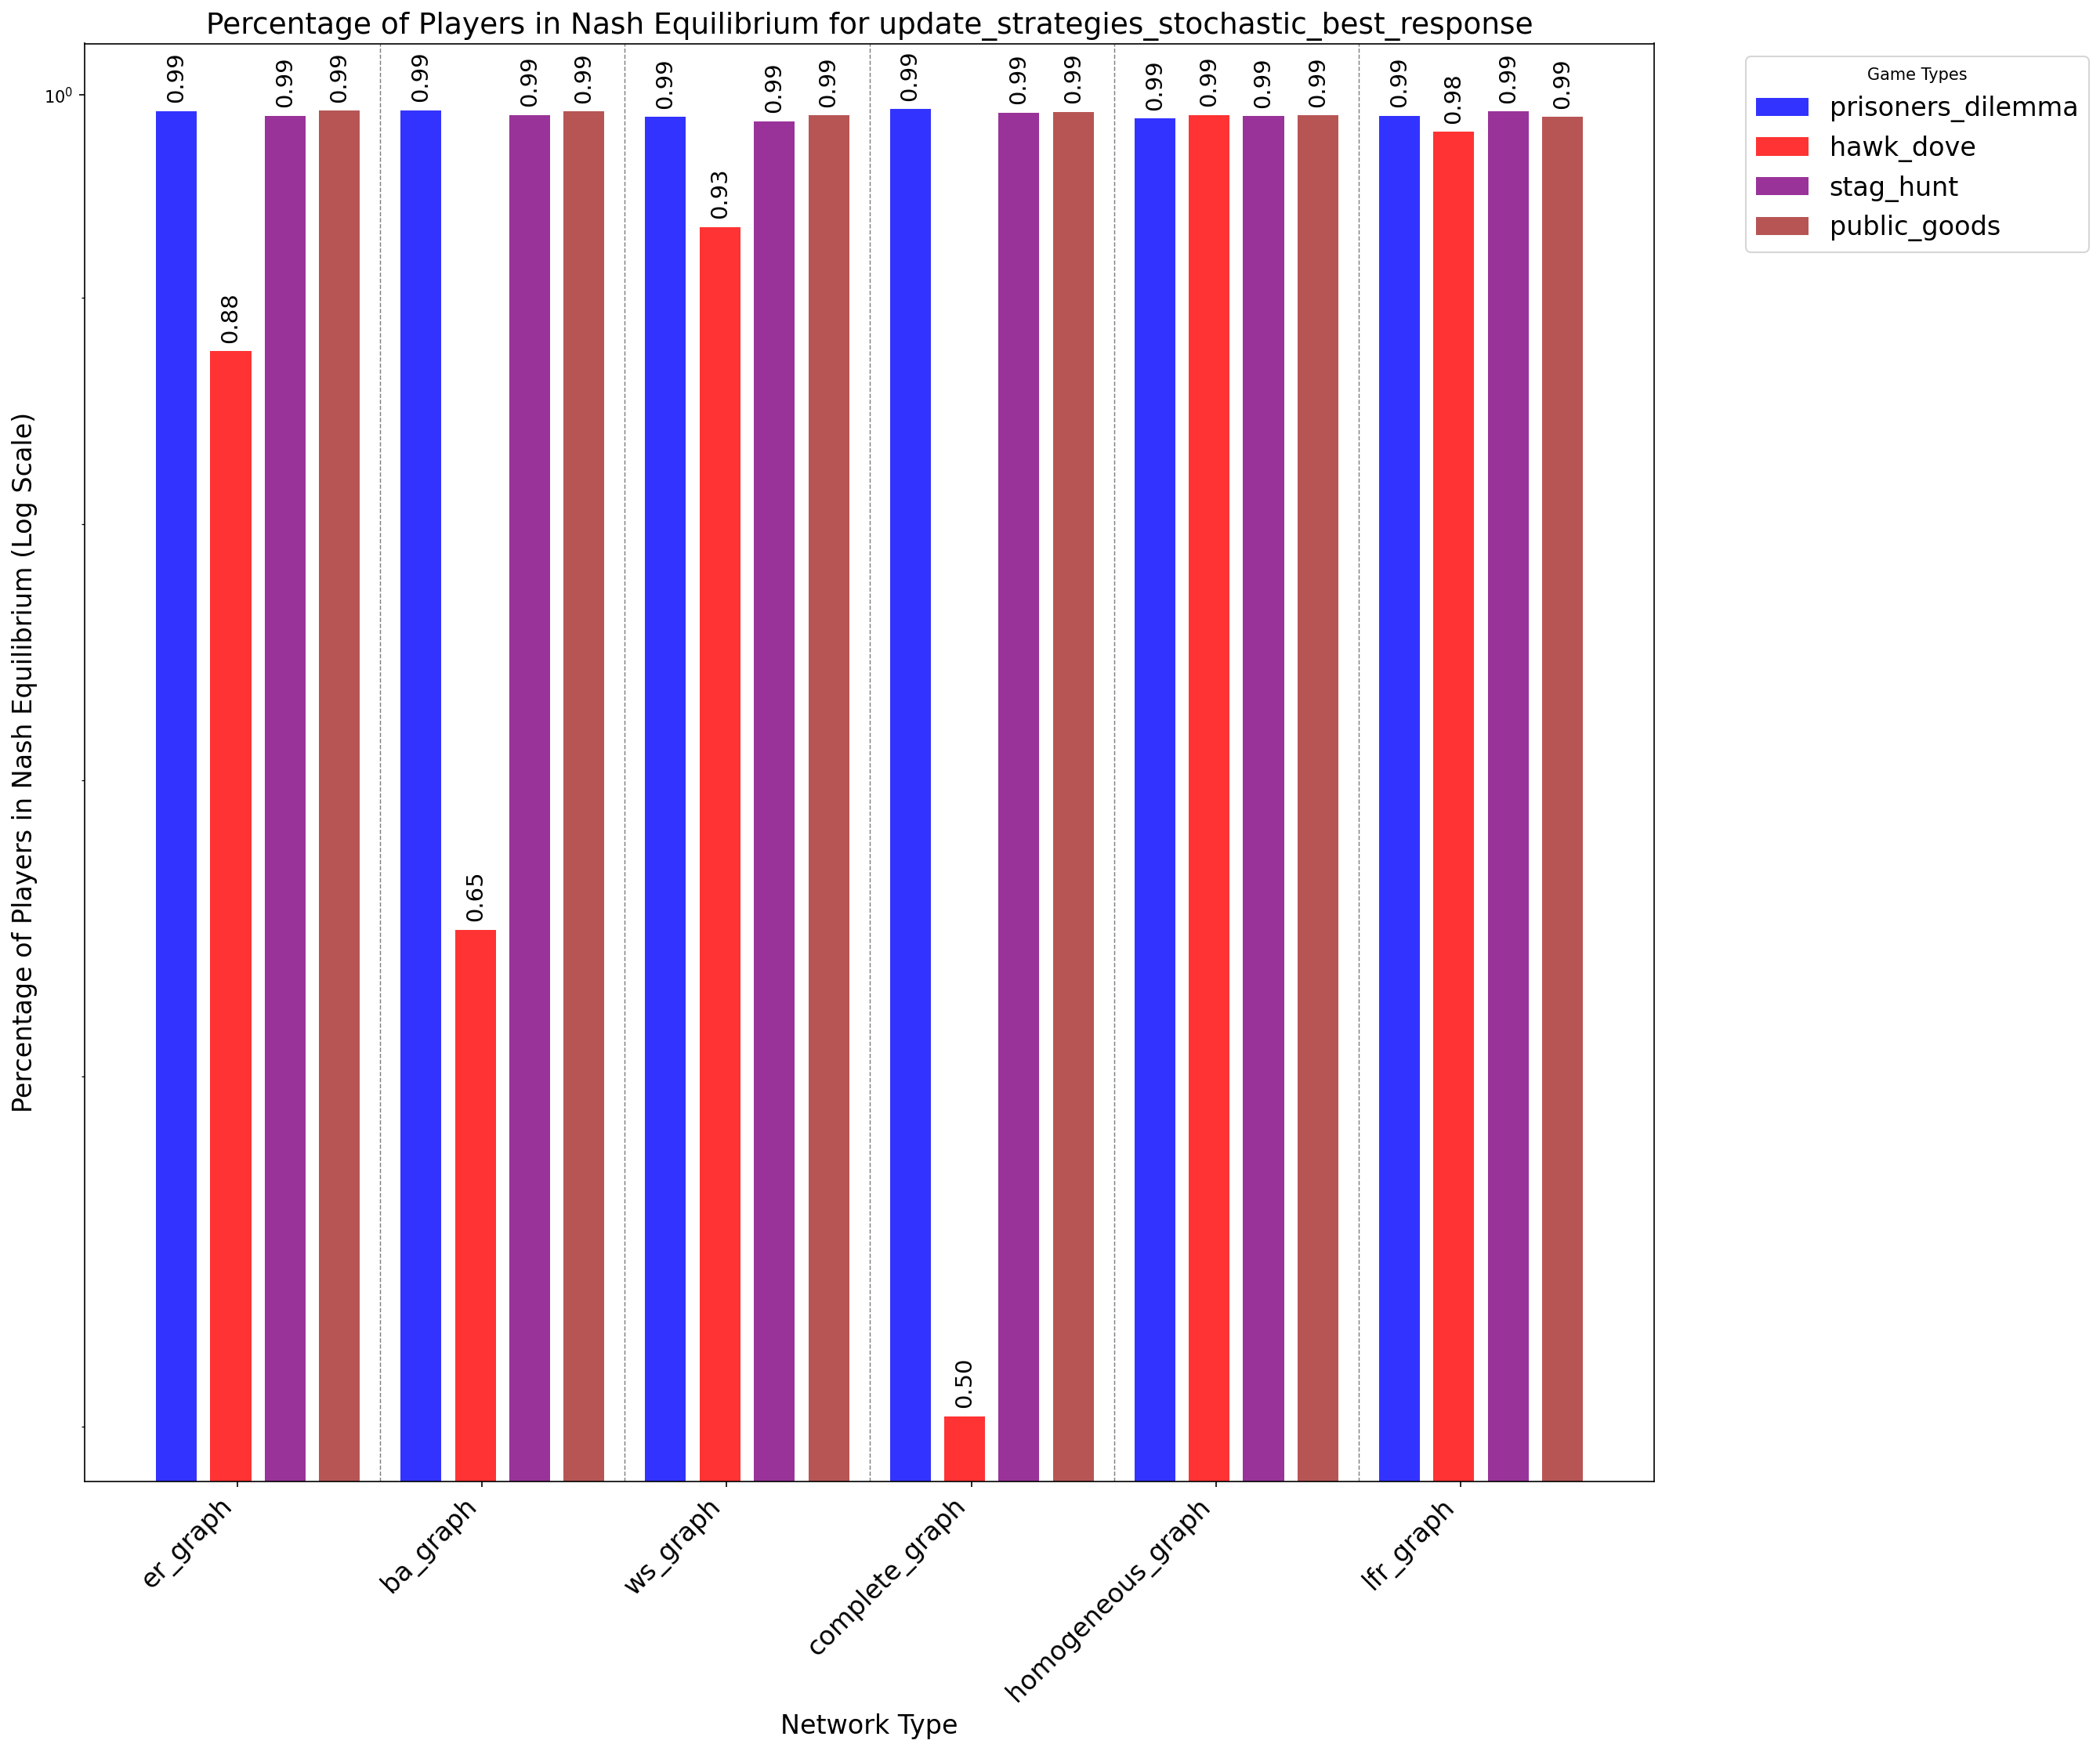

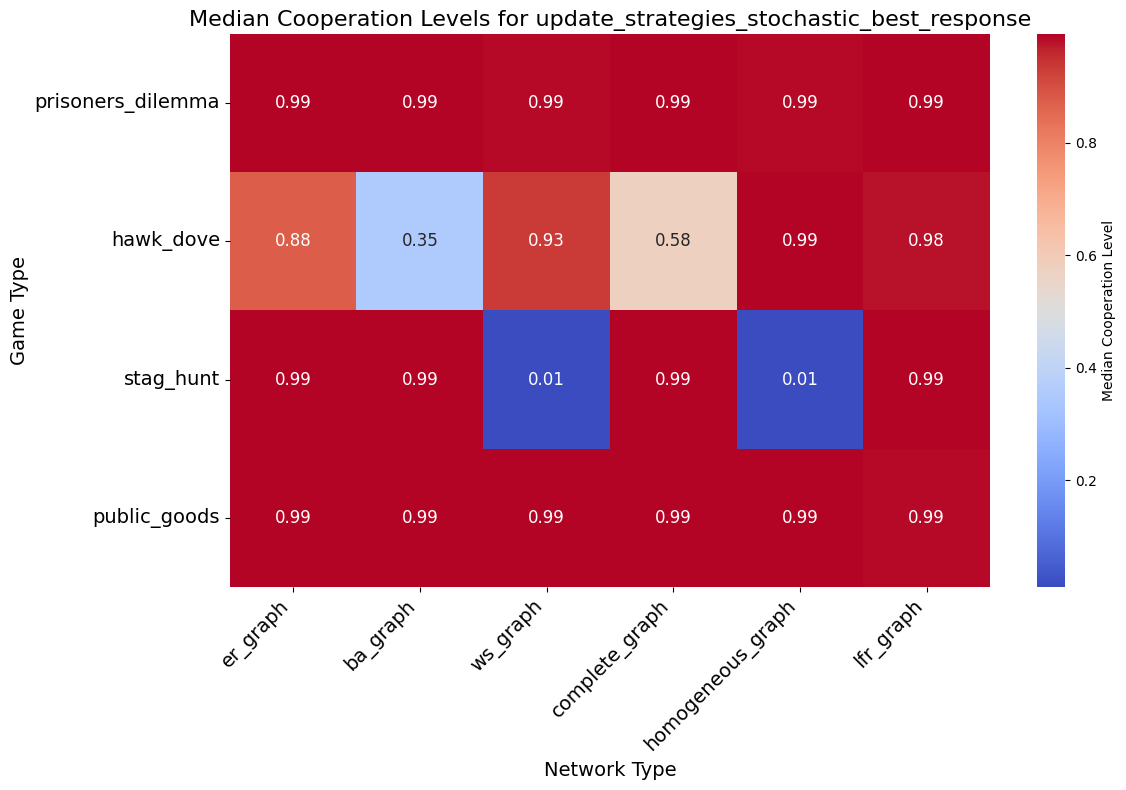

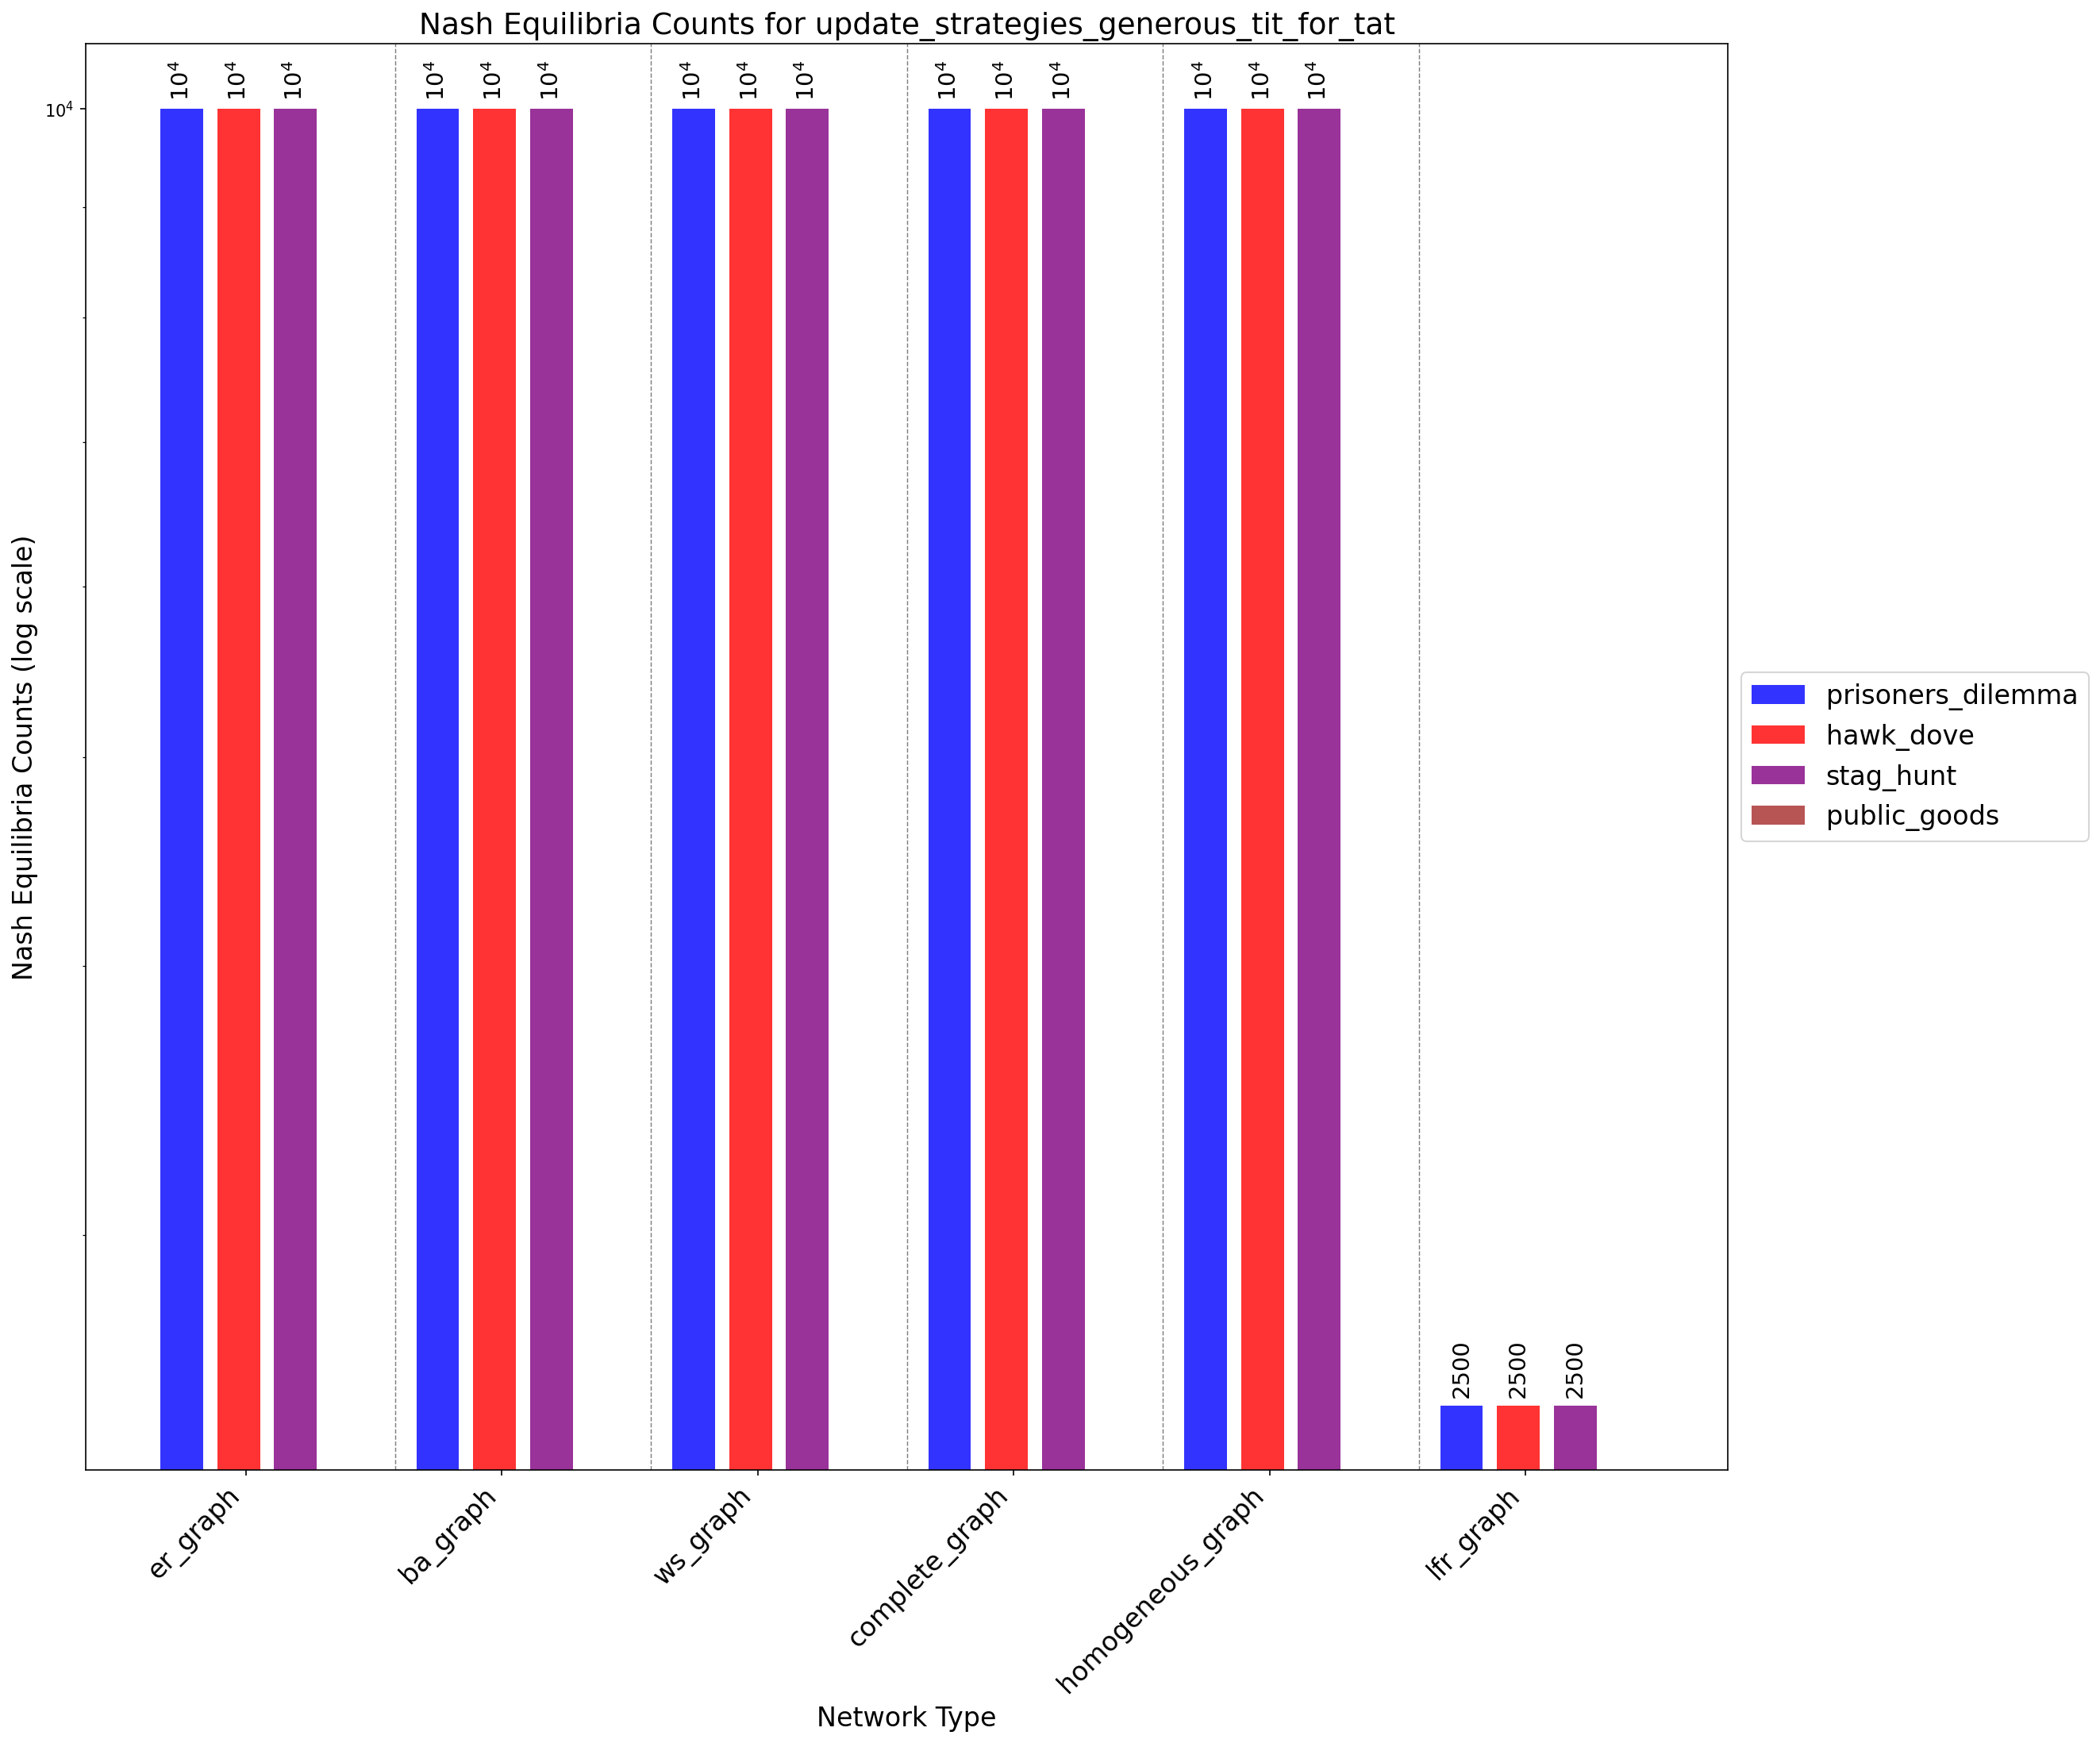

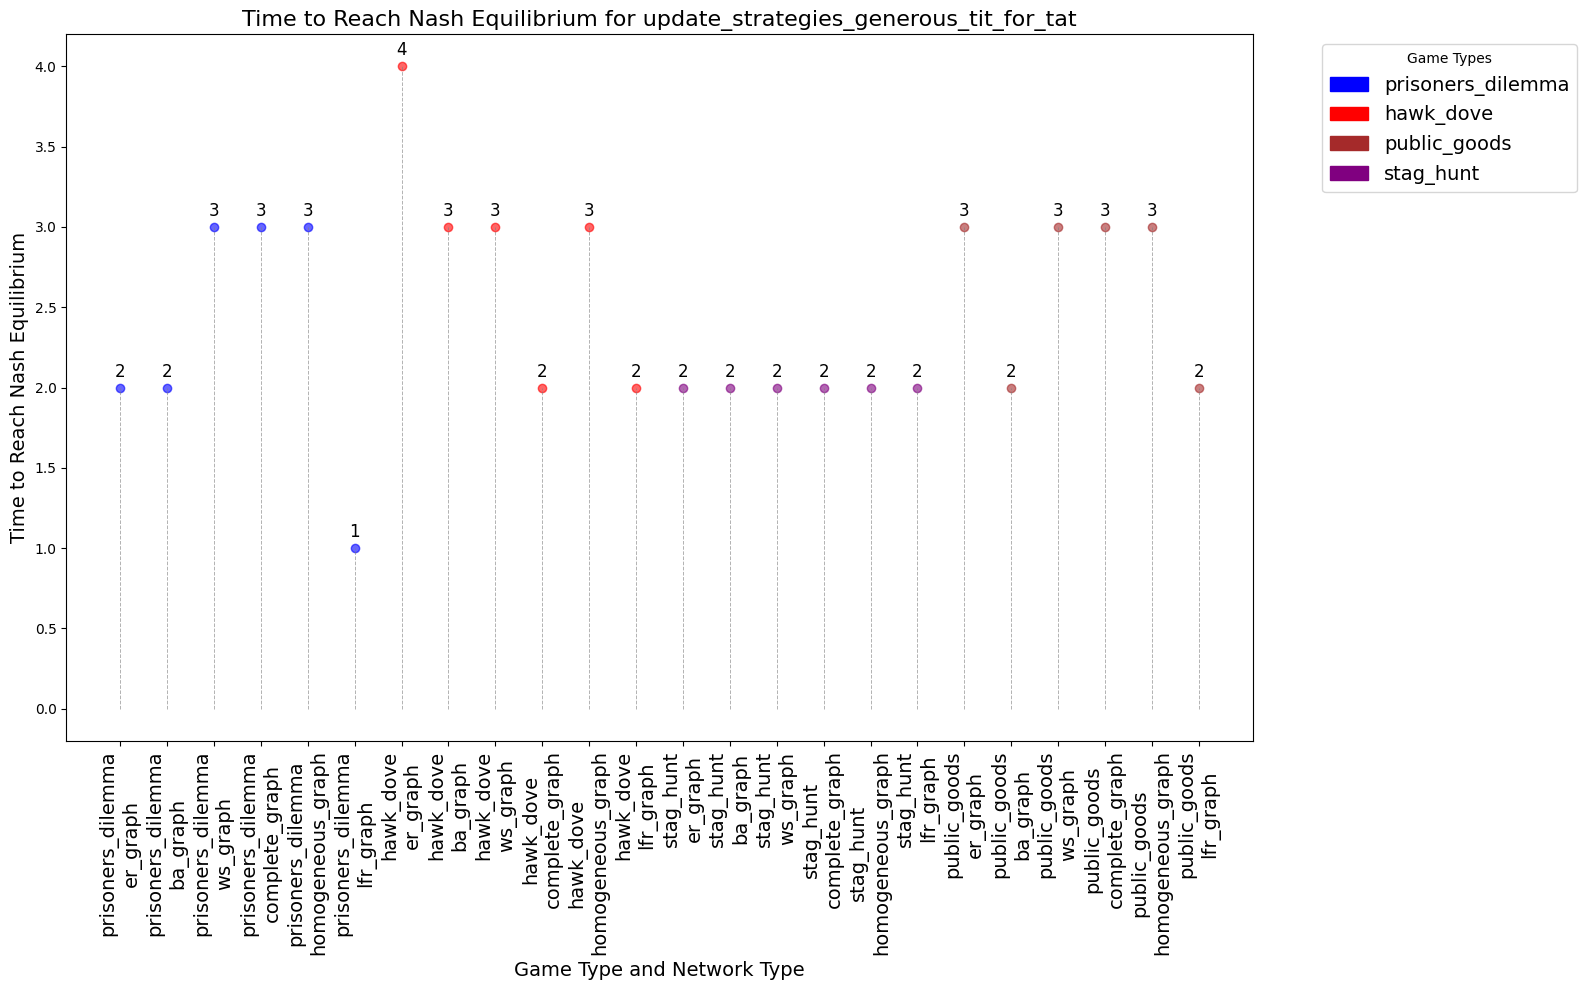

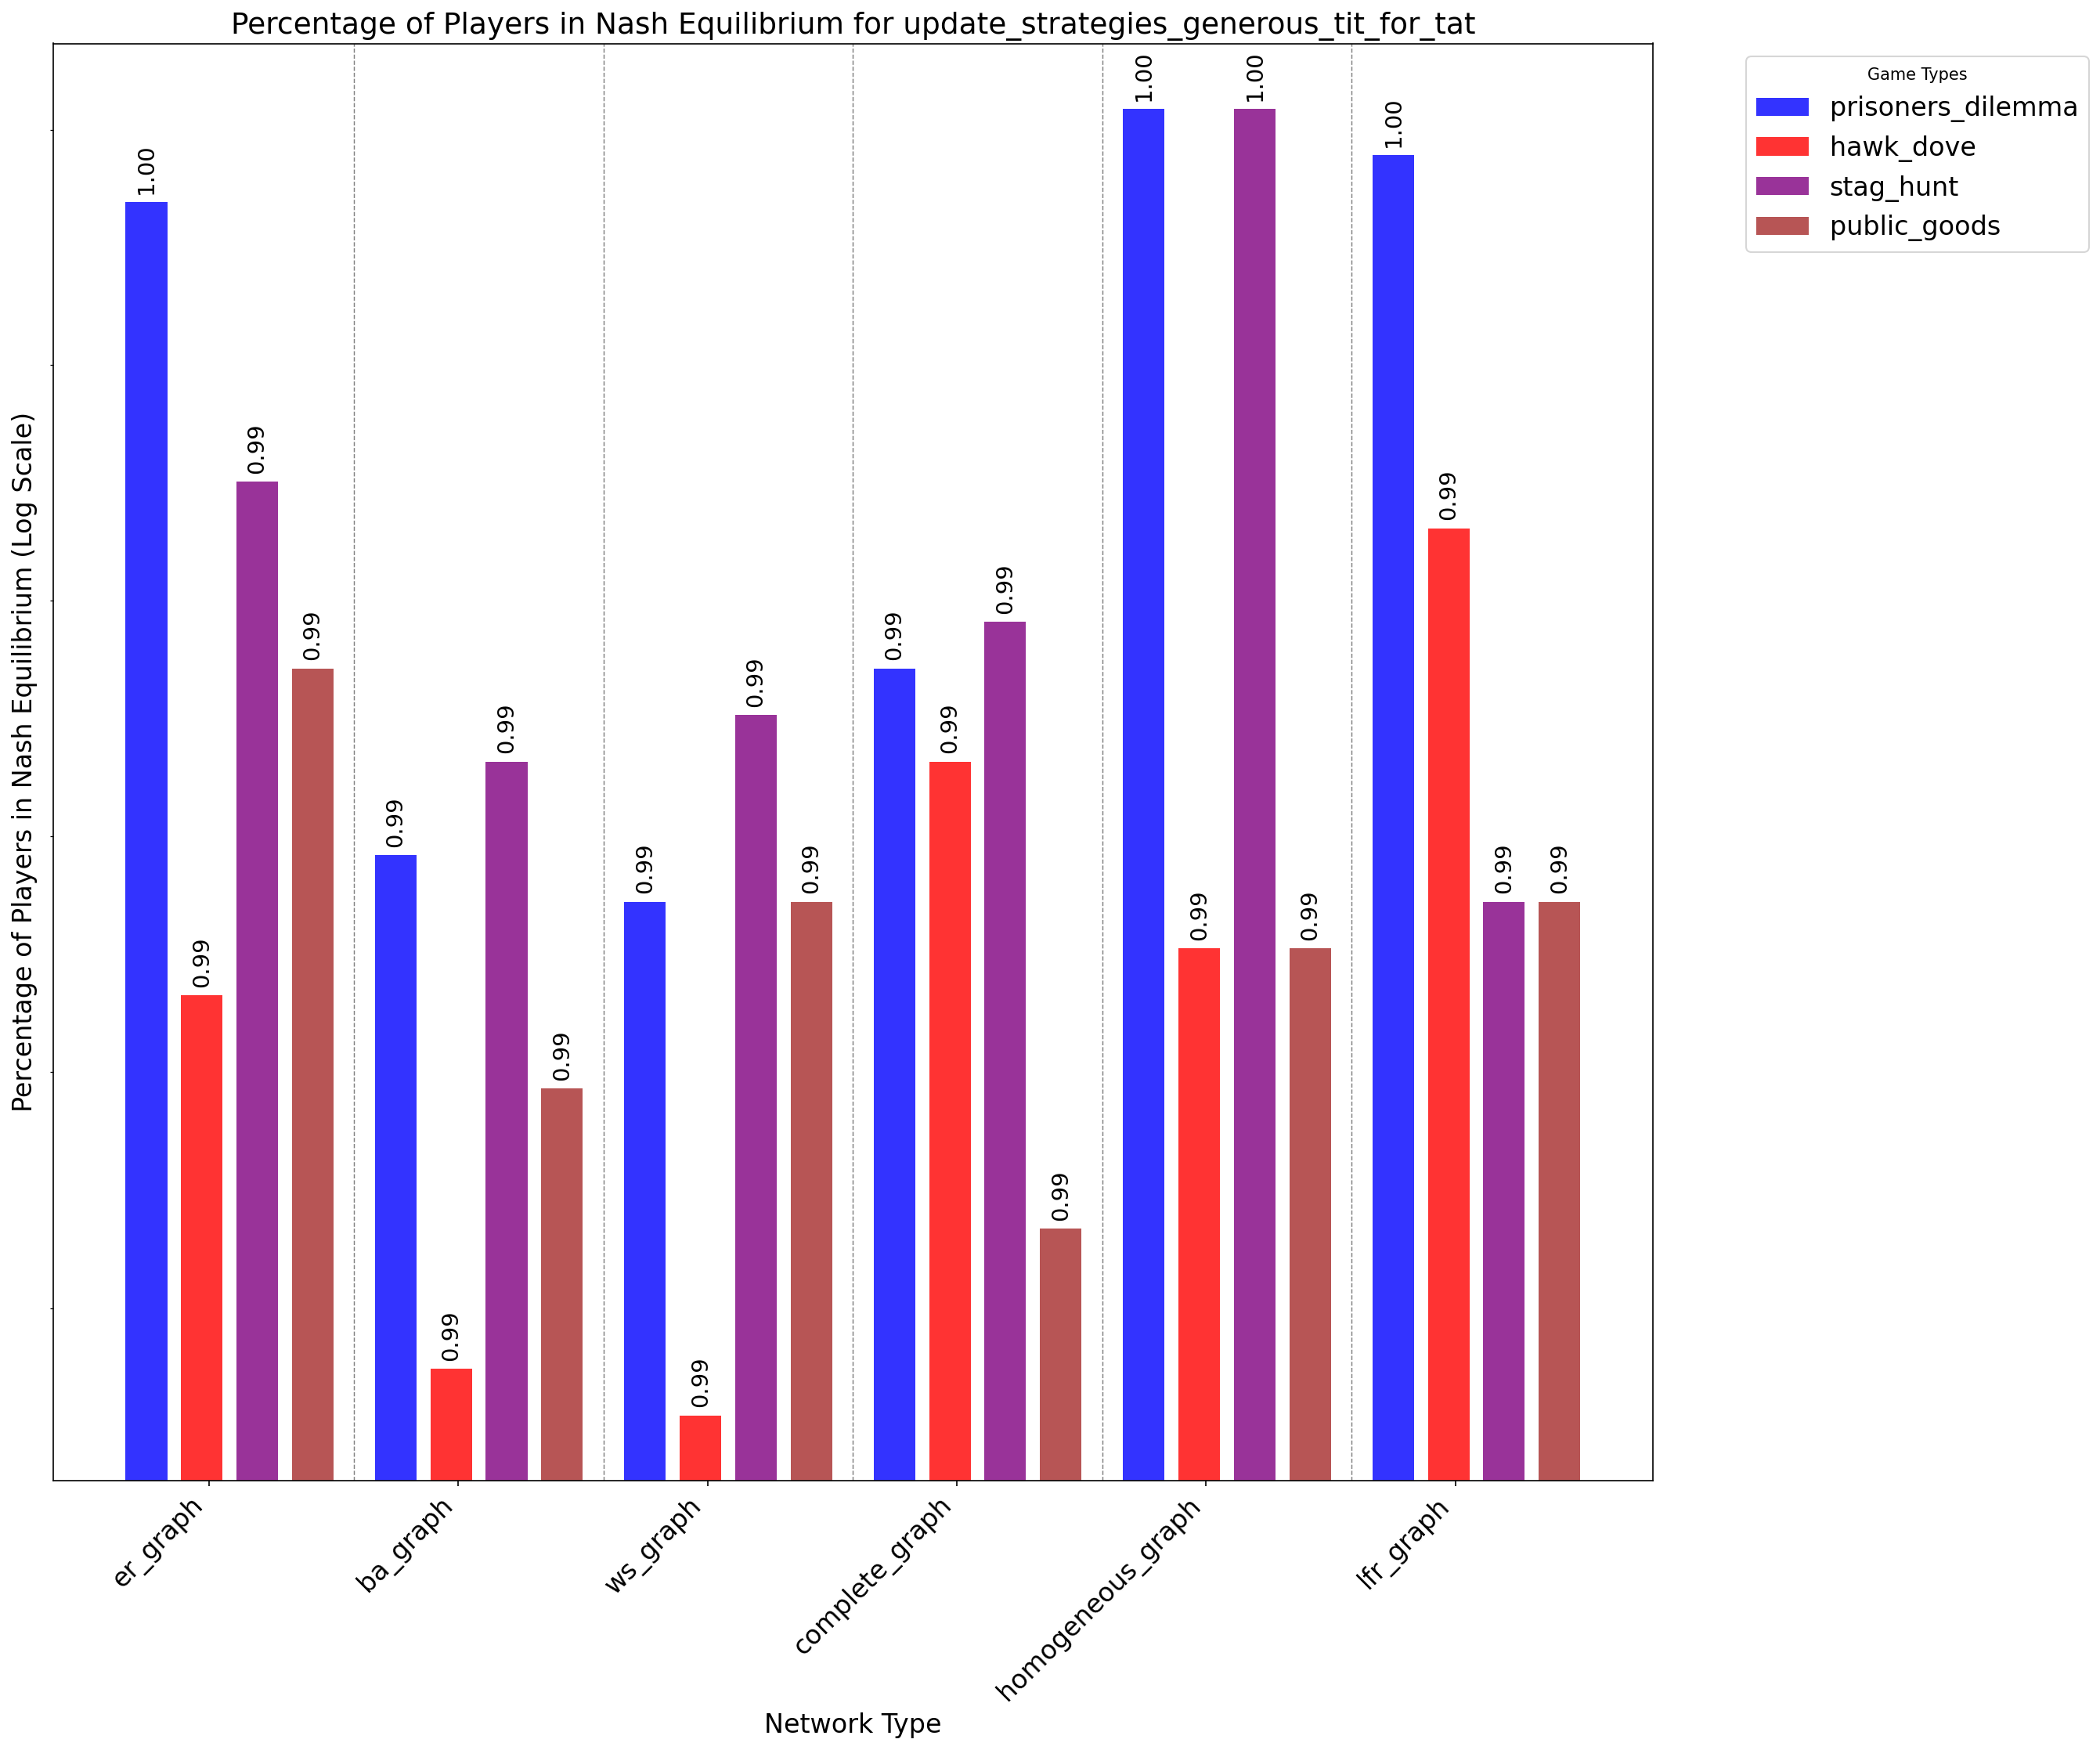

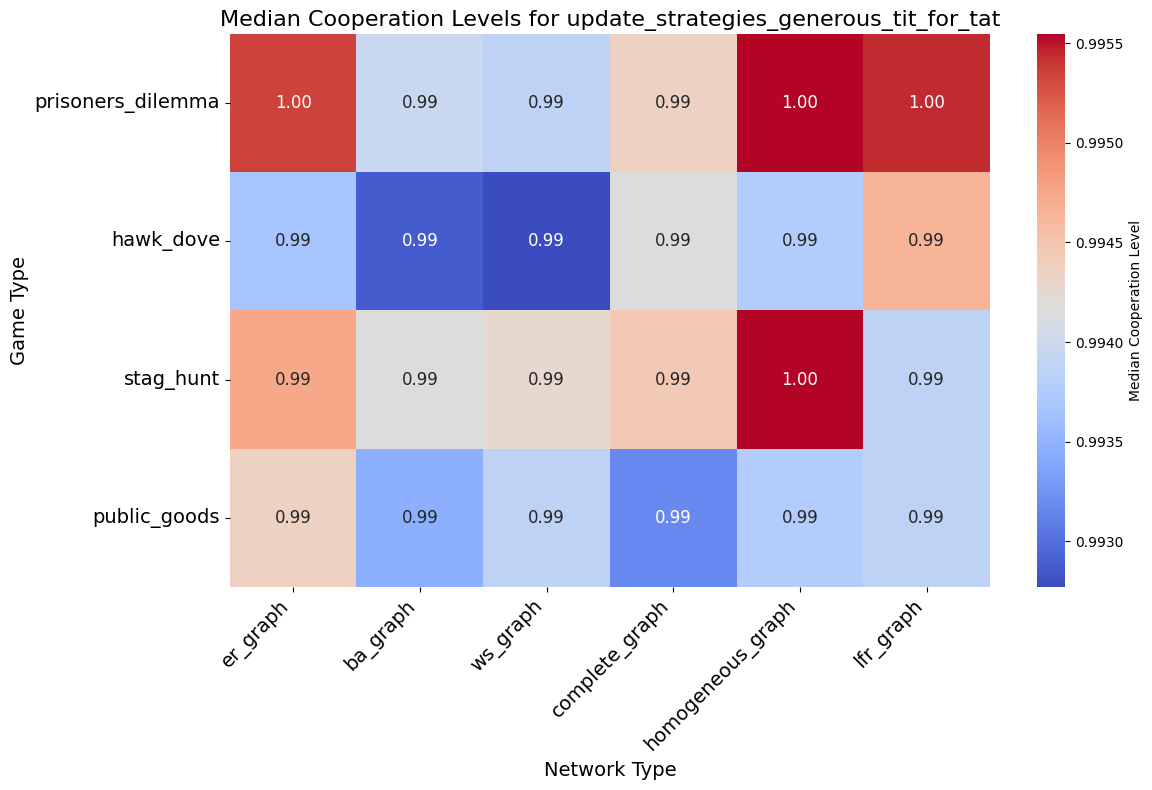

In [ ]:
!pip install matplotlib
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches

# Define the games
games = {
    "prisoners_dilemma": np.array([[-1, -3], [0, -2]]),
    "hawk_dove": np.array([[3, 1], [5, 0]]),
    "stag_hunt": np.array([[10, 0], [7, 7]]),
    "public_goods": lambda x, k, N: (x * k) / N
}

# Define the networks
def create_network(network_type, num_nodes):
    if network_type == "er_graph":
        return nx.erdos_renyi_graph(num_nodes, 0.1)
    elif network_type == "ba_graph":
        return nx.barabasi_albert_graph(num_nodes, 5)
    elif network_type == "ws_graph":
        return nx.watts_strogatz_graph(num_nodes, 6, 0.1)
    elif network_type == "complete_graph":
        return nx.complete_graph(num_nodes)
    elif network_type == "homogeneous_graph":
        return nx.random_regular_graph(3, num_nodes)
    elif network_type == "lfr_graph":

        num_nodes = 50

        min_community = 10
        max_community = 25
        mu = 0.1
        min_degree = 2
        max_degree = 10
        return nx.LFR_benchmark_graph(num_nodes, tau1=3, tau2=1.5, mu=mu,
                                      min_degree=min_degree, max_degree=max_degree,
                                      min_community=min_community, max_community=max_community,
                                      max_iters=100000)
    else:
        raise ValueError("Unknown network type")

def update_strategies_static(agents):
    return [agent.strategy for agent in agents]

def update_strategies_replicator(agents):
    total_fitness = sum(agent.payoff for agent in agents)
    if total_fitness == 0:
        for agent in agents:
            agent.strategy = np.random.randint(2)
    else:
        probabilities = [agent.payoff / total_fitness for agent in agents]
        new_strategies = np.random.choice([agent.strategy for agent in agents], size=len(agents), p=probabilities)
        for agent, new_strategy in zip(agents, new_strategies):
            agent.strategy = new_strategy
    return [agent.strategy for agent in agents]

def update_strategies_unconditional_imitation(agents):
    best_neighbor = max(agents, key=lambda agent: agent.payoff)
    for agent in agents:
        agent.strategy = best_neighbor.strategy
    return [agent.strategy for agent in agents]

def update_strategies_moran(agents):
    total_fitness = sum(agent.payoff for agent in agents)
    probabilities = [agent.payoff / total_fitness for agent in agents]
    reproducer = np.random.choice(agents, p=probabilities)
    replacer = np.random.choice(agents)
    replacer.strategy = reproducer.strategy
    return [agent.strategy for agent in agents]

def update_strategies_fermi_paradox(agents):
    for agent in agents:
        opponent = np.random.choice(agents)
        if np.all(agent.payoff < opponent.payoff):
            agent.strategy = opponent.strategy
    return [agent.strategy for agent in agents]

def update_strategies_stochastic_best_response(agents):
    for agent in agents:
        best_response = max(agents, key=lambda a: a.payoff).strategy
        if np.random.rand() < 0.5:
            agent.strategy = best_response
    return [agent.strategy for agent in agents]

def update_strategies_generous_tit_for_tat(agents):
    for agent in agents:
        opponent = np.random.choice(agents)
        if opponent.strategy == 1:
            agent.strategy = 1
        else:
            if np.random.rand() < 0.75:
                agent.strategy = 1
            else:
                agent.strategy = 0
    return [agent.strategy for agent in agents]

class Agent:
    def __init__(self, id, strategy):
        self.id = id
        self.strategy = strategy
        self.payoff = 0

    def play(self, opponent, game, **kwargs):
        if callable(game):
            if game == games['public_goods']:
                self.payoff += game(self.strategy, k=kwargs.get('k'), N=kwargs.get('N'))
            else:
                self.payoff += game(self.strategy, opponent.strategy, **kwargs)
        else:
            self.payoff += game[self.strategy, opponent.strategy]

def simulate_game(game, network, update_rule, num_steps=100, k=1, N=10, game_type=None):
    agents = [Agent(i, np.random.randint(2)) for i in range(network.number_of_nodes())]
    history = [[agent.strategy for agent in agents]]

    for step in range(num_steps):
        for agent in agents:
            agent.payoff = 0
            neighbors = list(network.neighbors(agent.id))
            for neighbor_id in neighbors:
                neighbor = agents[neighbor_id]
                if game_type == "public_goods":
                    agent.play(neighbor, game, k=k, N=N)
                else:
                    agent.play(neighbor, game)

        update_rule(agents)
        history.append([agent.strategy for agent in agents])

    return np.array(history)

def calculate_nash_equilibrium(game, strategies, incomplete_info=False, **kwargs):
    nash_equilibria = []
    if incomplete_info or callable(game):
        for i in range(len(strategies)):
            for j in range(len(strategies)):
                if game == games['public_goods']:
                    if game(strategies[i], k=kwargs['k'], N=kwargs['N']) == strategies[i]:
                        nash_equilibria.append((strategies[i], strategies[j]))
                else:
                    if game(strategies[i], strategies[j]):
                        nash_equilibria.append((strategies[i], strategies[j]))
    else:
        for i in range(len(strategies)):
            for j in range(len(strategies)):
                if game[strategies[i], strategies[j]] >= game[strategies[j], strategies[i]]:
                    nash_equilibria.append((strategies[i], strategies[j]))
    return nash_equilibria


output_dir = '/content/drive/My Drive/Colab Notebooks/Charts/'


def save_and_show_plot(fig, output_dir, filename):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    fig.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.show()

color_mapping = {
    "prisoners_dilemma": "blue",
    "hawk_dove": "red",
    "stag_hunt": "purple",
    "public_goods": "brown"
}

def plot_nash_equilibria_counts(results, update_rule_type, annot_size=14, label_size=16, title_size=18):
    fig, ax = plt.subplots(figsize=(18, 15), dpi=150)
    network_types = list(results[next(iter(results))].keys())
    game_types = list(results.keys())

    bar_width = 0.15
    gap = 2.0
    index = np.arange(len(network_types)) * (len(game_types) + gap) * bar_width

    for i, game_type in enumerate(game_types):
        counts = [results[game_type][network]['nash_equilibria_counts'] for network in network_types]
        bars = ax.bar(index + i * (bar_width + 0.05), counts, bar_width, label=game_type, color=color_mapping[game_type], alpha=0.8)

        annotation_heights = {}
        for bar in bars:
            height = bar.get_height()
            x_pos = bar.get_x() + bar.get_width() / 2
            y_offset = 5
            if height >= 10000:
                exponent = int(np.log10(height))
                if exponent == 4 and height == 10000:
                    annotation_text = r"$10^4$"
                else:
                    base = round(height / (10 ** exponent), 1)
                    annotation_text = rf"${base} \times 10^{{{exponent}}}$" if base != 1 else rf"$10^{{{exponent}}}$"
            else:
                annotation_text = f"{int(height)}"
            attempts = 0
            while x_pos in annotation_heights and height + y_offset <= annotation_heights[x_pos] and attempts < 5:
                y_offset += 5
                if y_offset > 30:
                    y_offset = -30
                attempts += 1
            annotation_heights[x_pos] = height + y_offset
            ax.annotate(annotation_text,
                        xy=(x_pos, height),
                        xytext=(0, y_offset),
                        textcoords="offset points",
                        ha='center',
                        va='bottom',
                        fontsize=annot_size,
                        rotation=90)

    # Add vertical lines at gaps between groups
    for i in range(1, len(network_types)):
        x_gap = (index[i] + index[i - 1] + len(game_types) * bar_width) / 2
        ax.axvline(x=x_gap, color='gray', linestyle='--', linewidth=0.7)

    ax.set_xlabel('Network Type', fontsize=label_size)
    ax.set_ylabel('Nash Equilibria Counts (log scale)', fontsize=label_size)
    ax.set_title(f'Nash Equilibria Counts for {update_rule_type}', fontsize=title_size)
    ax.set_xticks(index + bar_width * (len(game_types) - 1) / 2)
    ax.set_xticklabels(network_types, rotation=45, ha='right', fontsize=label_size)

    ax.set_yscale('log')
    ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

    ax.legend(fontsize=label_size, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(pad=2, h_pad=2, w_pad=2)

    filename = f'{update_rule_type}_nash_equilibria_counts_log_scale.png'
    save_and_show_plot(fig, os.path.join(output_dir, 'plot_nash_equilibria_counts'), filename)


def plot_percentage_of_players_in_nash_equilibrium(results, update_rule_type, annot_size=14, label_size=16, title_size=18):
    fig, ax = plt.subplots(figsize=(18, 15), dpi=150)
    network_types = list(results[next(iter(results))].keys())
    game_types = list(results.keys())

    bar_width = 0.15
    gap = 2.0
    index = np.arange(len(network_types)) * (len(game_types) + gap) * bar_width

    for i, game_type in enumerate(game_types):
        percentages = [results[game_type][network]['percentage_of_players_in_nash_equilibrium'] for network in network_types]
        bars = ax.bar(index + i * (bar_width + 0.05), percentages, bar_width, label=game_type, color=color_mapping[game_type], alpha=0.8)

        for bar in bars:
            height = bar.get_height()
            x_pos = bar.get_x() + bar.get_width() / 2
            ax.annotate(f'{height:.2f}',
                        xy=(x_pos, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=annot_size,
                        rotation=90)


    for i in range(1, len(network_types)):
        x_gap = (index[i] + index[i - 1] + len(game_types) * bar_width) / 2
        ax.axvline(x=x_gap, color='gray', linestyle='--', linewidth=0.7)

    ax.set_yscale('log')
    ax.set_xlabel('Network Type', fontsize=label_size)
    ax.set_ylabel('Percentage of Players in Nash Equilibrium (Log Scale)', fontsize=label_size)
    ax.set_title(f'Percentage of Players in Nash Equilibrium for {update_rule_type}', fontsize=title_size)
    ax.set_xticks(index + bar_width * (len(game_types) - 1) / 2)
    ax.set_xticklabels(network_types, rotation=45, ha='right', fontsize=label_size)

    ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

    plt.legend(title='Game Types', fontsize=label_size, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()

    filename = f'{update_rule_type}_percentage_of_players_in_nash_equilibrium_log_scale.png'
    save_and_show_plot(fig, os.path.join(output_dir, 'plot_percentage_of_players_in_nash_equilibrium'), filename)


def plot_time_to_reach_nash_equilibrium(results, update_rule_type, annot_size=12, label_size=14, title_size=16):
    network_types = list(results[next(iter(results))].keys())
    game_types = list(results.keys())

    fig, ax = plt.subplots(figsize=(16, 10))

    x_labels = []
    x_positions = []

    for game_type in game_types:
        for network_type in network_types:
            times = results[game_type][network_type]['time_to_reach_nash_equilibrium']
            if times:
                x_label = f'{game_type}\n{network_type}'
                x_labels.append(x_label)
                current_position = len(x_positions) + 1
                x_positions.extend([current_position] * len(times))
                for time in times:
                    ax.plot([current_position, current_position], [0, time], color='gray', alpha=0.6, linestyle='--', linewidth=0.7)

                ax.scatter([current_position] * len(times), times, color=color_mapping[game_type], alpha=0.6)


                for time in times:
                    ax.annotate(f'{int(time)}',
                                xy=(current_position, time),
                                xytext=(0, 5),
                                textcoords='offset points',
                                ha='center',
                                va='bottom',
                                fontsize=annot_size)

    ax.set_xticks(range(1, len(x_labels) + 1))
    ax.set_xticklabels(x_labels, rotation=90, ha='center', fontsize=label_size)
    ax.set_xlabel('Game Type and Network Type', fontsize=label_size)
    ax.set_ylabel('Time to Reach Nash Equilibrium', fontsize=label_size)
    ax.set_title(f'Time to Reach Nash Equilibrium for {update_rule_type}', fontsize=title_size)

    legend_patches = [
        mpatches.Patch(color='blue', label='prisoners_dilemma'),
        mpatches.Patch(color='red', label='hawk_dove'),
        mpatches.Patch(color='brown', label='public_goods'),
        mpatches.Patch(color='purple', label='stag_hunt')
    ]
    ax.legend(handles=legend_patches, title="Game Types", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=label_size)

    plt.tight_layout()
    filename = f'{update_rule_type}_time_to_reach_nash_equilibrium_lines.png'
    save_and_show_plot(fig, os.path.join(output_dir, 'plot_time_to_reach_nash_equilibrium'), filename)

def plot_cooperation_levels_heatmap(results, update_rule_type, annot_size=12, label_size=14, title_size=16, label_rotation=0):
    network_types = list(results[next(iter(results))].keys())
    game_types = list(results.keys())


    data = np.zeros((len(game_types), len(network_types)))

    for i, game_type in enumerate(game_types):
        for j, network_type in enumerate(network_types):
            cooperation_levels_list = results[game_type][network_type]['cooperation_levels']
            median_cooperation = np.median([np.mean(cooperation_levels) for cooperation_levels in cooperation_levels_list])
            data[i, j] = median_cooperation


    df = pd.DataFrame(data, index=game_types, columns=network_types)


    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, cbar_kws={'label': 'Median Cooperation Level'}, annot_kws={"size": annot_size})
    ax.set_xlabel('Network Type', fontsize=label_size)
    ax.set_ylabel('Game Type', fontsize=label_size)
    ax.set_title(f'Median Cooperation Levels for {update_rule_type}', fontsize=title_size)
    plt.xticks(rotation=45, ha='right', fontsize=label_size)
    plt.yticks(rotation=label_rotation, fontsize=label_size)
    plt.tight_layout()

    filename = f'{update_rule_type}_cooperation_levels_heatmap.png'
    save_and_show_plot(fig, os.path.join(output_dir, 'plot_cooperation_levels'), filename)

def main(Nrep, Tmax, Ttrans, n_nodes):
    network_types = ["er_graph", "ba_graph", "ws_graph", "complete_graph", "homogeneous_graph", "lfr_graph"]
    game_types = ["prisoners_dilemma", "hawk_dove", "stag_hunt", "public_goods"]
    update_rule_types = [
    "update_strategies_static", "update_strategies_replicator",
    "update_strategies_unconditional_imitation", "update_strategies_moran",
    "update_strategies_fermi_paradox", "update_strategies_stochastic_best_response",
    "update_strategies_generous_tit_for_tat"
]


    for update_rule_type in update_rule_types:
        results = {game: {network: {} for network in network_types} for game in game_types}

        for network_type in network_types:
            for game_type in game_types:
                network = create_network(network_type, n_nodes)
                game = games[game_type]
                update_rule = globals()[update_rule_type]
                history = simulate_game(game, network, update_rule, num_steps=Tmax, k=1, N=n_nodes, game_type=game_type)

                results[game_type][network_type]['nash_equilibria_counts'] = len(calculate_nash_equilibrium(game, history[-1], incomplete_info=(game_type == "public_goods"), k=1, N=n_nodes))

                if 'cooperation_levels' not in results[game_type][network_type]:
                    results[game_type][network_type]['cooperation_levels'] = []
                results[game_type][network_type]['cooperation_levels'].append(np.mean(history, axis=1))

                time_to_reach = []
                for i, strategies in enumerate(history):
                    if np.all(strategies == history[-1]):
                        time_to_reach.append(i)
                        break
                results[game_type][network_type]['time_to_reach_nash_equilibrium'] = time_to_reach

                results[game_type][network_type]['percentage_of_players_in_nash_equilibrium'] = np.mean([np.mean(step == history[-1]) for step in history])

        plot_nash_equilibria_counts(results, update_rule_type)
        plot_time_to_reach_nash_equilibrium(results, update_rule_type)
        plot_percentage_of_players_in_nash_equilibrium(results, update_rule_type)
        plot_cooperation_levels_heatmap(results, update_rule_type)

if __name__ == "__main__":
    main(Nrep=10, Tmax=100, Ttrans=10, n_nodes=100)